# 3.1 Diseño de un chatbot.

Partiendo de las nociones teóricas y prácticas vistas en la unidad, el alumno va a diseñar y desarrollar un chatbot que sea capaz de responder preguntas específicas al área de interés. Tanto el diseño como el código deben ser entregados describiendo detalladamente cada uno de los procesos involucrados, así como la justificación y pertinencia de su implementación.

## Propósito y alcance de la práctica

Se diseña y construye un **chatbot que responde preguntas sobre aprendizaje profundo y procesamiento de lenguaje natural (PLN)**. El área de interés se eligió a propósito: el chatbot explica los mismos conceptos que se usan para construirlo.

Un chatbot es, ante todo, un sistema de PLN. Por eso, antes de armarlo, la práctica recorre y **compara experimentalmente** cada pieza del PLN con aprendizaje profundo:

- **Análisis de texto:** normalización, tokenización (por palabras y por subpalabras), *stopwords*, *stemming* y lematización, n-gramas y exploración estadística de un corpus.
- **Representación del texto (*embeddings*):** one-hot y TF-IDF, **Word2Vec**, **GloVe** (implementado desde cero), **FastText** y los **embeddings contextuales** (BETO y Sentence-BERT) como alternativa superior.
- **Modelos secuenciales:** **RNN**, **LSTM** y **GRU** implementadas a mano y verificadas contra PyTorch; un experimento sobre el gradiente desvaneciente; bidireccionalidad y atención; y el **Transformer** como alternativa superior.
- **Análisis de sentimientos:** comparación de TF-IDF, RNN, LSTM, GRU, BiLSTM con atención, distintos embeddings y BETO sobre 70,000 reseñas en español.

Con lo aprendido se diseña un **chatbot híbrido** con tres módulos:

1. un **clasificador de intención** (BiGRU sobre vectores FastText);
2. un **buscador semántico** (Sentence-BERT);
3. un **analizador de sentimientos** (BETO), que ajusta el tono de la respuesta cuando el usuario escribe frustrado.

## Índice

1. Entorno de trabajo
2. El PLN con aprendizaje profundo: marco teórico
3. Análisis de texto
4. Representación del texto: de one-hot a embeddings contextuales
5. Modelos secuenciales: RNN, LSTM y GRU
6. Análisis de sentimientos: comparación de arquitecturas y embeddings
7. Diseño del chatbot
8. Implementación del chatbot
9. Evaluación del chatbot
10. Análisis de resultados
11. Justificación de las decisiones
12. Conclusiones y posibles mejoras
13. Referencias

## 1. Entorno de trabajo

| Componente | Versión | Uso en la práctica |
|---|---|---|
| **Python** | 3.13.7 | Lenguaje base |
| **PyTorch** | 2.11.0 (CUDA 12.8) | RNN, LSTM, GRU, GloVe y entrenamiento en GPU |
| **Transformers** (Hugging Face) | 5.18.0 | BETO: tokenizador, embeddings contextuales y *fine-tuning* |
| **Sentence-Transformers** | 6.1.0 | Embeddings de oraciones para la búsqueda semántica |
| **Datasets** (Hugging Face) | 5.0.1 | Descarga del corpus de reseñas |
| **gensim** | 4.4.0 | Word2Vec y FastText |
| **spaCy** (`es_core_news_sm`) | 3.8.16 | Lematización en español |
| **NLTK** | 3.10.3 | *Stopwords* y *stemmer* Snowball en español |
| **scikit-learn** | 1.7.2 | TF-IDF, regresión logística, métricas y divisiones |
| **NumPy / SciPy / pandas** | 2.3.3 / 1.16.3 / 2.3.3 | Cálculo numérico, matriz dispersa de co-ocurrencias y tablas |
| **Matplotlib / seaborn** | 3.10.7 / 0.13.2 | Gráficas |

**Hardware:** GPU NVIDIA GeForce RTX 4050 Laptop (6 GB). Se eligió **PyTorch** en lugar de TensorFlow porque TensorFlow ya no usa la GPU en Windows nativo, mientras que PyTorch sí. Todos los modelos entrenados se guardan en `modelos/` y se recargan si ya existen, así que el notebook puede volver a ejecutarse sin reentrenar.

In [1]:
# Si falta alguna dependencia, descomenta las siguientes líneas y ejecútalas una vez:
# %pip install torch --index-url https://download.pytorch.org/whl/cu128
# %pip install transformers datasets sentence-transformers gensim spacy nltk scikit-learn scipy pandas matplotlib seaborn pyarrow
# !python -m spacy download es_core_news_sm

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # Evita advertencias del tokenizador rápido
import warnings
warnings.filterwarnings("ignore")

import sys, platform, json, re, time, random, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy
from scipy import sparse
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

import gensim
from gensim.models import Word2Vec, FastText, KeyedVectors
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import datasets
from datasets import load_dataset
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import sentence_transformers
from sentence_transformers import SentenceTransformer

transformers.logging.set_verbosity_error()        # Oculta avisos informativos de Hugging Face
datasets.logging.set_verbosity_error()
nltk.download("stopwords", quiet=True)

versiones = {
    "Python": sys.version.split()[0], "PyTorch": torch.__version__, "Transformers": transformers.__version__,
    "Sentence-Transformers": sentence_transformers.__version__, "Datasets": datasets.__version__,
    "gensim": gensim.__version__, "spaCy": spacy.__version__, "NLTK": nltk.__version__,
    "scikit-learn": sklearn.__version__, "NumPy": np.__version__, "pandas": pd.__version__,
}
print(pd.Series(versiones, name="Versión").to_string())
print(f"\nSistema operativo: {platform.system()} {platform.release()}")
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de cómputo: {DISPOSITIVO}" + (f" ({torch.cuda.get_device_name(0)})" if DISPOSITIVO.type == "cuda" else ""))

Python                         3.13.7
PyTorch                  2.11.0+cu128
Transformers                   5.18.0
Sentence-Transformers           6.1.0
Datasets                        5.0.1
gensim                          4.4.0
spaCy                          3.8.16
NLTK                           3.10.3
scikit-learn                    1.7.2
NumPy                           2.3.3
pandas                          2.3.3

Sistema operativo: Windows 10
Dispositivo de cómputo: cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


In [2]:
# Semilla global para que los resultados sean reproducibles
SEMILLA = 42

def fijar_semilla(semilla=SEMILLA):
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    torch.cuda.manual_seed_all(semilla)

fijar_semilla()

# Carpetas de trabajo
RUTA_DATOS = Path("datos")        # Base de conocimiento y frases de prueba del chatbot (versionadas)
RUTA_DATASET = Path("dataset")    # Corpus de reseñas descargado (ignorado por git)
RUTA_MODELOS = Path("modelos")    # Modelos entrenados (ignorados por git)
RUTA_DATASET.mkdir(exist_ok=True)
RUTA_MODELOS.mkdir(exist_ok=True)

# Modelos preentrenados de Hugging Face
NOMBRE_BETO = "dccuchile/bert-base-spanish-wwm-cased"                         # BERT entrenado en español
NOMBRE_SBERT = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"  # Embeddings de oraciones

# Paleta categórica fija: cada modelo conserva siempre el mismo color en todas las gráficas
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.prop_cycle": matplotlib.cycler(color=PALETA),
})

## 2. El PLN con aprendizaje profundo: marco teórico

### 2.1 Qué es el PLN y por qué es difícil

El **procesamiento de lenguaje natural** es el área de la IA que permite a una computadora analizar, entender y generar lenguaje humano. Sus tareas típicas son la clasificación de texto, el análisis de sentimientos, el reconocimiento de entidades, la traducción, el resumen, la respuesta a preguntas y los chatbots.

El lenguaje es difícil para una máquina porque:

- **Es ambiguo:** "banco" puede ser un asiento o una institución financiera; "vi al hombre con el telescopio" admite dos lecturas.
- **Depende del contexto y del orden:** "no es bueno" y "es bueno, no" tienen las mismas palabras y significados distintos.
- **Es composicional y tiene dependencias largas:** en "la batería, que al principio parecía durar bastante, terminó fallando", el sentimiento lo decide el final de la frase.
- **Es variable:** sinónimos, faltas de ortografía, regionalismos, ironía ("genial, se rompió al segundo día").
- **Es discreto:** las redes neuronales operan con números continuos, así que primero hay que convertir palabras en vectores.

### 2.2 Evolución de los enfoques

| Etapa | Representación del texto | Modelo | Limitación principal |
|---|---|---|---|
| Reglas (1960 a 1990) | Patrones y diccionarios escritos a mano | Sistemas expertos, ELIZA | No escala ni generaliza |
| Estadístico (1990 a 2012) | Bolsa de palabras, TF-IDF, n-gramas | Naive Bayes, SVM, regresión logística | Vectores dispersos, sin semántica ni orden |
| Embeddings + redes recurrentes (2013 a 2017) | Word2Vec, GloVe, FastText | RNN, LSTM, GRU, seq2seq con atención | Procesamiento secuencial y lento, un vector por palabra |
| Transformers (2017 en adelante) | Embeddings contextuales por subpalabras | BERT, GPT y modelos de lenguaje grandes | Alto costo de cómputo y de datos |

### 2.3 El pipeline de PLN con aprendizaje profundo

Casi todo sistema de PLN neuronal sigue esta cadena, que se desarrolla en las secciones 3 a 6:

```
Paso                  Ejemplo
texto crudo           "¡No me gustó!"
  -> normalización    "¡no me gustó!"
  -> tokenización     [¡, no, me, gustó, !]
  -> índices          [57, 14, 9, 812, 33]   (posición en el vocabulario)
  -> embeddings       5 vectores de 100 dimensiones
  -> modelo           RNN / LSTM / GRU / Transformer
  -> salida           negativo (p = 0.93)
```

Los índices y la probabilidad del ejemplo son ilustrativos.

La ventaja del aprendizaje profundo es que **las representaciones se aprenden**: en lugar de diseñar a mano qué características indican un sentimiento negativo, la red aprende vectores de palabras y cómo combinarlos para resolver la tarea.

## 3. Análisis de texto

### 3.1 Corpus de trabajo: reseñas de Amazon en español

Para estudiar el PLN con datos reales se usa el corpus **Multilingual Amazon Reviews** (Keung et al., 2020), en su partición en español:

- Enlace: <https://huggingface.co/datasets/SetFit/amazon_reviews_multi_es>
- **210,000 reseñas** de productos, con calificación de 1 a 5 estrellas y exactamente la misma cantidad de reseñas por estrella.
- Ya viene dividido en entrenamiento (200,000), validación (5,000) y prueba (5,000).

Se usa en dos momentos:

1. Las 200,000 reseñas de entrenamiento sirven como **corpus para entrenar los embeddings** (Word2Vec, GloVe y FastText).
2. Un subconjunto sirve para **análisis de sentimientos**. Las estrellas se agrupan en tres clases:

| Estrellas | Clase |
|---|---|
| 1 y 2 | negativo |
| 3 | neutral |
| 4 y 5 | positivo |

Se eligió este corpus porque es grande, está en español y trae etiquetas confiables (las puso el propio autor de la reseña), así que permite comparar modelos con rigor. Después, el modelo de sentimiento entrenado aquí se reutiliza en el chatbot para detectar el tono del usuario.

In [3]:
RUTA_PARQUET = RUTA_DATASET / "amazon_reviews_es.parquet"

if RUTA_PARQUET.exists():
    df_total = pd.read_parquet(RUTA_PARQUET)
    print("Corpus cargado desde la copia local.")
else:
    print("Descargando el corpus desde Hugging Face...")
    ds = load_dataset("SetFit/amazon_reviews_multi_es")
    partes = []
    for particion in ["train", "validation", "test"]:
        parte = ds[particion].to_pandas()[["text", "label"]]
        parte["particion"] = particion
        partes.append(parte)
    df_total = pd.concat(partes, ignore_index=True)
    df_total.to_parquet(RUTA_PARQUET)

CLASES = ["negativo", "neutral", "positivo"]
df_total["estrellas"] = df_total["label"] + 1
df_total["sentimiento"] = df_total["estrellas"].map({1: 0, 2: 0, 3: 1, 4: 2, 5: 2})

print(f"Total de reseñas: {len(df_total):,}")
print(pd.crosstab(df_total["estrellas"], df_total["particion"])[["train", "validation", "test"]].to_string())

Corpus cargado desde la copia local.
Total de reseñas: 210,000
particion  train  validation  test
estrellas                         
1          40000        1000  1000
2          40000        1000  1000
3          40000        1000  1000
4          40000        1000  1000
5          40000        1000  1000


In [4]:
# Algunas reseñas de ejemplo, una por estrella
import textwrap
ejemplos = df_total[df_total["particion"] == "train"].groupby("estrellas").sample(1, random_state=SEMILLA)
for estrellas, texto in zip(ejemplos["estrellas"], ejemplos["text"]):
    print(textwrap.fill(texto, width=84, initial_indent=f"{estrellas} estrella(s): ", subsequent_indent=" " * 15) + "\n")

1 estrella(s): Pedí la botella por comodidad al salir a pasear con Sherlock... Pero
               ha sido una decepción. Cuando llegó tenia el plástico que ancla la
               botella con el bebedero roto. Me he puesto en contacto con el
               vendedor y estoy a la espera de noticias...

2 estrella(s): el diseño es bastante feo. Nada que ver con la foto. La calidad
               normal.

3 estrella(s): Son un poco débiles, pero sirven para guardar cosas importantes, los
               cajones tienen su maña, pero por el precio y su cometido esta bien.

4 estrella(s): Lanza los mosquitos por el aire de su potencia. No deja que se
               acerque ni uno lejos de el.

5 estrella(s): No estaba en casa y me lo han dejado donde les dije asique perfecto.
               No estaba dañado ni nada



**Subconjunto para análisis de sentimientos.** Entrenar varias redes con 200,000 reseñas tomaría demasiado tiempo en una GPU de portátil. Por eso se toma una **muestra balanceada de 60,000 reseñas de entrenamiento**, 20,000 por clase: 10,000 de 1 estrella, 10,000 de 2, 20,000 de 3, 10,000 de 4 y 10,000 de 5.

Para validación y prueba se usan las particiones oficiales completas (5,000 cada una). Ahí la proporción es 2:1:2, así que la métrica principal será el **F1 macro**, que da el mismo peso a las tres clases.

In [5]:
N_POR_ESTRELLA = {1: 10_000, 2: 10_000, 3: 20_000, 4: 10_000, 5: 10_000}
df_ent_total = df_total[df_total["particion"] == "train"]
df_ent = pd.concat([df_ent_total[df_ent_total["estrellas"] == e].sample(n, random_state=SEMILLA)
                    for e, n in N_POR_ESTRELLA.items()]).sample(frac=1, random_state=SEMILLA).reset_index(drop=True)
df_val = df_total[df_total["particion"] == "validation"].reset_index(drop=True)
df_pru = df_total[df_total["particion"] == "test"].reset_index(drop=True)

resumen = pd.DataFrame({nombre: df["sentimiento"].map(dict(enumerate(CLASES))).value_counts().reindex(CLASES)
                        for nombre, df in [("Entrenamiento", df_ent), ("Validación", df_val), ("Prueba", df_pru)]})
print(resumen.to_string())

             Entrenamiento  Validación  Prueba
sentimiento                                   
negativo             20000        2000    2000
neutral              20000        1000    1000
positivo             20000        2000    2000


### 3.2 Preprocesamiento paso a paso

El preprocesamiento convierte texto crudo en una secuencia limpia de unidades (tokens). A continuación se aplica cada paso a una reseña de ejemplo para ver qué hace y qué riesgos tiene.

In [6]:
PATRON_URL = re.compile(r"https?://\S+|www\.\S+")
PATRON_TOKEN = re.compile(r"[a-záéíóúüñ0-9]+|[!?¡¿]")   # Palabras (con acentos y ñ) y signos de exclamación e interrogación

def normalizar(texto):
    # Minúsculas y eliminación de URLs. Se conservan los acentos porque en español distinguen palabras (esta/está)
    return PATRON_URL.sub(" ", texto.lower())

def tokenizar(texto):
    # Divide en palabras y conserva ! y ?, que aportan información de tono
    return PATRON_TOKEN.findall(normalizar(texto))

texto_ej = "¡NO me gustó para nada! La batería dura muy poco y el envío tardó 15 días... No lo recomiendo: https://amzn.to/xyz"
print("1. Texto original :", texto_ej)
print("2. Normalizado    :", normalizar(texto_ej))
tokens_ej = tokenizar(texto_ej)
print("3. Tokens         :", tokens_ej)

STOPWORDS_ES = set(stopwords.words("spanish"))
print("4. Sin stopwords  :", [t for t in tokens_ej if t not in STOPWORDS_ES])
print(f"\nNLTK trae {len(STOPWORDS_ES)} stopwords en español. ¿Incluye 'no'? {'no' in STOPWORDS_ES}. ¿'muy'? {'muy' in STOPWORDS_ES}. ¿'nada'? {'nada' in STOPWORDS_ES}")

1. Texto original : ¡NO me gustó para nada! La batería dura muy poco y el envío tardó 15 días... No lo recomiendo: https://amzn.to/xyz
2. Normalizado    : ¡no me gustó para nada! la batería dura muy poco y el envío tardó 15 días... no lo recomiendo:  
3. Tokens         : ['¡', 'no', 'me', 'gustó', 'para', 'nada', '!', 'la', 'batería', 'dura', 'muy', 'poco', 'y', 'el', 'envío', 'tardó', '15', 'días', 'no', 'lo', 'recomiendo']
4. Sin stopwords  : ['¡', 'gustó', '!', 'batería', 'dura', 'envío', 'tardó', '15', 'días', 'recomiendo']

NLTK trae 313 stopwords en español. ¿Incluye 'no'? True. ¿'muy'? True. ¿'nada'? True


El paso 4 muestra un **riesgo importante para el análisis de sentimientos**. La lista estándar de stopwords de NLTK incluye "no", "muy" y "nada". Al quitarlas, "**no** me gustó para **nada**" se convierte en "gustó", que parece positivo.

Por eso en esta práctica **no se eliminan stopwords** para los modelos neuronales: las redes aprenden por sí mismas qué palabras ignorar, y las negaciones e intensificadores son justamente lo que cambia la polaridad. Las stopwords solo se quitan para *mostrar* los términos más frecuentes en la exploración del corpus.

**Stemming vs lematización.** Ambos reducen las variantes de una palabra a una forma común:

- El **stemming** (Snowball) recorta sufijos con reglas, sin saber si el resultado es una palabra real.
- La **lematización** (spaCy) usa un vocabulario y el análisis gramatical para llegar a la forma de diccionario.

In [7]:
nlp_es = spacy.load("es_core_news_sm")
stemmer = SnowballStemmer("spanish")

frase = "Las baterías funcionaban mejor y me devolvieron el dinero rápidamente, lo recomendaría a mis amigos"
doc = nlp_es(frase)
tabla = pd.DataFrame([(t.text, stemmer.stem(t.text.lower()), t.lemma_.lower(), t.pos_) for t in doc if t.is_alpha],
                     columns=["Palabra", "Stemming (Snowball)", "Lema (spaCy)", "Categoría gramatical"])
tabla

,Palabra,Stemming (Snowball),Lema (spaCy),Categoría gramatical
0,Las,las,el,DET
1,baterías,bat,batería,NOUN
2,funcionaban,funcion,funcionar,VERB
3,mejor,mejor,mejor,ADJ
4,y,y,y,CCONJ
5,me,me,yo,PRON
6,devolvieron,devolv,devolver,VERB
7,el,el,el,DET
8,dinero,diner,dinero,NOUN
9,rápidamente,rapid,rápidamente,ADV


El *stemmer* produce raíces que no son palabras ("funcion", "devolv", "recomend") y además puede juntar palabras distintas. La lematización devuelve formas reales ("funcionar", "devolver", "batería"), pero es más lenta porque necesita un modelo de análisis gramatical.

Ninguna de las dos se usa en los modelos neuronales de esta práctica:

- **FastText**, con sus n-gramas de caracteres, y los tokenizadores de **subpalabras** de BERT ya capturan la morfología de forma aprendida.
- Lematizar destruye información útil: el tiempo verbal y la persona ("funcionaba" frente a "funciona" pueden indicar una queja).

### 3.3 Exploración estadística del corpus

In [8]:
class CorpusTokenizado:
    # Iterable que tokeniza cada texto al recorrerlo. Así no se guardan millones de tokens en memoria
    # y se puede recorrer varias veces (una por época de Word2Vec y FastText)
    def __init__(self, textos, repeticiones=1):
        self.textos, self.repeticiones = list(textos), repeticiones
    def __iter__(self):
        for _ in range(self.repeticiones):
            for texto in self.textos:
                yield tokenizar(texto)

# Las 200,000 reseñas de entrenamiento: servirán para la exploración y para entrenar los embeddings
inicio = time.time()
corpus_resenas = CorpusTokenizado(df_ent_total["text"])
frecuencias, num_tokens = Counter(), 0
for doc in corpus_resenas:
    frecuencias.update(doc)
    num_tokens += len(doc)
print(f"Reseñas: {len(corpus_resenas.textos):,} | tokens: {num_tokens:,} | palabras distintas: {len(frecuencias):,} | {time.time() - inicio:.1f} s")

df_ent["tokens"] = [tokenizar(t) for t in df_ent["text"]]
df_val["tokens"] = [tokenizar(t) for t in df_val["text"]]
df_pru["tokens"] = [tokenizar(t) for t in df_pru["text"]]
df_ent["longitud"] = df_ent["tokens"].map(len)
print("\nLongitud de las reseñas (tokens) en el subconjunto de entrenamiento:")
print(df_ent.groupby(df_ent["sentimiento"].map(dict(enumerate(CLASES))))["longitud"].describe()[["mean", "50%", "75%", "max"]].round(1).to_string())
print(f"\nPercentil 95 de longitud: {np.percentile(df_ent['longitud'], 95):.0f} tokens")

Reseñas: 200,000 | tokens: 5,589,582 | palabras distintas: 55,694 | 2.3 s



Longitud de las reseñas (tokens) en el subconjunto de entrenamiento:
             mean   50%   75%    max
sentimiento                         
negativo     30.2  24.0  37.0  329.0
neutral      28.9  23.0  36.0  460.0
positivo     25.4  20.0  31.0  365.0

Percentil 95 de longitud: 73 tokens


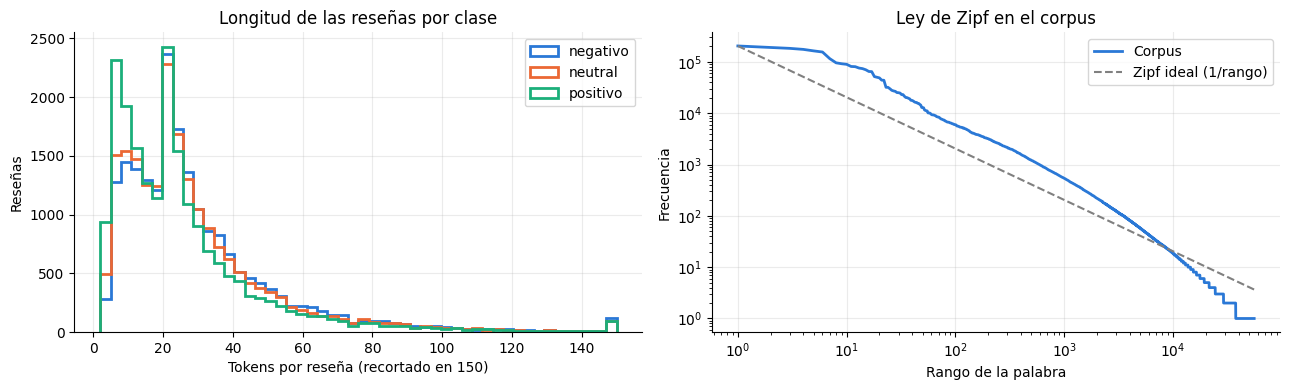

Palabras que aparecen una sola vez (hapax): 18,072 (32% del vocabulario)
Las 20,000 palabras más frecuentes cubren el 98.8% de todos los tokens


In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de longitudes por clase
for c, nombre in enumerate(CLASES):
    ejes[0].hist(df_ent.loc[df_ent["sentimiento"] == c, "longitud"].clip(upper=150), bins=50,
                 histtype="step", linewidth=2, label=nombre, color=PALETA[c])
ejes[0].set_xlabel("Tokens por reseña (recortado en 150)")
ejes[0].set_ylabel("Reseñas")
ejes[0].set_title("Longitud de las reseñas por clase")
ejes[0].legend()

# Ley de Zipf: la frecuencia de una palabra es inversamente proporcional a su posición en el ranking
conteos = np.array(sorted(frecuencias.values(), reverse=True))
rangos = np.arange(1, len(conteos) + 1)
ejes[1].loglog(rangos, conteos, color=PALETA[0], linewidth=2, label="Corpus")
ejes[1].loglog(rangos, conteos[0] / rangos, color="gray", linestyle="--", linewidth=1.5, label="Zipf ideal (1/rango)")
ejes[1].set_xlabel("Rango de la palabra")
ejes[1].set_ylabel("Frecuencia")
ejes[1].set_title("Ley de Zipf en el corpus")
ejes[1].legend()
plt.tight_layout()
plt.show()

solo_una_vez = sum(1 for c in frecuencias.values() if c == 1)
print(f"Palabras que aparecen una sola vez (hapax): {solo_una_vez:,} ({solo_una_vez / len(frecuencias):.0%} del vocabulario)")
cobertura = conteos[:20_000].sum() / conteos.sum()
print(f"Las 20,000 palabras más frecuentes cubren el {cobertura:.1%} de todos los tokens")

Se observan dos propiedades típicas del lenguaje que justifican decisiones posteriores:

- **Las reseñas son cortas, pero con una cola larga.** La mitad tiene menos de unos 25 tokens y tres cuartas partes menos de 40, aunque hay algunas de más de 300. Las reseñas **negativas (30.2 tokens en promedio) y neutrales (28.9) son más largas que las positivas (25.4)**: quien está satisfecho escribe "excelente, lo recomiendo", y quien tiene una queja explica el problema. El **percentil 95 es de 73 tokens**, así que truncar a **150 tokens** (el doble) deja intactas prácticamente todas las reseñas y solo recorta las excepcionalmente largas.
- **El vocabulario sigue aproximadamente la ley de Zipf.** En la parte media del ranking la curva es casi paralela a la recta ideal de pendiente −1, y se desvía en los extremos, como ocurre en los corpus reales:
  - Al inicio, las palabras funcionales más frecuentes tienen frecuencias parecidas entre sí, así que la curva es casi plana.
  - En la cola, la curva cae más rápido.

  Las consecuencias prácticas son dos. **18,072 palabras (el 32 % del vocabulario) aparecen una sola vez** (*hapax*): errores de ortografía, nombres de productos y formas raras. En cambio, **las 20,000 palabras más frecuentes cubren el 98.8 % de los tokens**. Un vocabulario de unas 20,000 palabras basta para representar casi todo el texto; el resto son palabras **fuera de vocabulario (OOV)**, un problema que FastText y los tokenizadores de subpalabras resuelven.

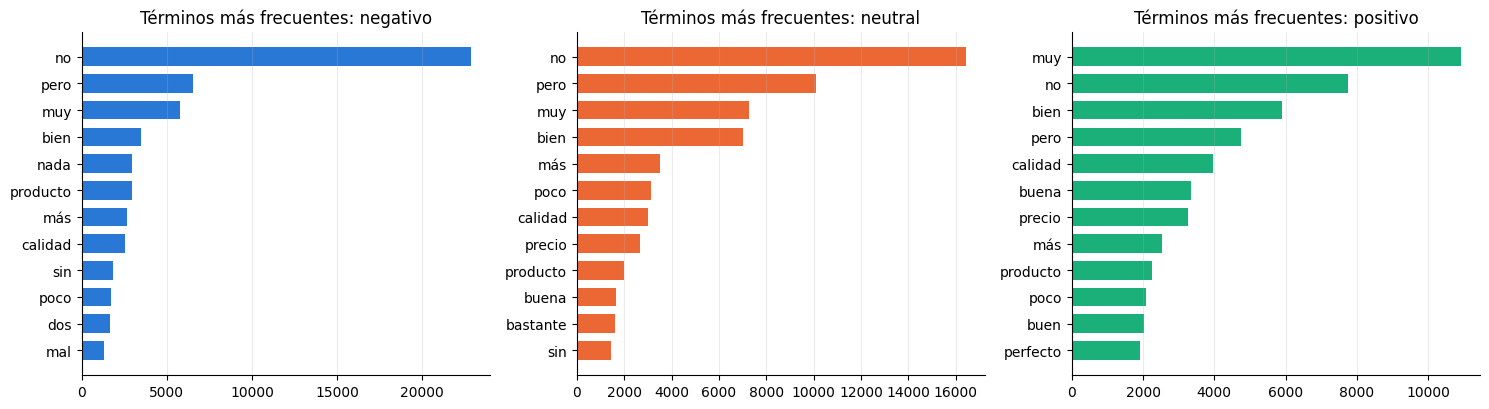

           negativo          neutral               positivo
      no me (2,458)  un poco (2,173)       muy bien (2,430)
       y no (2,164)    no es (1,858)         es muy (1,575)
      no se (2,055)    no se (1,794)        un poco (1,502)
     que no (1,894)   que no (1,730)  buena calidad (1,273)
      no es (1,872)   es muy (1,698) calidad precio (1,214)
      no lo (1,792) muy bien (1,411)         que no (1,137)
el producto (1,457)     y no (1,387)          no se (1,103)
     es muy (1,156)    no me (1,360)        muy buena (974)


In [10]:
# Términos y bigramas más frecuentes por clase. Solo para esta visualización se quitan stopwords,
# pero se conservan las negaciones y los intensificadores
CONSERVAR = {"no", "muy", "nada", "sin", "pero", "más", "poco", "bien", "mal"}
STOP_VIS = STOPWORDS_ES - CONSERVAR

def mas_frecuentes(tokens_por_doc, n=12):
    return Counter(t for doc in tokens_por_doc for t in doc if t not in STOP_VIS and t.isalpha() and (len(t) > 2 or t in CONSERVAR)).most_common(n)

def bigramas_frecuentes(tokens_por_doc, n=8):
    conteo = Counter()
    for doc in tokens_por_doc:
        for a, b in zip(doc, doc[1:]):
            if a.isalpha() and b.isalpha() and not (a in STOP_VIS and b in STOP_VIS):
                conteo[f"{a} {b}"] += 1
    return conteo.most_common(n)

fig, ejes = plt.subplots(1, 3, figsize=(15, 4.2))
for c, nombre in enumerate(CLASES):
    palabras, cuentas = zip(*mas_frecuentes(df_ent.loc[df_ent["sentimiento"] == c, "tokens"]))
    ejes[c].barh(palabras[::-1], cuentas[::-1], color=PALETA[c], height=0.7)
    ejes[c].set_title(f"Términos más frecuentes: {nombre}")
    ejes[c].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(pd.DataFrame({nombre: [f"{b} ({n:,})" for b, n in bigramas_frecuentes(df_ent.loc[df_ent["sentimiento"] == c, "tokens"])]
                    for c, nombre in enumerate(CLASES)}).to_string(index=False))

Los términos frecuentes muestran cómo se expresa cada clase y, sobre todo, cuánto vocabulario comparten:

- **"no" es la palabra más frecuente en las reseñas negativas** (unas 23,000 apariciones) y **en las neutrales** (unas 16,000). Pero también aparece unas 7,700 veces en las positivas, porque la negación también sirve para descartar problemas. Sola, no indica la polaridad.
- **Negativo:** además de "no", destacan "nada", "sin" y "mal". Los bigramas más frecuentes están dominados por la negación: "no me", "y no", "no se", "que no", "no es", "no lo".
- **Neutral:** "**pero**" aparece unas 10,000 veces, más que en cualquier otra clase. Es la conjunción del matiz ("está bien, pero..."), y la acompañan "bastante" y "poco". Su bigrama más frecuente es "un poco".
- **Positivo:** "muy", "bien", "calidad", "buena", "precio" y "perfecto"; bigramas "muy bien", "buena calidad", "calidad precio" y "muy buena".

La conclusión importante: **las palabras sueltas se reparten entre las tres clases**. "Muy", "bien", "pero", "calidad" y "no" aparecen en todas. Lo que distingue la polaridad es la **combinación y el orden**: "no funciona" frente a "funciona bien", o "bien, pero..." frente a "muy bien". Esta es la motivación para usar modelos que procesen **secuencias** y no bolsas de palabras. También anticipa que la clase neutral será la más difícil, porque mezcla el vocabulario de las otras dos.

### 3.4 Tokenización por subpalabras

La tokenización por palabras tiene dos problemas: un **vocabulario enorme** y las **palabras fuera de vocabulario**. Cualquier palabra que no se vio en el entrenamiento (un error de ortografía, un término nuevo) se convierte en un token genérico `<unk>` y su información se pierde.

Los modelos modernos usan **subpalabras** (WordPiece en BERT, BPE en GPT). Las palabras frecuentes quedan completas y las raras se dividen en fragmentos frecuentes; el prefijo `##` indica que el fragmento continúa la palabra anterior. BETO usa un vocabulario WordPiece de 31,002 unidades.

In [11]:
tok_beto = AutoTokenizer.from_pretrained(NOMBRE_BETO)
print(f"Tamaño del vocabulario de BETO: {tok_beto.vocab_size:,} subpalabras\n")

for oracion in ["El producto es excelente",
                "Recomendadísimo, llegó rapidísimo",
                "Exelente producto, lo recomiendo muchisimo",
                "La retropropagación ajusta los hiperparámetros del perceptrón"]:
    print(f"{oracion}\n  -> {tok_beto.tokenize(oracion)}\n")

Tamaño del vocabulario de BETO: 31,002 subpalabras

El producto es excelente
  -> ['El', 'producto', 'es', 'excelente']

Recomendadísimo, llegó rapidísimo
  -> ['Recomend', '##ad', '##ísimo', ',', 'llegó', 'rap', '##id', '##ísimo']

Exelente producto, lo recomiendo muchisimo
  -> ['Ex', '##ele', '##n', '##te', 'producto', ',', 'lo', 'recomiendo', 'much', '##is', '##imo']

La retropropagación ajusta los hiperparámetros del perceptrón
  -> ['La', 'retro', '##pro', '##pa', '##gación', 'ajusta', 'los', 'hiper', '##par', '##ám', '##et', '##ros', 'del', 'percep', '##trón']



In [12]:
# Cuántos tokens de prueba quedan fuera de un vocabulario por palabras construido con el entrenamiento
conteo_ent = Counter(t for doc in df_ent["tokens"] for t in doc)
vocab_palabras = {w for w, c in conteo_ent.items() if c >= 2}
tokens_pru = [t for doc in df_pru["tokens"] for t in doc]
oov = sum(t not in vocab_palabras for t in tokens_pru)
print(f"Vocabulario por palabras (frecuencia >= 2): {len(vocab_palabras):,} palabras")
print(f"Tokens de prueba fuera de vocabulario: {oov:,} de {len(tokens_pru):,} ({oov / len(tokens_pru):.2%})")
print(f"Reseñas de prueba con al menos una palabra OOV: {np.mean([any(t not in vocab_palabras for t in d) for d in df_pru['tokens']]):.1%}")

ids_beto_pru = tok_beto(list(df_pru["text"]), add_special_tokens=False)["input_ids"]
unk_beto = sum(ids.count(tok_beto.unk_token_id) for ids in ids_beto_pru)
print(f"Tokens [UNK] con WordPiece de BETO en las mismas reseñas: {unk_beto}")

Vocabulario por palabras (frecuencia >= 2): 21,318 palabras


Tokens de prueba fuera de vocabulario: 2,138 de 140,076 (1.53%)
Reseñas de prueba con al menos una palabra OOV: 28.6%


Tokens [UNK] con WordPiece de BETO en las mismas reseñas: 104


Los resultados muestran la ventaja de las subpalabras:

- **Palabras raras:** BETO divide "Recomendadísimo" en "Recomend", "##ad" y "##ísimo", conservando la raíz y el sufijo superlativo, en lugar de desconocer la palabra.
- **Errores de ortografía:** "Exelente" se descompone en fragmentos que el modelo sí sabe representar.
- **Vocabulario técnico:** "retropropagación" o "hiperparámetros" se representan aunque nunca se hayan visto completos.

Con el vocabulario por palabras (21,318 palabras con frecuencia de al menos 2), el **1.53 % de los tokens de prueba queda fuera de vocabulario**. Parece poco, pero afecta al **28.6 % de las reseñas**, que contienen al menos una palabra desconocida. Con WordPiece, en las mismas 5,000 reseñas solo aparecen **104 tokens `[UNK]`** (caracteres poco comunes, como algunos símbolos). Esta es una de las razones por las que los modelos basados en subpalabras dominan el PLN actual.

## 4. Representación del texto: de one-hot a embeddings contextuales

Una red neuronal solo procesa números, así que cada palabra debe convertirse en un vector. La calidad de esa representación limita todo lo que el modelo puede aprender después.

### 4.1 Línea base: one-hot, bolsa de palabras y TF-IDF

- **One-hot:** cada palabra es un vector del tamaño del vocabulario, con un 1 en su posición y 0 en el resto.
- **Bolsa de palabras:** suma los vectores one-hot de un documento, es decir, cuenta cuántas veces aparece cada palabra.
- **TF-IDF:** pondera cada conteo por la rareza de la palabra en el corpus:

$$\text{tfidf}(t, d) = \text{tf}(t, d) \cdot \log \frac{N}{\text{df}(t)}$$

donde $\text{tf}(t, d)$ es la frecuencia del término $t$ en el documento $d$, $N$ es el número de documentos y $\text{df}(t)$ el número de documentos que contienen $t$.

In [13]:
frases = ["el producto es excelente", "el artículo es buenísimo", "el producto es pésimo"]
bolsa = CountVectorizer(token_pattern=r"\w+")
matriz = bolsa.fit_transform(frases)
print("Bolsa de palabras (cada fila es una frase, cada columna una palabra del vocabulario):")
print(pd.DataFrame(matriz.toarray(), columns=bolsa.get_feature_names_out(), index=frases).to_string())

sim = cosine_similarity(matriz)
print(f"\nSimilitud coseno 'excelente' vs 'buenísimo': {sim[0, 1]:.2f}")
print(f"Similitud coseno 'excelente' vs 'pésimo'   : {sim[0, 2]:.2f}")

tfidf_demo = TfidfVectorizer(token_pattern=r"[a-záéíóúüñ0-9]+", min_df=2).fit(df_ent["text"])
X_demo = tfidf_demo.transform(df_ent["text"])
print(f"\nTF-IDF sobre las 60,000 reseñas: matriz de {X_demo.shape[0]:,} x {X_demo.shape[1]:,}, "
      f"con {X_demo.nnz / np.prod(X_demo.shape):.3%} de valores distintos de cero")

Bolsa de palabras (cada fila es una frase, cada columna una palabra del vocabulario):
                          artículo  buenísimo  el  es  excelente  producto  pésimo
el producto es excelente         0          0   1   1          1         1       0
el artículo es buenísimo         1          1   1   1          0         0       0
el producto es pésimo            0          0   1   1          0         1       1

Similitud coseno 'excelente' vs 'buenísimo': 0.50
Similitud coseno 'excelente' vs 'pésimo'   : 0.75



TF-IDF sobre las 60,000 reseñas: matriz de 60,000 x 21,043, con 0.110% de valores distintos de cero


Este ejemplo muestra las dos limitaciones de fondo de las representaciones dispersas:

1. **No capturan significado.** "El producto es excelente" se parece *más* a "el producto es pésimo" que a "el artículo es buenísimo", porque comparte más palabras. Para la bolsa de palabras, "excelente" y "buenísimo" son tan distintas como "excelente" y "pésimo": los vectores one-hot son ortogonales entre sí.
2. **Son enormes y casi vacías.** La matriz TF-IDF de las 60,000 reseñas tiene 21,043 columnas y solo el 0.11 % de sus valores es distinto de cero. Además, ignoran el orden de las palabras.

Aun así, TF-IDF con regresión logística es una **línea base fuerte** para clasificar texto, y se usará como referencia en la sección 6.

### 4.2 Word2Vec

Los **embeddings** son vectores **densos** de pocas dimensiones (aquí, 100) en los que palabras con significado similar quedan cerca. Se basan en la **hipótesis distribucional** (Harris, 1954; Firth, 1957): *"una palabra se conoce por las palabras que la acompañan"*. Si "excelente" y "buenísimo" aparecen en contextos parecidos ("el producto es ___", "calidad ___"), sus vectores terminarán siendo parecidos.

**Word2Vec** (Mikolov et al., 2013) aprende estos vectores con una red de una sola capa oculta que resuelve una tarea de predicción:

- **CBOW** (*Continuous Bag of Words*): predice la palabra central a partir del promedio de sus vecinas. Es más rápido y funciona bien con palabras frecuentes.
- **Skip-gram:** predice cada palabra vecina a partir de la central. Es más lento, pero representa mejor las palabras raras.

Calcular un softmax sobre todo el vocabulario sería muy costoso, así que se usa **negative sampling**. Para cada par real (palabra, contexto) se toman $k$ palabras aleatorias como "negativas" y se maximiza:

$$\log \sigma(\mathbf{v}_c^\top \mathbf{v}_w) + \sum_{i=1}^{k} \log \sigma(-\mathbf{v}_{n_i}^\top \mathbf{v}_w)$$

Aquí $\mathbf{v}_w$ es el vector de la palabra central, $\mathbf{v}_c$ el de una palabra real de su contexto y $\mathbf{v}_{n_i}$ el de cada palabra negativa. Es decir, el modelo aprende a distinguir contextos reales de contextos aleatorios.

**Corpus de entrenamiento.** Se usan las 200,000 reseñas de entrenamiento (unos 5.6 millones de tokens). Además se agregan los textos de la base de conocimiento del chatbot, para que el vocabulario técnico (LSTM, retropropagación, embedding) también tenga vector. Configuración común a los tres modelos estáticos:

| Parámetro | Valor |
|---|---|
| Dimensión | 100 |
| Ventana | 5 palabras a cada lado |
| Frecuencia mínima | 5 |
| Épocas | 10 |

In [14]:
# Textos del dominio del chatbot (patrones y respuestas de la base de conocimiento)
with open(RUTA_DATOS / "base_conocimiento.json", encoding="utf-8") as f:
    BASE = json.load(f)
textos_dominio = [p for it in BASE["intenciones"] for p in it["patrones"]] + [it["respuesta"] for it in BASE["intenciones"]]

# El texto del dominio es muy pequeño frente a las reseñas: se repite 10 veces para que sus términos superen la frecuencia mínima
corpus_embeddings = CorpusTokenizado(list(df_ent_total["text"]) + textos_dominio * 10)
print(f"Corpus para embeddings: {len(corpus_embeddings.textos):,} documentos, "
      f"{num_tokens + 10 * sum(len(tokenizar(t)) for t in textos_dominio):,} tokens")

DIM_EMB, VENTANA, MIN_FREC, EPOCAS_EMB = 100, 5, 5, 10
HILOS = os.cpu_count()

# Cada modelo se carga desde disco si ya existe; si no, se entrena y se guarda
tiempos_emb = {}
for nombre, sg in [("word2vec_skipgram", 1), ("word2vec_cbow", 0)]:
    ruta = RUTA_MODELOS / f"{nombre}.model"
    if ruta.exists():
        modelo = Word2Vec.load(str(ruta))
        print(f"{nombre}: cargado desde {ruta}")
    else:
        inicio = time.time()
        modelo = Word2Vec(corpus_embeddings, vector_size=DIM_EMB, window=VENTANA, min_count=MIN_FREC, sg=sg,
                          negative=5, epochs=EPOCAS_EMB, workers=HILOS, seed=SEMILLA)
        tiempos_emb[nombre] = time.time() - inicio
        modelo.save(str(ruta))
        print(f"{nombre}: entrenado en {tiempos_emb[nombre]:.0f} s")
    if sg:
        w2v = modelo.wv
    else:
        w2v_cbow = modelo.wv
print(f"Vocabulario de Word2Vec: {len(w2v):,} palabras")

Corpus para embeddings: 204,190 documentos, 5,643,862 tokens
word2vec_skipgram: cargado desde modelos\word2vec_skipgram.model


word2vec_cbow: cargado desde modelos\word2vec_cbow.model
Vocabulario de Word2Vec: 21,831 palabras


In [15]:
def tabla_vecinos(modelos, palabras, n=4):
    # Para cada palabra, sus n vecinos más cercanos por similitud coseno en cada modelo
    for palabra in palabras:
        for nombre, kv in modelos.items():
            if palabra in kv.key_to_index or isinstance(kv, gensim.models.fasttext.FastTextKeyedVectors):
                vecinos = ", ".join(f"{w} ({s:.2f})" for w, s in kv.most_similar(palabra, topn=n))
            else:
                vecinos = "(fuera de vocabulario)"
            print(f"{palabra:<10} {nombre:<10} {vecinos}")

PALABRAS_PRUEBA = ["excelente", "pésimo", "batería", "tarde", "talla", "devolver", "lstm"]
tabla_vecinos({"Skip-gram": w2v, "CBOW": w2v_cbow}, PALABRAS_PRUEBA)

excelente  Skip-gram  inmejorable (0.81), excepcional (0.78), estupendo (0.77), insuperable (0.76)
excelente  CBOW       excepcional (0.78), inmejorable (0.78), estupenda (0.72), magnífica (0.71)
pésimo     Skip-gram  nefasto (0.80), malísimo (0.74), penoso (0.72), pesimo (0.71)
pésimo     CBOW       pesimo (0.85), nefasto (0.85), penoso (0.75), lamentable (0.70)
batería    Skip-gram  bateria (0.84), carga (0.78), autonomía (0.76), pila (0.72)
batería    CBOW       bateria (0.85), pila (0.72), carga (0.70), autonomía (0.57)
tarde      Skip-gram  estipulada (0.69), tardaría (0.68), adelanto (0.68), demoró (0.67)
tarde      CBOW       retraso (0.60), martes (0.59), tardó (0.57), sábado (0.57)
talla      Skip-gram  38 (0.82), tallaje (0.80), xxl (0.80), xl (0.79)
talla      CBOW       xl (0.73), medida (0.72), xxl (0.68), tallaje (0.64)
devolver   Skip-gram  descambiar (0.82), devolverlo (0.82), devolverla (0.76), cambiarlo (0.71)
devolver   CBOW       descambiar (0.81), devolverlo (0.80)

In [16]:
def analogia(kv, a, b, c, n=3):
    # a es a b como c es a ... : vector(b) - vector(a) + vector(c)
    try:
        return ", ".join(w for w, _ in kv.most_similar(positive=[b, c], negative=[a], topn=n))
    except KeyError as e:
        return f"(fuera de vocabulario: {e})"

ANALOGIAS = [("bueno", "malo", "rápido"), ("bueno", "mejor", "malo"), ("hombre", "mujer", "niño"),
             ("camiseta", "talla", "zapatos"), ("pantalla", "móvil", "teclado"), ("llegó", "llegaron", "funcionó")]
print(pd.DataFrame([(f"{a} : {b} :: {c} : ?", analogia(w2v, a, b, c)) for a, b, c in ANALOGIAS],
                   columns=["Analogía", "Word2Vec Skip-gram (top 3)"]).to_string(index=False))

                        Analogía          Word2Vec Skip-gram (top 3)
      bueno : malo :: rápido : ?       rapidísimo, rapido, enseguida
       bueno : mejor :: malo : ?               peor, menos, malísima
      hombre : mujer :: niño : ?                    hijo, hija, niña
 camiseta : talla :: zapatos : ?                     39, 41, gemelos
 pantalla : móvil :: teclado : ?            ordenador, ratón, pencil
llegó : llegaron :: funcionó : ? funcionaron, funcionaban, funcionan


**Interpretación de Word2Vec.**

- **Semántica aprendida sin supervisión.** Los vecinos de cada palabra son casi sinónimos dentro del dominio de las reseñas:

  | Palabra | Vecinos más cercanos |
  |---|---|
  | "excelente" | "inmejorable", "excepcional", "estupendo", "insuperable" |
  | "pésimo" | "nefasto", "malísimo", "penoso" |
  | "talla" | "38", "tallaje", "xxl", "xl" |
  | "devolver" | "descambiar", "devolverlo", "devolverla" |

  Nadie etiquetó estas relaciones: surgieron solo de observar qué palabras aparecen juntas. El modelo incluso aprendió que **las faltas de ortografía frecuentes son sinónimos**: "bateria" es el vecino más cercano de "batería" y "pesimo" el de "pésimo", porque aparecen en los mismos contextos. El vocabulario técnico agregado también funciona: entre los vecinos de "lstm" están "gru", "rnn" y "transformer".
- **Relaciones lineales (analogías).** Cuatro de las seis analogías dan un resultado coherente:
  - "bueno → mejor" aplicado a "malo" da "**peor**";
  - "llegó → llegaron" aplicado a "funcionó" da "**funcionaron**" (singular a plural);
  - "camiseta → talla" aplicado a "zapatos" da "**39**, **41**": el modelo aprendió que las tallas de calzado son números;
  - "pantalla → móvil" aplicado a "teclado" da "**ordenador**".

  "hombre → mujer" aplicado a "niño" da "hijo, hija, niña", con la respuesta esperada en tercer lugar. "bueno → malo" aplicado a "rápido" **falla**: da "rapidísimo, rapido, enseguida" en lugar de "lento". La dirección de antonimia no es consistente en este corpus. Las analogías funcionan mejor con corpus enormes y generales; con 5.6 millones de tokens de reseñas solo emergen las relaciones frecuentes en el dominio.
- **Skip-gram frente a CBOW.**
  - Skip-gram da vecinos más **semánticos**: para "tarde", "tardaría", "demoró" y "adelanto".
  - CBOW favorece palabras **intercambiables en la misma posición**: para "tarde", "retraso", "martes" y "sábado", porque los días caben en "llegó el ___".

  Se usará Skip-gram en adelante.

### 4.3 GloVe (implementación desde cero en PyTorch)

**GloVe** (*Global Vectors*, Pennington et al., 2014) parte de la misma intuición, pero en lugar de recorrer ventanas locales construye primero la **matriz global de co-ocurrencias** $X$, donde $X_{ij}$ indica cuántas veces aparece la palabra $j$ en el contexto de la palabra $i$. Luego busca vectores cuyo producto punto aproxime el logaritmo de esas co-ocurrencias, con mínimos cuadrados ponderados:

$$J = \sum_{i,j:\,X_{ij}>0} f(X_{ij}) \left( \mathbf{w}_i^\top \tilde{\mathbf{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2, \qquad f(x) = \min\left(1, (x / x_{max})^{\alpha}\right)$$

En la fórmula:

- $\mathbf{w}_i$ es el vector de la palabra $i$ y $\tilde{\mathbf{w}}_j$ el de la palabra $j$ en su papel de contexto; $b_i$ y $\tilde{b}_j$ son sus sesgos.
- La función de peso $f$ (con $x_{max} = 100$ y $\alpha = 0.75$) evita que los pares muy frecuentes ("de la", "que el") dominen el entrenamiento y descarta los pares que nunca co-ocurren.
- El vector final de cada palabra es $\mathbf{w}_i + \tilde{\mathbf{w}}_i$.

Los vectores preentrenados de GloVe para español pesan varios GB. En lugar de descargarlos, **se implementa GloVe desde cero** y se entrena sobre el mismo corpus y con el mismo vocabulario que Word2Vec. Así la comparación es justa y se entiende cómo funciona el algoritmo.

In [17]:
# Paso 1: matriz de co-ocurrencias con el mismo vocabulario que Word2Vec
palabras_glove = w2v.index_to_key
indice_glove = {w: i for i, w in enumerate(palabras_glove)}
V = len(palabras_glove)

inicio = time.time()
ids, docs = [], []
for d, doc in enumerate(corpus_embeddings):
    ids_doc = [indice_glove[t] for t in doc if t in indice_glove]
    ids.extend(ids_doc)
    docs.extend([d] * len(ids_doc))
ids, docs = np.array(ids, dtype=np.int32), np.array(docs, dtype=np.int32)

X_cooc = sparse.csr_matrix((V, V), dtype=np.float32)
for distancia in range(1, VENTANA + 1):
    mismo_doc = docs[:-distancia] == docs[distancia:]          # No se cuentan pares que crucen de una reseña a otra
    i, j = ids[:-distancia][mismo_doc], ids[distancia:][mismo_doc]
    peso = np.full(len(i), 1.0 / distancia, dtype=np.float32)    # Las palabras más cercanas pesan más (1/distancia)
    X_cooc = X_cooc + sparse.coo_matrix((peso, (i, j)), shape=(V, V)).tocsr() \
                    + sparse.coo_matrix((peso, (j, i)), shape=(V, V)).tocsr()   # Matriz simétrica
X_cooc = X_cooc.tocoo()
print(f"Matriz de co-ocurrencias: {V:,} x {V:,}, construida en {time.time() - inicio:.0f} s")
print(f"Pares distintos con co-ocurrencia: {X_cooc.nnz:,} ({X_cooc.nnz / V**2:.3%} de la matriz)")

Matriz de co-ocurrencias: 21,831 x 21,831, construida en 6 s
Pares distintos con co-ocurrencia: 6,176,127 (1.296% de la matriz)


GloVe cargado desde disco.


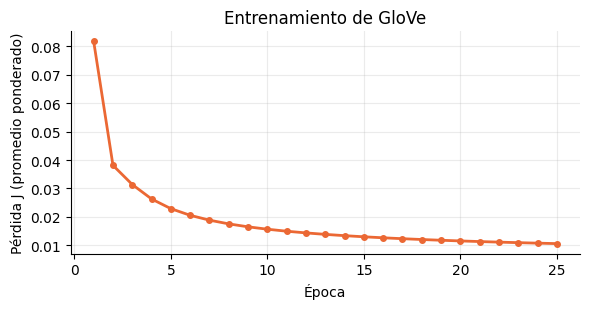

excelente  GloVe      relación (0.85), buena (0.76), inmejorable (0.76), calidad (0.75)
pésimo     GloVe      nefasto (0.82), pesimo (0.74), servicio (0.69), malísimo (0.69)
batería    GloVe      bateria (0.91), dura (0.85), duración (0.78), carga (0.75)
tarde      GloVe      llego (0.76), llegó (0.75), antes (0.72), días (0.72)
talla      GloVe      l (0.89), xl (0.79), m (0.78), s (0.73)
devolver   GloVe      devolverlo (0.86), tuve (0.85), voy (0.84), devolverla (0.82)
lstm       GloVe      gru (0.85), rnn (0.82), fusiona (0.69), hochreiter (0.67)


In [18]:
# Paso 2: el modelo GloVe
class GloVe(nn.Module):
    def __init__(self, tam_vocab, dim):
        super().__init__()
        self.w = nn.Embedding(tam_vocab, dim)        # Vectores de palabra
        self.w_ctx = nn.Embedding(tam_vocab, dim)    # Vectores de contexto
        self.b = nn.Embedding(tam_vocab, 1)          # Sesgo de palabra
        self.b_ctx = nn.Embedding(tam_vocab, 1)      # Sesgo de contexto
        for emb in (self.w, self.w_ctx):
            nn.init.uniform_(emb.weight, -0.5 / dim, 0.5 / dim)
        for emb in (self.b, self.b_ctx):
            nn.init.zeros_(emb.weight)

    def forward(self, i, j):
        # Predicción de log(X_ij): producto punto de los vectores más los dos sesgos
        return (self.w(i) * self.w_ctx(j)).sum(1) + self.b(i).squeeze(1) + self.b_ctx(j).squeeze(1)


X_MAX, ALFA, EPOCAS_GLOVE, LOTE_GLOVE = 100.0, 0.75, 25, 2**16
RUTA_GLOVE = RUTA_MODELOS / "glove.kv"
RUTA_HIST_GLOVE = RUTA_MODELOS / "glove_perdida.json"

if RUTA_GLOVE.exists():
    glove = KeyedVectors.load(str(RUTA_GLOVE))
    perdidas_glove = json.load(open(RUTA_HIST_GLOVE))
    print("GloVe cargado desde disco.")
else:
    fijar_semilla()
    filas = torch.tensor(X_cooc.row, dtype=torch.long, device=DISPOSITIVO)
    columnas = torch.tensor(X_cooc.col, dtype=torch.long, device=DISPOSITIVO)
    valores = torch.tensor(X_cooc.data, dtype=torch.float32, device=DISPOSITIVO)
    log_x = torch.log(valores)
    peso_f = torch.clamp(valores / X_MAX, max=1.0) ** ALFA

    modelo_glove = GloVe(V, DIM_EMB).to(DISPOSITIVO)
    optimizador = torch.optim.Adagrad(modelo_glove.parameters(), lr=0.05)   # Optimizador del artículo original
    perdidas_glove, inicio = [], time.time()
    for epoca in range(EPOCAS_GLOVE):
        orden = torch.randperm(len(valores), device=DISPOSITIVO)
        total = 0.0
        for k in range(0, len(orden), LOTE_GLOVE):
            lote = orden[k:k + LOTE_GLOVE]
            prediccion = modelo_glove(filas[lote], columnas[lote])
            perdida = (peso_f[lote] * (prediccion - log_x[lote]) ** 2).mean()
            optimizador.zero_grad()
            perdida.backward()
            optimizador.step()
            total += perdida.item() * len(lote)
        perdidas_glove.append(total / len(orden))
    print(f"GloVe entrenado en {time.time() - inicio:.0f} s")

    vectores = (modelo_glove.w.weight + modelo_glove.w_ctx.weight).detach().cpu().numpy()
    glove = KeyedVectors(vector_size=DIM_EMB)
    glove.add_vectors(palabras_glove, vectores)
    glove.save(str(RUTA_GLOVE))
    json.dump(perdidas_glove, open(RUTA_HIST_GLOVE, "w"))

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(range(1, len(perdidas_glove) + 1), perdidas_glove, color=PALETA[1], linewidth=2, marker="o", markersize=4)
ax.set_xlabel("Época")
ax.set_ylabel("Pérdida J (promedio ponderado)")
ax.set_title("Entrenamiento de GloVe")
plt.tight_layout()
plt.show()

tabla_vecinos({"GloVe": glove}, PALABRAS_PRUEBA)

La pérdida de GloVe baja de 0.082 a 0.011 en 25 épocas, con la mayor parte de la mejora en las primeras 5.

Los vecinos de GloVe muestran **otro tipo de similitud** que los de Word2Vec:

| Palabra | Vecinos en GloVe | De dónde viene |
|---|---|---|
| "excelente" | "relación", "buena", "calidad" | La frase frecuente "excelente relación calidad-precio" |
| "devolver" | "tuve", "voy" | "Tuve que devolverlo", "voy a devolver" |
| "tarde" | "llegó", "días" | "Llegó tarde", "días de retraso" |

- **Word2Vec** encuentra palabras que pueden **sustituir** a la palabra (relaciones *paradigmáticas*: "excelente" por "inmejorable").
- Este **GloVe** encuentra sobre todo palabras que la **acompañan** (relaciones *sintagmáticas*).

La razón es que GloVe factoriza directamente las co-ocurrencias: con un corpus pequeño (5.6 millones de tokens, frente a los miles de millones del GloVe original), los compañeros más frecuentes dominan el vector. Aun así, también captura relaciones de sustitución cuando son muy marcadas: "lstm" → "gru", "rnn"; "talla" → "l", "xl", "m", "s"; "pésimo" → "nefasto".

Levy y Goldberg (2014) demostraron que Skip-gram con negative sampling factoriza implícitamente una matriz de co-ocurrencias (desplazada), así que ambos métodos están emparentados. En la práctica rinden parecido en tareas posteriores, como se verá en la sección 6.5.

### 4.4 FastText: la alternativa superior entre los embeddings estáticos

Word2Vec y GloVe tratan cada palabra como un símbolo indivisible, lo que causa dos problemas:

1. **Palabras fuera de vocabulario.** No hay vector para palabras nuevas o mal escritas ("exelente", "buenisimo").
2. **Ignoran la morfología.** En español, "recomiendo", "recomendaría" y "recomendable" comparten raíz y significado, pero cada una aprende su vector por separado. Las formas poco frecuentes quedan mal representadas.

**FastText** (Bojanowski et al., 2017) representa cada palabra como la **suma de los vectores de sus n-gramas de caracteres** (aquí, de 3 a 6), más el de la palabra completa. Por ejemplo:

$$\text{"gato"} \rightarrow \langle\text{ga},\ \text{gat},\ \text{ato},\ \text{to}\rangle,\ \langle\text{gat},\ \text{gato},\ \ldots$$

Los símbolos $\langle$ y $\rangle$ marcan el inicio y el fin de la palabra. Como los n-gramas se comparten entre palabras, **cualquier palabra, incluso una nunca vista, obtiene un vector**, y las palabras de la misma familia quedan cerca.

In [19]:
RUTA_FT = RUTA_MODELOS / "fasttext.model"
if RUTA_FT.exists():
    fasttext = FastText.load(str(RUTA_FT)).wv
    print("FastText cargado desde disco.")
else:
    inicio = time.time()
    modelo_ft = FastText(corpus_embeddings, vector_size=DIM_EMB, window=VENTANA, min_count=MIN_FREC, sg=1,
                         min_n=3, max_n=6, bucket=200_000, negative=5, epochs=EPOCAS_EMB, workers=HILOS, seed=SEMILLA)
    modelo_ft.save(str(RUTA_FT))
    fasttext = modelo_ft.wv
    print(f"FastText entrenado en {time.time() - inicio:.0f} s")

# Palabras mal escritas o poco frecuentes. Los errores comunes ("exelente") aparecen 5 veces o más en las reseñas
# y sí tienen vector propio; los errores raros y los superlativos poco usados quedan fuera del vocabulario
PALABRAS_OOV = ["exelente", "baterias", "excelenteee", "baterria", "buenisiiimo", "horrrible",
                "recomendadísimo", "decepcionantísimo"]
print(f"{'Palabra':<18} {'¿Tiene vector en Word2Vec/GloVe?':<33} Vecinos según FastText")
for palabra in PALABRAS_OOV:
    en_vocab = "sí" if palabra in w2v.key_to_index else "no"
    vecinos = ", ".join(f"{w} ({s:.2f})" for w, s in fasttext.most_similar(palabra, topn=2))
    print(f"{palabra:<18} {en_vocab:<33} {vecinos}")

FastText cargado desde disco.
Palabra            ¿Tiene vector en Word2Vec/GloVe?  Vecinos según FastText
exelente           sí                                excelente (0.87), escelente (0.87)
baterias           sí                                baterías (0.81), bateria (0.79)
excelenteee        no                                excelente (0.96), excelentes (0.89)
baterria           no                                bateria (0.89), batería (0.77)
buenisiiimo        no                                buenisimo (0.93), buenisima (0.83)
horrrible          no                                horrible (0.93), terrible (0.84)
recomendadísimo    no                                recomendadisimo (0.91), recomendado (0.87)
decepcionantísimo  no                                decepcionante (0.89), decepcionantes (0.81)


La tabla muestra dos situaciones distintas:

1. **Errores comunes:** "exelente" y "baterias" aparecen 5 veces o más en las reseñas, así que **sí tienen vector propio** también en Word2Vec y GloVe. Es un recordatorio de que el corpus es texto real escrito por usuarios.
2. **Errores raros y formas poco usadas:** "excelenteee", "baterria", "buenisiiimo", "horrrible", "recomendadísimo" y "decepcionantísimo" **no tienen vector en Word2Vec ni en GloVe**. Un modelo que dependa de ellos tendría que ignorarlas.

**FastText resuelve el segundo caso.** Construye su vector a partir de los n-gramas de caracteres y las relaciona con la palabra correcta:

| Palabra | Vecino más cercano en FastText |
|---|---|
| "excelenteee" | "excelente" (0.96) |
| "horrrible" | "horrible" (0.93) |
| "buenisiiimo" | "buenisimo" (0.93) |
| "baterria" | "bateria" (0.89) |
| "decepcionantísimo" | "decepcionante" (0.89) |

En un chatbot esto es decisivo, porque los usuarios escriben rápido, sin acentos y con errores. Por eso el clasificador de intención del chatbot usará **vectores FastText**.

### 4.5 Embeddings contextuales: la alternativa superior de fondo

Word2Vec, GloVe y FastText son **estáticos**: cada palabra tiene **un solo vector**, sin importar la oración en la que aparezca. Esto falla con la **polisemia**.

Los **embeddings contextuales** (ELMo en 2018, con LSTM bidireccionales; BERT en 2018, con Transformers) calculan el vector de cada palabra **en función de toda la oración**. Se usa **BETO** (Cañete et al., 2020), un BERT entrenado con unos 3,000 millones de palabras en español. Se toma el promedio de sus últimas 4 capas para la palabra "banco" en oraciones con dos significados distintos.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

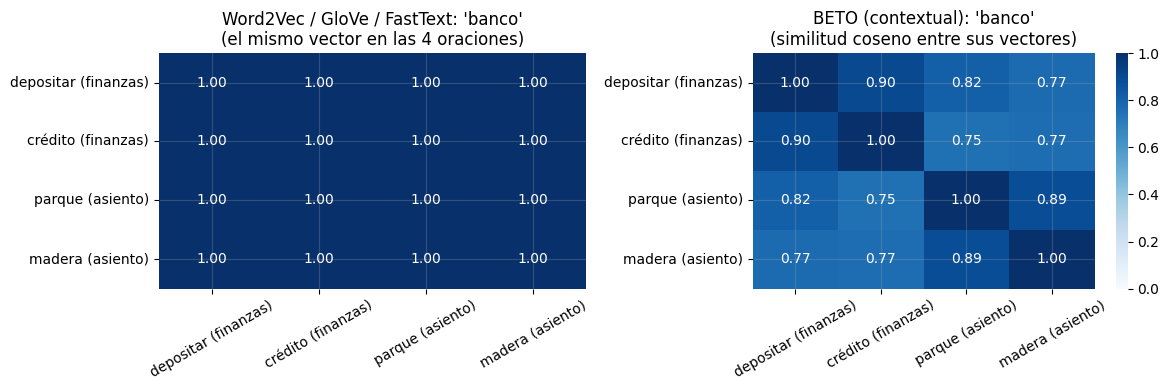

In [20]:
beto = AutoModel.from_pretrained(NOMBRE_BETO, attn_implementation="eager").to(DISPOSITIVO).eval()

def vector_contextual(oracion, palabra):
    # Vector de 'palabra' dentro de 'oracion': promedio de sus subpalabras en las últimas 4 capas de BETO
    cod = tok_beto(oracion, return_tensors="pt", return_offsets_mapping=True)
    desplazamientos = cod.pop("offset_mapping")[0].tolist()
    inicio = oracion.lower().index(palabra)
    fin = inicio + len(palabra)
    posiciones = [k for k, (a, b) in enumerate(desplazamientos) if a >= inicio and b <= fin and b > a]
    with torch.no_grad():
        salida = beto(**cod.to(DISPOSITIVO), output_hidden_states=True)
    capas = torch.stack(salida.hidden_states[-4:]).mean(0)[0]
    return capas[posiciones].mean(0).cpu().numpy()

ORACIONES_BANCO = ["Fui al banco a depositar mi sueldo.",
                   "El banco me negó el crédito hipotecario.",
                   "Me senté en un banco del parque a leer.",
                   "Los niños se sentaron en el banco de madera de la plaza."]
etiquetas = ["depositar (finanzas)", "crédito (finanzas)", "parque (asiento)", "madera (asiento)"]
vectores_banco = np.array([vector_contextual(o, "banco") for o in ORACIONES_BANCO])

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(np.ones((4, 4)), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ejes[0])
ejes[0].set_title("Word2Vec / GloVe / FastText: 'banco'\n(el mismo vector en las 4 oraciones)")
sns.heatmap(cosine_similarity(vectores_banco), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ejes[1])
ejes[1].set_title("BETO (contextual): 'banco'\n(similitud coseno entre sus vectores)")
for ax in ejes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Con embeddings estáticos, "banco" tiene exactamente el mismo vector en las cuatro oraciones (similitud 1.00), así que el modelo no puede distinguir sus significados. Con BETO, cada uso se parece más al de su mismo significado que al otro:

- los dos usos financieros tienen similitud **0.90**;
- los dos usos como asiento, **0.89**;
- los pares de significados distintos, entre **0.75 y 0.82**.

La separación no es total, porque las cuatro oraciones comparten la palabra y una estructura parecida. Aun así, el modelo usó el contexto ("depositar" y "crédito" frente a "parque" y "madera") para darle a "banco" una representación distinta según su significado.

**Embeddings de oraciones (Sentence-BERT).** Para un chatbot lo importante no es el vector de una palabra, sino el de una **pregunta completa**. Promediar vectores de palabras pierde el orden y el matiz. **Sentence-BERT** (Reimers y Gurevych, 2019) ajusta un Transformer con pares de oraciones parafraseadas para que las oraciones con el mismo significado queden cerca. Se usa el modelo multilingüe `paraphrase-multilingual-MiniLM-L12-v2`, que es ligero: 118 millones de parámetros y vectores de 384 dimensiones.

A continuación se compara con el promedio de vectores FastText, la mejor opción estática.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

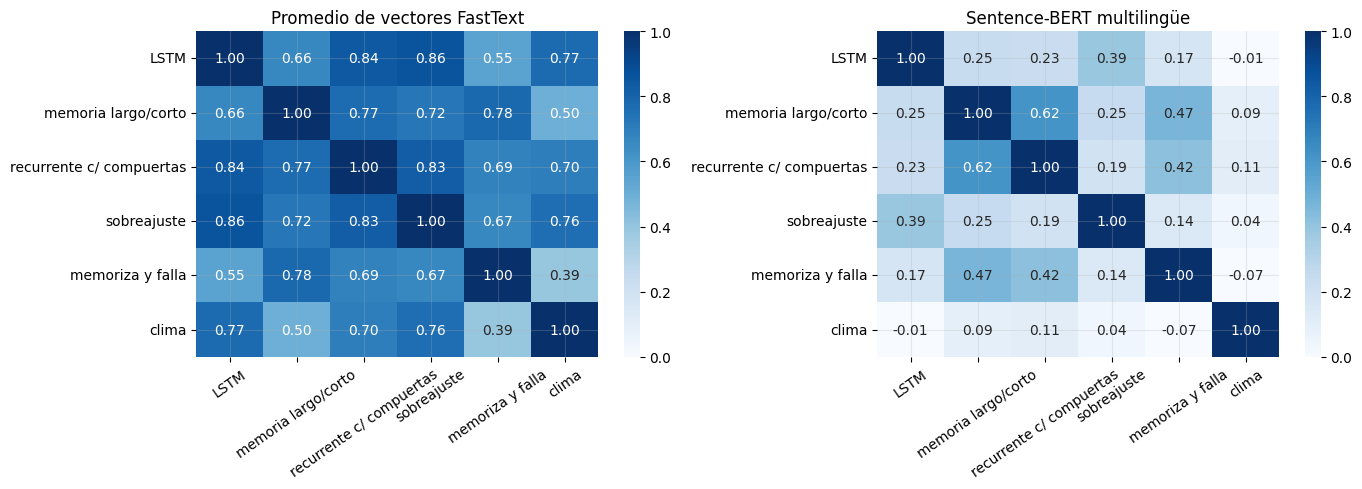

In [21]:
sbert = SentenceTransformer(NOMBRE_SBERT, device=str(DISPOSITIVO))

PREGUNTAS = ["¿Qué es una LSTM?",
             "Explícame las redes de memoria de largo y corto plazo",
             "¿Cómo funciona una red recurrente con compuertas?",
             "¿Qué es el sobreajuste de un modelo?",
             "Mi red memoriza los datos de entrenamiento y falla con datos nuevos",
             "¿Qué clima hará mañana?"]
cortas = ["LSTM", "memoria largo/corto", "recurrente c/ compuertas", "sobreajuste", "memoriza y falla", "clima"]

def promedio_fasttext(texto):
    return np.mean([fasttext[t] for t in tokenizar(texto)], axis=0)

sim_ft = cosine_similarity(np.array([promedio_fasttext(p) for p in PREGUNTAS]))
sim_sbert = cosine_similarity(sbert.encode(PREGUNTAS, normalize_embeddings=True))

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
for ax, matriz, titulo in [(ejes[0], sim_ft, "Promedio de vectores FastText"), (ejes[1], sim_sbert, "Sentence-BERT multilingüe")]:
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=cortas, yticklabels=cortas, ax=ax)
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

Esta comparación muestra tanto la fortaleza como la limitación del buscador semántico que usará el chatbot:

- **Promedio de FastText:** todas las preguntas se parecen entre sí (similitudes de 0.39 a 0.86), porque el promedio está dominado por palabras funcionales ("qué", "es", "de", "la"). La pregunta del clima tiene 0.77 de similitud con "¿Qué es una LSTM?", así que **no sirve para detectar preguntas fuera de dominio**.
- **Sentence-BERT separa con claridad lo que no tiene relación.** La pregunta del clima tiene similitud prácticamente nula con todas las demás (entre −0.07 y 0.11). También reconoce paráfrasis sin palabras en común: "memoria de largo y corto plazo" y "red recurrente con compuertas" tienen 0.62.
- **Pero no tiene conocimiento especializado.** No sabe que "LSTM" significa justamente "memoria de largo y corto plazo" (similitud de solo 0.25), ni que "memoriza los datos y falla con datos nuevos" describe el "sobreajuste" (0.14). Es un modelo general de paráfrasis, entrenado con lenguaje cotidiano.

Esta limitación explica dos decisiones del diseño del chatbot (sección 7):

1. La base de conocimiento incluye **varias formas de preguntar lo mismo** por intención. Por ejemplo, la intención "lstm" incluye "¿qué significa Long Short-Term Memory?".
2. La búsqueda semántica se **combina con un clasificador entrenado** con esas frases.

### 4.6 Comparación visual de los embeddings estáticos

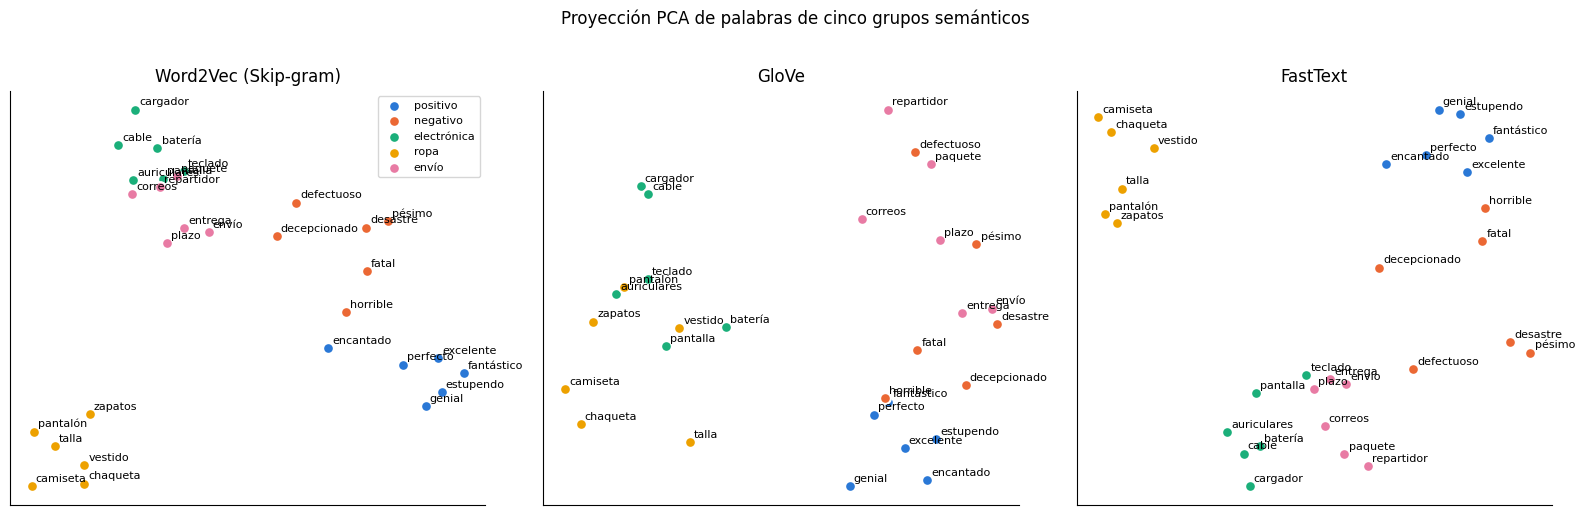

,Par,Word2Vec,GloVe,FastText
0,bueno / excelente,0.66,0.64,0.68
1,bueno / malo,0.70,0.77,0.70
2,rápido / lento,0.56,0.55,0.58
3,pantalla / batería,0.48,0.44,0.48
4,zapatos / talla,0.34,0.09,0.42
5,envío / paquete,0.60,0.58,0.59
6,lstm / gru,0.85,0.85,0.82
7,bueno / mesa,0.23,0.32,0.23


In [22]:
GRUPOS = {
    "positivo": ["excelente", "genial", "perfecto", "encantado", "estupendo", "fantástico"],
    "negativo": ["pésimo", "horrible", "defectuoso", "decepcionado", "fatal", "desastre"],
    "electrónica": ["pantalla", "batería", "cargador", "cable", "auriculares", "teclado"],
    "ropa": ["talla", "camiseta", "zapatos", "pantalón", "vestido", "chaqueta"],
    "envío": ["envío", "paquete", "entrega", "repartidor", "correos", "plazo"],
}
palabras_vis = [w for ws in GRUPOS.values() for w in ws]
grupo_de = {w: g for g, ws in GRUPOS.items() for w in ws}

fig, ejes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nombre, kv) in zip(ejes, [("Word2Vec (Skip-gram)", w2v), ("GloVe", glove), ("FastText", fasttext)]):
    vectores = np.array([kv[w] for w in palabras_vis])
    vectores = vectores / np.linalg.norm(vectores, axis=1, keepdims=True)   # Normalizar: la similitud coseno es lo relevante
    coords = PCA(n_components=2, random_state=SEMILLA).fit_transform(vectores)
    for k, grupo in enumerate(GRUPOS):
        idx = [i for i, w in enumerate(palabras_vis) if grupo_de[w] == grupo]
        ax.scatter(coords[idx, 0], coords[idx, 1], s=60, color=PALETA[k], label=grupo, edgecolor="white", linewidth=1.5)
        for i in idx:
            ax.annotate(palabras_vis[i], coords[i], fontsize=8, xytext=(3, 3), textcoords="offset points")
    ax.set_title(nombre)
    ax.set_xticks([])
    ax.set_yticks([])
ejes[0].legend(loc="best", fontsize=8)
plt.suptitle("Proyección PCA de palabras de cinco grupos semánticos", y=1.02)
plt.tight_layout()
plt.show()

PARES = [("bueno", "excelente"), ("bueno", "malo"), ("rápido", "lento"), ("pantalla", "batería"),
         ("zapatos", "talla"), ("envío", "paquete"), ("lstm", "gru"), ("bueno", "mesa")]
pd.DataFrame([{"Par": f"{a} / {b}", "Word2Vec": w2v.similarity(a, b), "GloVe": glove.similarity(a, b),
               "FastText": fasttext.similarity(a, b)} for a, b in PARES]).round(2)

**Análisis comparativo de los embeddings.**

- **Word2Vec y FastText forman grupos semánticos nítidos** sin haber recibido etiquetas. La ropa y los adjetivos positivos forman regiones separadas, y los adjetivos negativos ocupan una región propia junto a los positivos: todos son adjetivos valorativos.
- **Electrónica y envío se mezclan** en los tres modelos, porque aparecen juntos en las mismas reseñas ("el cargador llegó en el paquete").
- **GloVe forma grupos menos definidos:** la ropa se mezcla con la electrónica y "defectuoso" queda junto a "paquete" y "repartidor". Esto es coherente con lo observado en la sección 4.3: sus vectores reflejan más la co-ocurrencia que la sustitución.
- **Los antónimos se parecen más que los sinónimos.** En los tres modelos, "bueno/malo" (0.70 a 0.77) es **más similar** que "bueno/excelente" (0.64 a 0.68). Los adjetivos de polaridad opuesta aparecen en contextos idénticos ("el producto es ___"). Los embeddings capturan **de qué se habla**, no **qué se opina**; por eso el sentimiento necesita un modelo supervisado (sección 6).
- **Una palabra sin relación ("bueno/mesa") tiene la similitud más baja** (0.23 a 0.32), y los términos técnicos agregados ("lstm/gru", 0.82 a 0.85) quedan muy cerca. La geometría es significativa.

| Embedding | Idea | Ventajas | Limitaciones |
|---|---|---|---|
| One-hot / TF-IDF | Conteos dispersos | Simple, interpretable, línea base fuerte | Sin semántica, sin orden, vectores enormes |
| Word2Vec | Predecir el contexto local | Rápido, captura analogías | Sin vector para palabras OOV, un vector por palabra |
| GloVe | Factorizar co-ocurrencias globales | Usa estadística global, resultados similares a Word2Vec | Igual que Word2Vec; la matriz consume mucha memoria |
| **FastText** | Word2Vec con n-gramas de caracteres | **Vectores para palabras OOV y mal escritas**, morfología | Sigue siendo estático: no distingue la polisemia |
| **Contextuales (BETO, Sentence-BERT)** | Transformer: el vector depende de la oración | **Resuelven la polisemia, entienden paráfrasis**, estado del arte | Modelos grandes y más lentos, requieren GPU |

## 5. Modelos secuenciales: RNN, LSTM y GRU

Los embeddings convierten cada palabra en un vector, pero un texto es una **secuencia** en la que el orden importa. Una red densa necesita una entrada de tamaño fijo y no comparte lo aprendido entre posiciones. Las **redes recurrentes** procesan la secuencia paso a paso con los **mismos pesos** en cada posición y mantienen un **estado oculto** $\mathbf{h}_t$ que resume lo leído hasta el momento.

### 5.1 Ecuaciones de cada celda

**RNN simple (Elman, 1990):**

$$\mathbf{h}_t = \tanh(\mathbf{W}_{x}\mathbf{x}_t + \mathbf{W}_{h}\mathbf{h}_{t-1} + \mathbf{b})$$

**LSTM (Hochreiter y Schmidhuber, 1997).** Agrega un **estado de celda** $\mathbf{c}_t$, que funciona como una memoria de largo plazo, y tres **compuertas** con activación sigmoide (valores entre 0 y 1) que regulan el flujo de información:

$$
\begin{aligned}
\mathbf{f}_t &= \sigma(\mathbf{W}_f[\mathbf{x}_t, \mathbf{h}_{t-1}] + \mathbf{b}_f) && \text{compuerta de olvido: qué borrar de la memoria} \\
\mathbf{i}_t &= \sigma(\mathbf{W}_i[\mathbf{x}_t, \mathbf{h}_{t-1}] + \mathbf{b}_i) && \text{compuerta de entrada: qué escribir} \\
\tilde{\mathbf{c}}_t &= \tanh(\mathbf{W}_c[\mathbf{x}_t, \mathbf{h}_{t-1}] + \mathbf{b}_c) && \text{contenido candidato} \\
\mathbf{c}_t &= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t && \text{actualización aditiva de la memoria} \\
\mathbf{o}_t &= \sigma(\mathbf{W}_o[\mathbf{x}_t, \mathbf{h}_{t-1}] + \mathbf{b}_o) && \text{compuerta de salida: qué exponer} \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t)
\end{aligned}
$$

**GRU (Cho et al., 2014).** Simplifica la LSTM: fusiona la celda con el estado oculto y usa solo dos compuertas:

$$
\begin{aligned}
\mathbf{z}_t &= \sigma(\mathbf{W}_z\mathbf{x}_t + \mathbf{U}_z\mathbf{h}_{t-1} + \mathbf{b}_z) && \text{compuerta de actualización} \\
\mathbf{r}_t &= \sigma(\mathbf{W}_r\mathbf{x}_t + \mathbf{U}_r\mathbf{h}_{t-1} + \mathbf{b}_r) && \text{compuerta de reinicio} \\
\tilde{\mathbf{h}}_t &= \tanh(\mathbf{W}_h\mathbf{x}_t + \mathbf{r}_t \odot (\mathbf{U}_h\mathbf{h}_{t-1}) + \mathbf{b}_h) && \text{candidato} \\
\mathbf{h}_t &= (1 - \mathbf{z}_t) \odot \tilde{\mathbf{h}}_t + \mathbf{z}_t \odot \mathbf{h}_{t-1} && \text{interpolación entre lo nuevo y lo anterior}
\end{aligned}
$$

La clave de la LSTM y la GRU es la **actualización aditiva**: $\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \ldots$. Si la compuerta de olvido vale cerca de 1, la derivada $\partial \mathbf{c}_t / \partial \mathbf{c}_{t-1} \approx \mathbf{f}_t \approx 1$, y el gradiente puede viajar muchos pasos hacia atrás sin desvanecerse. En la RNN simple, en cambio, el gradiente se multiplica en cada paso por $\mathbf{W}_h$ y por la derivada de $\tanh$ (que es menor que 1), así que decae de forma exponencial.

### 5.2 Implementación a mano y verificación contra PyTorch

Para comprobar que las ecuaciones anteriores son exactamente las que usa PyTorch, se implementa un paso de cada celda con operaciones básicas. Luego se procesa una secuencia con los **mismos pesos** que `nn.RNN`, `nn.LSTM` y `nn.GRU`, y se comparan las salidas.

In [23]:
def paso_rnn(x, h, W_ih, W_hh, b_ih, b_hh):
    return torch.tanh(x @ W_ih.T + b_ih + h @ W_hh.T + b_hh)

def paso_lstm(x, h, c, W_ih, W_hh, b_ih, b_hh):
    compuertas = x @ W_ih.T + b_ih + h @ W_hh.T + b_hh
    i, f, g, o = compuertas.chunk(4, dim=1)             # PyTorch guarda los bloques en orden: entrada, olvido, candidato, salida
    i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
    g = torch.tanh(g)
    c = f * c + i * g                                   # Memoria: olvidar una parte y escribir el candidato
    h = o * torch.tanh(c)
    return h, c

def paso_gru(x, h, W_ih, W_hh, b_ih, b_hh):
    r_x, z_x, n_x = (x @ W_ih.T + b_ih).chunk(3, dim=1)  # Orden en PyTorch: reinicio, actualización, candidato
    r_h, z_h, n_h = (h @ W_hh.T + b_hh).chunk(3, dim=1)
    r = torch.sigmoid(r_x + r_h)
    z = torch.sigmoid(z_x + z_h)
    n = torch.tanh(n_x + r * n_h)
    return (1 - z) * n + z * h

fijar_semilla()
lote, pasos, d_entrada, d_oculta = 4, 12, 8, 16
x = torch.randn(lote, pasos, d_entrada)
filas = []
for nombre, clase in [("RNN", nn.RNN), ("LSTM", nn.LSTM), ("GRU", nn.GRU)]:
    capa = clase(d_entrada, d_oculta, batch_first=True)
    pesos = (capa.weight_ih_l0, capa.weight_hh_l0, capa.bias_ih_l0, capa.bias_hh_l0)
    with torch.no_grad():
        salida_torch, _ = capa(x)
        h = torch.zeros(lote, d_oculta)
        c = torch.zeros(lote, d_oculta)
        salidas = []
        for t in range(pasos):
            if nombre == "RNN":
                h = paso_rnn(x[:, t], h, *pesos)
            elif nombre == "LSTM":
                h, c = paso_lstm(x[:, t], h, c, *pesos)
            else:
                h = paso_gru(x[:, t], h, *pesos)
            salidas.append(h)
        salida_manual = torch.stack(salidas, dim=1)
    num_param = sum(p.numel() for p in capa.parameters())
    bloques = {"RNN": 1, "LSTM": 4, "GRU": 3}[nombre]
    filas.append({"Celda": nombre, "Diferencia máxima manual vs PyTorch": f"{(salida_manual - salida_torch).abs().max().item():.1e}",
                  "Parámetros (PyTorch)": num_param,
                  "Fórmula: bloques x (h·d + h·h + 2h)": bloques * (d_oculta * d_entrada + d_oculta**2 + 2 * d_oculta)})
pd.DataFrame(filas)

,Celda,Diferencia máxima manual vs PyTorch,Parámetros (PyTorch),Fórmula: bloques x (h·d + h·h + 2h)
0,RNN,8.9e-08,416,416
1,LSTM,8.9e-08,1664,1664
2,GRU,6.0e-08,1248,1248


Las implementaciones a mano coinciden con PyTorch hasta el error de redondeo de punto flotante (del orden de $10^{-7}$). Esto confirma que las ecuaciones de la sección 5.1 son exactamente las que se ejecutan.

El conteo de parámetros sigue la fórmula $\text{bloques} \times (h \cdot d + h^2 + 2h)$, donde $d$ es la dimensión de entrada y $h$ la del estado oculto:

- La **LSTM** tiene 4 bloques (tres compuertas y el candidato).
- La **GRU** tiene 3, así que usa **25 % menos parámetros** que la LSTM.
- La **RNN** tiene 1.

### 5.3 Experimento: dependencias de largo plazo y gradiente desvaneciente

Para ver el problema de la RNN simple se diseña una tarea de **memoria pura**:

- Cada secuencia empieza con un símbolo "señal" entre 4 posibles, seguido de $T - 1$ símbolos de ruido aleatorio.
- La red debe predecir, **al final de la secuencia**, cuál era el primer símbolo.

Para resolverla hay que llevar esa información a lo largo de todos los pasos. Se entrenan RNN, LSTM y GRU (estado oculto de 64) con longitudes $T$ de 10, 30, 60 y 100. Con 4 clases, el azar corresponde al 25 % de exactitud.

**Inicialización de las compuertas.** En la primera versión de este experimento (1,500 pasos de entrenamiento e inicialización por defecto de PyTorch) **las tres arquitecturas fallaron con $T \geq 30$**. La causa está en el sesgo de las compuertas:

- Con sesgo cero, la compuerta de olvido de la LSTM empieza en $\sigma(0) = 0.5$. La red arranca olvidando la mitad de su memoria en cada paso ($0.5^{100} \approx 10^{-30}$), así que al principio tampoco le llega gradiente desde el primer símbolo.
- La práctica recomendada (Gers et al., 2000; Jozefowicz et al., 2015) es iniciar ese sesgo en un valor positivo para que la red **empiece recordando**. Para secuencias largas se usan valores mayores (Tallec y Ollivier, 2018).

Aquí se usan estos valores, con 3,000 pasos de entrenamiento:

- **LSTM:** sesgo de 3 en la compuerta de olvido, es decir, $\sigma(3) \approx 0.95$.
- **GRU:** sesgo de 2 en la compuerta de actualización, es decir, $\sigma(2) \approx 0.88$; la GRU conserva el 88 % de su estado anterior.

La RNN simple no tiene compuertas, así que no tiene un parámetro equivalente que ajustar.

In [24]:
NUM_SENALES, NUM_SIMBOLOS = 4, 12

def generar_lote_memoria(tam, longitud, generador):
    # Primer símbolo: la señal (0 a 3). El resto: ruido (4 a 11). La etiqueta es la señal
    senal = torch.randint(0, NUM_SENALES, (tam,), generator=generador)
    ruido = torch.randint(NUM_SENALES, NUM_SIMBOLOS, (tam, longitud - 1), generator=generador)
    return torch.cat([senal[:, None], ruido], dim=1), senal


# Sesgo inicial de la compuerta de olvido (LSTM) y de la de actualización (GRU): arrancan "recordando"
SESGO_COMPUERTA = {"LSTM": 3.0, "GRU": 2.0}

class ModeloMemoria(nn.Module):
    def __init__(self, tipo, d_oculta=64):
        super().__init__()
        self.emb = nn.Embedding(NUM_SIMBOLOS, 16)
        self.rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[tipo](16, d_oculta, batch_first=True)
        if tipo in SESGO_COMPUERTA:
            # PyTorch suma bias_ih y bias_hh, así que el valor se pone en uno y el otro queda en cero.
            # El segundo bloque de sesgos es la compuerta de olvido en la LSTM y la de actualización en la GRU
            with torch.no_grad():
                self.rnn.bias_ih_l0[d_oculta:2 * d_oculta] = SESGO_COMPUERTA[tipo]
                self.rnn.bias_hh_l0[d_oculta:2 * d_oculta] = 0.0
        self.salida = nn.Linear(d_oculta, NUM_SENALES)

    def forward(self, x, devolver_emb=False):
        e = self.emb(x)
        if devolver_emb:
            e.retain_grad()                    # Para medir el gradiente que llega a cada paso de tiempo
        salidas, _ = self.rnn(e)
        logits = self.salida(salidas[:, -1])   # Solo se usa el último estado oculto
        return (logits, e) if devolver_emb else logits


def entrenar_memoria(tipo, longitud, pasos=3000, tam_lote=128):
    fijar_semilla()
    generador = torch.Generator().manual_seed(SEMILLA)
    modelo = ModeloMemoria(tipo).to(DISPOSITIVO)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=2e-3)
    for paso in range(pasos):
        x, y = generar_lote_memoria(tam_lote, longitud, generador)
        perdida = F.cross_entropy(modelo(x.to(DISPOSITIVO)), y.to(DISPOSITIVO))
        optimizador.zero_grad()
        perdida.backward()
        nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)   # Recorte de gradiente contra la explosión
        optimizador.step()
    modelo.eval()
    x, y = generar_lote_memoria(2000, longitud, torch.Generator().manual_seed(123))
    with torch.no_grad():
        exactitud = (modelo(x.to(DISPOSITIVO)).argmax(1).cpu() == y).float().mean().item()
    return modelo, exactitud


RUTA_MEMORIA = RUTA_MODELOS / "experimento_memoria.json"
LONGITUDES = [10, 30, 60, 100]
modelos_memoria = {}
if RUTA_MEMORIA.exists():
    resultados_memoria = json.load(open(RUTA_MEMORIA))
    for tipo in ["RNN", "LSTM", "GRU"]:
        modelos_memoria[tipo] = ModeloMemoria(tipo).to(DISPOSITIVO)
        modelos_memoria[tipo].load_state_dict(torch.load(RUTA_MODELOS / f"memoria_{tipo}_100.pt"))
        modelos_memoria[tipo].eval()
else:
    resultados_memoria, inicio = {}, time.time()
    for tipo in ["RNN", "LSTM", "GRU"]:
        resultados_memoria[tipo] = {}
        for longitud in LONGITUDES:
            modelo, exactitud = entrenar_memoria(tipo, longitud)
            resultados_memoria[tipo][str(longitud)] = exactitud
            if longitud == 100:
                modelos_memoria[tipo] = modelo
                torch.save(modelo.state_dict(), RUTA_MODELOS / f"memoria_{tipo}_100.pt")
    json.dump(resultados_memoria, open(RUTA_MEMORIA, "w"))
    print(f"Experimento completado en {time.time() - inicio:.0f} s")

tabla_memoria = pd.DataFrame(resultados_memoria).T
tabla_memoria.columns = [f"T = {c}" for c in tabla_memoria.columns]
print("Exactitud en la tarea de memoria (azar = 25 %):")
print((tabla_memoria * 100).round(1).astype(str).add(" %").to_string())

Exactitud en la tarea de memoria (azar = 25 %):
       T = 10   T = 30   T = 60  T = 100
RNN   100.0 %   24.7 %   26.7 %   24.8 %
LSTM  100.0 %  100.0 %  100.0 %  100.0 %
GRU   100.0 %  100.0 %  100.0 %  100.0 %


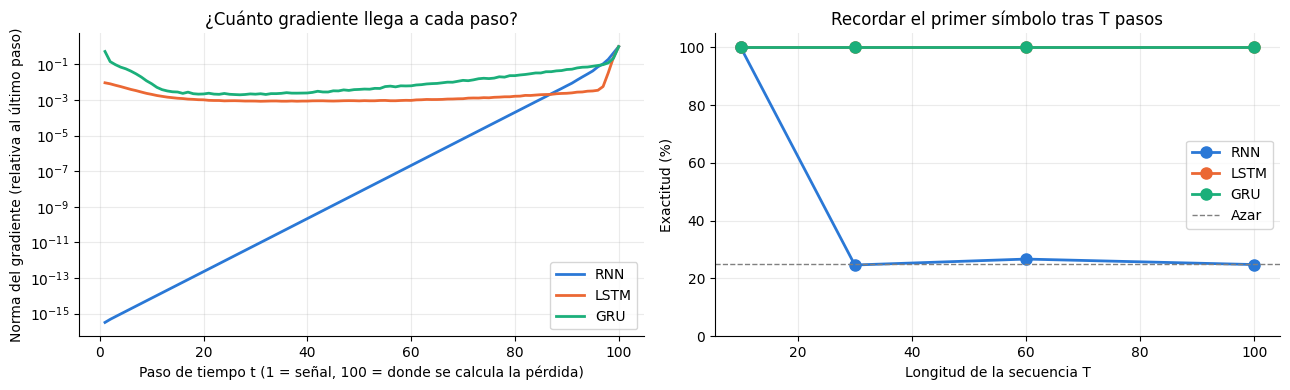

In [25]:
# Gradiente de la pérdida con respecto a la entrada de cada paso de tiempo (modelos entrenados con T = 100)
x, y = generar_lote_memoria(256, 100, torch.Generator().manual_seed(7))
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
for k, (tipo, modelo) in enumerate(modelos_memoria.items()):
    modelo.train()                           # cuDNN solo permite retropropagar en modo entrenamiento
    logits, emb = modelo(x.to(DISPOSITIVO), devolver_emb=True)
    F.cross_entropy(logits, y.to(DISPOSITIVO)).backward()
    norma = emb.grad.norm(dim=2).mean(0).cpu().numpy()     # Norma promedio del gradiente en cada paso t
    ejes[0].semilogy(range(1, 101), norma / norma[-1], color=PALETA[k], linewidth=2, label=tipo)
    modelo.eval()
ejes[0].set_xlabel("Paso de tiempo t (1 = señal, 100 = donde se calcula la pérdida)")
ejes[0].set_ylabel("Norma del gradiente (relativa al último paso)")
ejes[0].set_title("¿Cuánto gradiente llega a cada paso?")
ejes[0].legend()

for k, tipo in enumerate(tabla_memoria.index):
    ejes[1].plot(LONGITUDES, tabla_memoria.loc[tipo].values * 100, marker="o", markersize=8, linewidth=2, color=PALETA[k], label=tipo)
ejes[1].axhline(25, color="gray", linestyle="--", linewidth=1, label="Azar")
ejes[1].set_xlabel("Longitud de la secuencia T")
ejes[1].set_ylabel("Exactitud (%)")
ejes[1].set_title("Recordar el primer símbolo tras T pasos")
ejes[1].set_ylim(0, 105)
ejes[1].legend()
plt.tight_layout()
plt.show()

Este experimento es la demostración central de por qué existen la LSTM y la GRU:

- **Con secuencias cortas ($T = 10$), las tres arquitecturas resuelven la tarea al 100 %.** La RNN simple sí puede recordar, siempre que la distancia sea pequeña.
- **Desde $T = 30$, la RNN simple cae al azar (entre 24.7 % y 26.7 %),** mientras que **la LSTM y la GRU mantienen el 100 % hasta $T = 100$**. En la gráfica derecha sus líneas se superponen.
- **La gráfica de gradientes muestra la causa.**
  - En la RNN, el gradiente que llega al paso 1 es unas **$10^{16}$ veces más pequeño** que el del último paso. La recta en escala logarítmica indica un decaimiento exponencial: el gradiente se multiplica por un factor de alrededor de 0.7 en cada paso hacia atrás. Así, la red no puede aprender que el primer símbolo importa.
  - En la LSTM y la GRU la curva es casi plana: el gradiente que llega al primer paso es del mismo orden que el de los pasos intermedios, gracias al camino aditivo de la memoria. En la GRU incluso aumenta en los primeros pasos, porque la red aprendió a dirigir el gradiente hacia el símbolo que importa.

El experimento deja además una lección práctica: **la arquitectura sola no basta, la inicialización también importa**. Con la inicialización por defecto, la ventaja teórica de las compuertas no se materializó en 1,500 pasos.

En texto real, esto se traduce en que una RNN simple "olvida" el inicio de una reseña larga, como en "La batería, que al principio parecía durar bastante, terminó fallando". La sección 6.7 lo confirma con datos reales.

### 5.4 Bidireccionalidad, atención y el salto al Transformer

- **Redes bidireccionales:** una RNN lee de izquierda a derecha y otra de derecha a izquierda, y sus estados se concatenan. Así cada palabra tiene contexto del pasado y del futuro, lo que ayuda a clasificar ("no es malo" frente a "malo, no lo compren").
- **Atención (Bahdanau et al., 2015):** en lugar de usar solo el último estado oculto, la red aprende un peso $\alpha_t$ para cada posición y combina todos los estados:

$$e_t = \mathbf{v}^\top \tanh(\mathbf{W}\mathbf{h}_t), \qquad \alpha_t = \frac{\exp(e_t)}{\sum_k \exp(e_k)}, \qquad \mathbf{r} = \sum_t \alpha_t \mathbf{h}_t$$

  Esto crea atajos directos desde cualquier palabra hasta la salida y, además, hace el modelo **interpretable**: los pesos $\alpha_t$ indican qué palabras usó para decidir.
- **Transformer (Vaswani et al., 2017):** la idea se lleva al extremo con *"Attention is all you need"*. Elimina la recurrencia y usa solo **autoatención**: cada palabra calcula una consulta $Q$, una clave $K$ y un valor $V$, y

$$\text{Atención}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

  Aquí $d_k$ es la dimensión de las claves; dividir entre $\sqrt{d_k}$ evita que el softmax se sature. **Cualquier par de palabras está a un solo paso de distancia** (sin gradiente desvaneciente) y **todas las posiciones se procesan en paralelo** (una RNN debe esperar al paso $t - 1$ para calcular el paso $t$). La información del orden se agrega con codificaciones posicionales.

La siguiente figura muestra la autoatención real de BETO: el promedio de las 12 cabezas de su última capa.

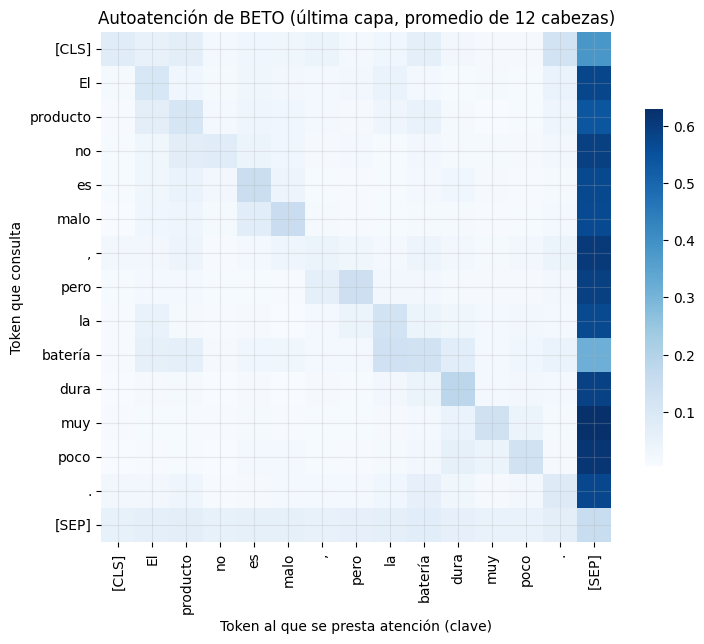

In [26]:
oracion = "El producto no es malo, pero la batería dura muy poco."
cod = tok_beto(oracion, return_tensors="pt").to(DISPOSITIVO)
with torch.no_grad():
    atenciones = beto(**cod, output_attentions=True).attentions   # 12 capas, cada una (1, 12 cabezas, n, n)
tokens_vis = tok_beto.convert_ids_to_tokens(cod["input_ids"][0])
matriz = atenciones[-1][0].mean(0).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(matriz, xticklabels=tokens_vis, yticklabels=tokens_vis, cmap="Blues", square=True, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_xlabel("Token al que se presta atención (clave)")
ax.set_ylabel("Token que consulta")
ax.set_title("Autoatención de BETO (última capa, promedio de 12 cabezas)")
plt.tight_layout()
plt.show()

del beto
torch.cuda.empty_cache()

Cada fila muestra a qué tokens "mira" una palabra para construir su representación contextual:

- **El token `[SEP]` concentra la mayor parte de la atención** (la columna oscura de la derecha). Es un comportamiento documentado en BERT (Clark et al., 2019): cuando una cabeza no encuentra una relación relevante, deposita su atención en `[SEP]`, que funciona como un "sumidero".
- **El resto se concentra en la diagonal:** cada palabra atiende a sí misma y a sus vecinas inmediatas (por ejemplo, "batería" a "la" y a "dura"), es decir, a su contexto local.
- El promedio de las 12 cabezas oculta su especialización. Clark et al. (2019) muestran que algunas cabezas individuales capturan relaciones sintácticas concretas, como la de un verbo con su objeto.

A diferencia de una RNN, **cada palabra puede acceder directamente a todas las demás** en un solo paso, sin importar la distancia.

## 6. Análisis de sentimientos: comparación de arquitecturas y embeddings

El análisis de sentimientos es la tarea en la que se comparan experimentalmente todas las piezas anteriores. Clasificar la polaridad de una reseña exige entender negaciones ("no está nada mal"), contrastes ("bonito, pero frágil") y dependencias largas.

Todos los modelos usan los mismos datos (60,000 reseñas de entrenamiento, 5,000 de validación y 5,000 de prueba), la misma métrica (F1 macro) y el mismo procedimiento:

| Aspecto | Configuración |
|---|---|
| Optimizador | AdamW, tasa de aprendizaje de $10^{-3}$ |
| Lote | 128 reseñas |
| Recorte de gradiente | Norma máxima de 1.0 |
| Dropout | 0.3 |
| Parada temprana | Paciencia de 2 épocas, según el F1 de validación |
| Épocas | Hasta 8 |

El conjunto de prueba se usa solo una vez, al final.

### 6.1 Vocabulario y codificación

In [27]:
TAM_VOCAB_MAX, LONG_MAX, TAM_LOTE = 30_000, 150, 128

vocab = ["<pad>", "<unk>"] + [w for w, c in conteo_ent.most_common(TAM_VOCAB_MAX) if c >= 2]
indice_vocab = {w: i for i, w in enumerate(vocab)}

def codificar(tokens):
    # Palabras -> índices. Las desconocidas van a <unk> (1). Se trunca a LONG_MAX tokens
    ids = [indice_vocab.get(t, 1) for t in tokens][:LONG_MAX]
    return ids or [1]

class DatosSecuencia(torch.utils.data.Dataset):
    # Guarda secuencias (listas de índices o matrices de vectores) y sus etiquetas
    def __init__(self, secuencias, etiquetas):
        self.secuencias, self.etiquetas = list(secuencias), list(etiquetas)
    def __len__(self):
        return len(self.secuencias)
    def __getitem__(self, i):
        return self.secuencias[i], self.etiquetas[i]

def agrupar_lote(lote):
    # Rellena con ceros hasta la secuencia más larga del lote y devuelve las longitudes reales
    secuencias, etiquetas = zip(*lote)
    longitudes = torch.tensor([len(s) for s in secuencias])
    x = pad_sequence([torch.as_tensor(np.asarray(s)) for s in secuencias], batch_first=True, padding_value=0)
    return x, longitudes, torch.tensor(etiquetas)

def crear_cargador(secuencias, etiquetas, mezclar=False, tam_lote=TAM_LOTE):
    generador = torch.Generator().manual_seed(SEMILLA)
    return torch.utils.data.DataLoader(DatosSecuencia(secuencias, etiquetas), batch_size=tam_lote,
                                       shuffle=mezclar, collate_fn=agrupar_lote, generator=generador)

ids_ent = [codificar(t) for t in df_ent["tokens"]]
ids_val = [codificar(t) for t in df_val["tokens"]]
ids_pru = [codificar(t) for t in df_pru["tokens"]]
y_ent, y_val, y_pru = df_ent["sentimiento"].values, df_val["sentimiento"].values, df_pru["sentimiento"].values

cargador_ent = crear_cargador(ids_ent, y_ent, mezclar=True)
cargador_val = crear_cargador(ids_val, y_val)
cargador_pru = crear_cargador(ids_pru, y_pru)

print(f"Vocabulario: {len(vocab):,} palabras (incluye <pad> y <unk>)")
ejemplo = df_ent["text"].iloc[0]
print(f"\nEjemplo: {ejemplo[:70]}...\nÍndices: {codificar(df_ent['tokens'].iloc[0])[:14]}...")

Vocabulario: 21,320 palabras (incluye <pad> y <unk>)

Ejemplo: Es un kit donde todo parece de juguete, la caja dónde viene todo guard...
Índices: [8, 15, 1101, 221, 49, 61, 2, 590, 5, 111, 1655, 93, 49, 3334]...


### 6.2 Arquitectura común y bucle de entrenamiento

Se define **una sola clase** configurable para todos los modelos recurrentes, de modo que las comparaciones aíslen el factor que se estudia. Sus componentes son:

1. **Capa de embedding** (100 dimensiones): una tabla de búsqueda entrenable que convierte cada índice en un vector. Puede inicializarse con Word2Vec, GloVe o FastText. Si no se incluye, la red recibe directamente vectores ya calculados, como en el chatbot.
2. **Capa recurrente** (128 unidades): RNN, LSTM o GRU, unidireccional o bidireccional. Se usa `pack_padded_sequence` para que la red **no procese el relleno**; sin esto, en una red unidireccional el último estado oculto correspondería a ceros de relleno y no a la última palabra.
3. **Representación de la secuencia:**
   - *sin atención*, se usa el último estado oculto (en las bidireccionales, el último de cada dirección);
   - *con atención*, se usa el promedio ponderado de todos los estados (sección 5.4), enmascarando el relleno.
4. **Dropout** (0.3) y una **capa lineal** de salida hacia las 3 clases. La función de pérdida es la entropía cruzada.

In [28]:
class ClasificadorTexto(nn.Module):
    def __init__(self, tipo="lstm", tam_vocab=None, dim_emb=100, dim_oculta=128, bidireccional=False,
                 atencion=False, pesos_emb=None, num_clases=3, dropout=0.3):
        super().__init__()
        self.embedding = None
        if tam_vocab is not None:                       # Si es None, la entrada ya son vectores
            self.embedding = nn.Embedding(tam_vocab, dim_emb, padding_idx=0)
            if pesos_emb is not None:
                self.embedding.weight.data.copy_(torch.as_tensor(pesos_emb))
        clase_rnn = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[tipo]
        self.rnn = clase_rnn(dim_emb, dim_oculta, batch_first=True, bidirectional=bidireccional)
        self.bidireccional = bidireccional
        dim_rep = dim_oculta * (2 if bidireccional else 1)
        self.atencion = (nn.Sequential(nn.Linear(dim_rep, dim_rep), nn.Tanh(), nn.Linear(dim_rep, 1, bias=False))
                         if atencion else None)
        self.dropout = nn.Dropout(dropout)
        self.salida = nn.Linear(dim_rep, num_clases)
        self.pesos_atencion = None                      # Se guardan para poder visualizarlos

    def forward(self, x, longitudes):
        emb = self.dropout(self.embedding(x) if self.embedding is not None else x.float())
        empaquetado = pack_padded_sequence(emb, longitudes.cpu(), batch_first=True, enforce_sorted=False)
        salidas, estado = self.rnn(empaquetado)
        if self.atencion is None:
            h_n = estado[0] if isinstance(estado, tuple) else estado      # La LSTM devuelve (h, c)
            rep = torch.cat([h_n[-2], h_n[-1]], dim=1) if self.bidireccional else h_n[-1]
        else:
            salidas, _ = pad_packed_sequence(salidas, batch_first=True, total_length=emb.size(1))
            mascara = torch.arange(emb.size(1), device=emb.device)[None, :] < longitudes.to(emb.device)[:, None]
            puntajes = self.atencion(salidas).squeeze(-1).masked_fill(~mascara, float("-inf"))
            pesos = torch.softmax(puntajes, dim=1)
            self.pesos_atencion = pesos.detach()
            rep = (pesos.unsqueeze(-1) * salidas).sum(dim=1)
        return self.salida(self.dropout(rep))


def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)


@torch.no_grad()
def predecir(modelo, cargador):
    # Devuelve etiquetas reales, predicciones, probabilidades y pérdida promedio
    modelo.eval()
    reales, probs, perdida_total = [], [], 0.0
    for x, longitudes, y in cargador:
        logits = modelo(x.to(DISPOSITIVO), longitudes)
        perdida_total += F.cross_entropy(logits, y.to(DISPOSITIVO), reduction="sum").item()
        probs.append(torch.softmax(logits, 1).cpu().numpy())
        reales.append(y.numpy())
    reales, probs = np.concatenate(reales), np.concatenate(probs)
    return reales, probs.argmax(1), probs, perdida_total / len(reales)


def entrenar_modelo(nombre, modelo, cargador_ent, cargador_val, epocas=8, lr=1e-3, paciencia=2, decaimiento=0.0, verbose=True):
    # Entrena con parada temprana según el F1 macro de validación y guarda el mejor estado.
    # Si el modelo ya fue entrenado, lo carga desde disco.
    ruta_pesos, ruta_hist = RUTA_MODELOS / f"{nombre}.pt", RUTA_MODELOS / f"{nombre}_historial.json"
    modelo.to(DISPOSITIVO)
    if ruta_pesos.exists() and ruta_hist.exists():
        modelo.load_state_dict(torch.load(ruta_pesos, map_location=DISPOSITIVO))
        info = json.load(open(ruta_hist))
        if verbose:
            print(f"{nombre}: cargado desde disco (F1 de validación: {max(h['f1_val'] for h in info['historial']):.4f})")
        return modelo, pd.DataFrame(info["historial"]), info["tiempo_s"]

    fijar_semilla()
    optimizador = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=decaimiento)
    historial, mejor_f1, mejor_estado, sin_mejora, inicio = [], -1.0, None, 0, time.time()
    for epoca in range(1, epocas + 1):
        modelo.train()
        suma_perdida, aciertos, n = 0.0, 0, 0
        for x, longitudes, y in cargador_ent:
            x, y = x.to(DISPOSITIVO), y.to(DISPOSITIVO)
            logits = modelo(x, longitudes)
            perdida = F.cross_entropy(logits, y)
            optimizador.zero_grad()
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            optimizador.step()
            suma_perdida += perdida.item() * len(y)
            aciertos += (logits.argmax(1) == y).sum().item()
            n += len(y)
        reales, pred, _, perdida_val = predecir(modelo, cargador_val)
        f1_val = f1_score(reales, pred, average="macro")
        historial.append({"epoca": epoca, "perdida_ent": suma_perdida / n, "exactitud_ent": aciertos / n,
                          "perdida_val": perdida_val, "exactitud_val": accuracy_score(reales, pred), "f1_val": f1_val})
        if verbose:
            print(f"  [{nombre}] época {epoca}: pérdida ent. {suma_perdida / n:.4f} | pérdida val. {perdida_val:.4f} | F1 val. {f1_val:.4f}")
        if f1_val > mejor_f1:
            mejor_f1, sin_mejora = f1_val, 0
            mejor_estado = {k: v.detach().clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break
    tiempo = time.time() - inicio
    modelo.load_state_dict(mejor_estado)
    torch.save(mejor_estado, ruta_pesos)
    json.dump({"historial": historial, "tiempo_s": tiempo}, open(ruta_hist, "w"))
    return modelo, pd.DataFrame(historial), tiempo


RESULTADOS = {}   # Resultados en el conjunto de prueba de cada modelo

def registrar(nombre, pred, parametros, tiempo, probs=None):
    RESULTADOS[nombre] = {"Exactitud": accuracy_score(y_pru, pred), "F1 macro": f1_score(y_pru, pred, average="macro"),
                          "Parámetros": parametros, "Tiempo de entrenamiento (s)": tiempo, "pred": pred, "probs": probs}
    print(f"{nombre}: exactitud {RESULTADOS[nombre]['Exactitud']:.4f} | F1 macro {RESULTADOS[nombre]['F1 macro']:.4f} (prueba)")

### 6.3 Línea base: TF-IDF con regresión logística

Antes de las redes neuronales se entrena una línea base clásica: TF-IDF con unigramas y bigramas (los bigramas capturan parcialmente las negaciones, como "no funciona") y regresión logística. La regularización $C$ se elige con el conjunto de validación.

In [29]:
inicio = time.time()
vectorizador = TfidfVectorizer(tokenizer=tokenizar, lowercase=False, token_pattern=None, ngram_range=(1, 2),
                               min_df=2, sublinear_tf=True)
X_ent_tfidf = vectorizador.fit_transform(df_ent["text"])
X_val_tfidf = vectorizador.transform(df_val["text"])
X_pru_tfidf = vectorizador.transform(df_pru["text"])

mejor_c, mejor_f1_c = None, -1
for C in [0.5, 1, 2, 4]:
    lr_tmp = LogisticRegression(C=C, max_iter=2000).fit(X_ent_tfidf, y_ent)
    f1_c = f1_score(y_val, lr_tmp.predict(X_val_tfidf), average="macro")
    print(f"  C = {C}: F1 macro de validación = {f1_c:.4f}")
    if f1_c > mejor_f1_c:
        mejor_c, mejor_f1_c, modelo_tfidf = C, f1_c, lr_tmp
tiempo_tfidf = time.time() - inicio
print(f"Mejor C = {mejor_c} | {X_ent_tfidf.shape[1]:,} características (unigramas y bigramas)")
registrar("TF-IDF + regresión logística", modelo_tfidf.predict(X_pru_tfidf), modelo_tfidf.coef_.size, tiempo_tfidf,
          modelo_tfidf.predict_proba(X_pru_tfidf))

# Las características con más peso por clase: la regresión logística es interpretable
nombres_car = vectorizador.get_feature_names_out()
print(pd.DataFrame({CLASES[c]: nombres_car[np.argsort(modelo_tfidf.coef_[c])[::-1][:10]] for c in range(3)}).to_string(index=False))

  C = 0.5: F1 macro de validación = 0.6746


  C = 1: F1 macro de validación = 0.6723


  C = 2: F1 macro de validación = 0.6714


  C = 4: F1 macro de validación = 0.6676
Mejor C = 0.5 | 136,690 características (unigramas y bigramas)
TF-IDF + regresión logística: exactitud 0.7252 | F1 macro 0.6965 (prueba)
   negativo        neutral      positivo
         no           pero      perfecto
       mala    3 estrellas perfectamente
no funciona         aunque        genial
       nada tres estrellas         buena
  no cumple           bien          buen
    muy mal      esta bien      muy bien
      fatal      estrellas     excelente
  imposible        aún así      perfecta
      no me        un poco     encantado
         se        lo malo  recomendable


La línea base alcanza un **F1 macro de 0.6965** (exactitud del 72.5 %) en unos 40 segundos de CPU. La regularización más fuerte ($C = 0.5$) fue la mejor, aunque las diferencias son pequeñas (0.668 a 0.675 en validación).

Su gran ventaja es la **interpretabilidad**. Los pesos más altos de cada clase son exactamente las expresiones que usaría una persona:

- **Negativo:** "no", "mala", "no funciona", "no cumple", "muy mal", "fatal".
- **Neutral:** "pero", "aunque", "aún así", "un poco", "lo malo", e incluso "3 estrellas" y "tres estrellas": los autores escriben literalmente su calificación.
- **Positivo:** "perfecto", "genial", "excelente", "encantado", "recomendable".

Varios de los rasgos más útiles son **bigramas** ("no funciona", "no cumple", "esta bien"), lo que confirma que las palabras sueltas no bastan.

### 6.4 Comparación de arquitecturas recurrentes

Se entrenan cinco arquitecturas con **embeddings aleatorios**, que se aprenden desde cero, para aislar el efecto de la arquitectura:

1. **RNN simple**
2. **LSTM**
3. **GRU**
4. **BiLSTM + atención**
5. **BiGRU + atención**

In [30]:
ARQUITECTURAS = {
    "RNN simple": dict(tipo="rnn"),
    "LSTM": dict(tipo="lstm"),
    "GRU": dict(tipo="gru"),
    "BiLSTM + atención": dict(tipo="lstm", bidireccional=True, atencion=True),
    "BiGRU + atención": dict(tipo="gru", bidireccional=True, atencion=True),
}

def nombre_archivo(nombre):
    return "sent_" + re.sub(r"[^a-z0-9]+", "_", nombre.lower().replace("ó", "o").replace("í", "i")).strip("_")

MODELOS_SENT, HISTORIALES = {}, {}
for nombre, config in ARQUITECTURAS.items():
    fijar_semilla()
    modelo = ClasificadorTexto(tam_vocab=len(vocab), **config)
    modelo, historial, tiempo = entrenar_modelo(nombre_archivo(nombre), modelo, cargador_ent, cargador_val)
    MODELOS_SENT[nombre], HISTORIALES[nombre] = modelo, historial
    _, pred, probs, _ = predecir(modelo, cargador_pru)
    registrar(nombre, pred, contar_parametros(modelo), tiempo, probs)

sent_rnn_simple: cargado desde disco (F1 de validación: 0.6391)


RNN simple: exactitud 0.6976 | F1 macro 0.6590 (prueba)
sent_lstm: cargado desde disco (F1 de validación: 0.6825)


LSTM: exactitud 0.7282 | F1 macro 0.6963 (prueba)
sent_gru: cargado desde disco (F1 de validación: 0.6786)


GRU: exactitud 0.7238 | F1 macro 0.6971 (prueba)
sent_bilstm_atencion: cargado desde disco (F1 de validación: 0.6838)


BiLSTM + atención: exactitud 0.7374 | F1 macro 0.7002 (prueba)
sent_bigru_atencion: cargado desde disco (F1 de validación: 0.6835)


BiGRU + atención: exactitud 0.7362 | F1 macro 0.7013 (prueba)


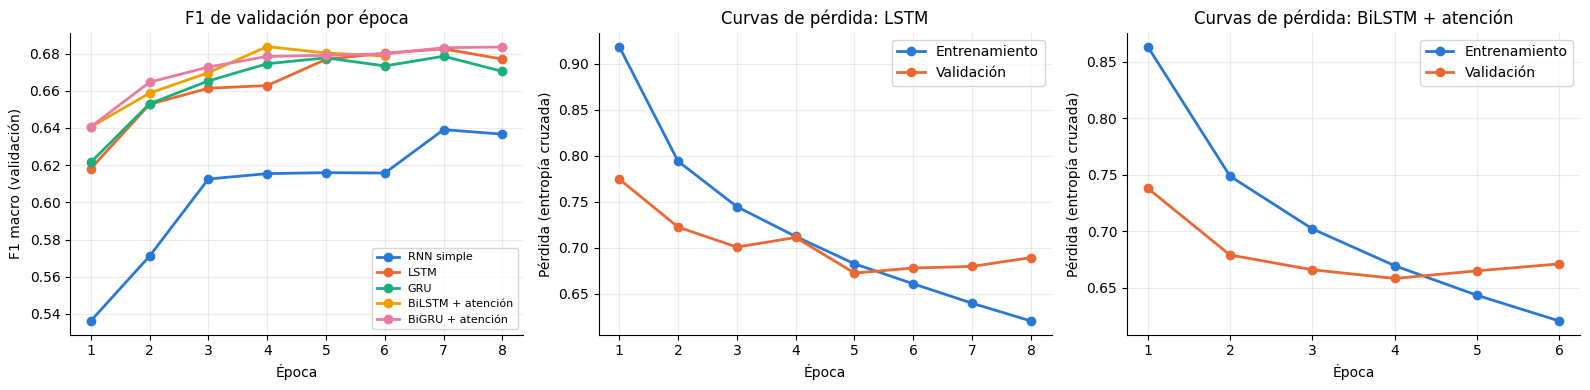

In [31]:
COLOR_MODELO = {"TF-IDF + regresión logística": "#8a8984", "RNN simple": PALETA[0], "LSTM": PALETA[1], "GRU": PALETA[2],
                "BiLSTM + atención": PALETA[3], "BiGRU + atención": PALETA[4], "BETO (fine-tuning)": PALETA[6]}

fig, ejes = plt.subplots(1, 3, figsize=(16, 4))
for nombre, hist in HISTORIALES.items():
    ejes[0].plot(hist["epoca"], hist["f1_val"], marker="o", markersize=6, linewidth=2, color=COLOR_MODELO[nombre], label=nombre)
ejes[0].set_xlabel("Época")
ejes[0].set_ylabel("F1 macro (validación)")
ejes[0].set_title("F1 de validación por época")
ejes[0].legend(fontsize=8)

for ax, nombre in zip(ejes[1:], ["LSTM", "BiLSTM + atención"]):
    hist = HISTORIALES[nombre]
    ax.plot(hist["epoca"], hist["perdida_ent"], marker="o", markersize=6, linewidth=2, color=PALETA[0], label="Entrenamiento")
    ax.plot(hist["epoca"], hist["perdida_val"], marker="o", markersize=6, linewidth=2, color=PALETA[1], label="Validación")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida (entropía cruzada)")
    ax.set_title(f"Curvas de pérdida: {nombre}")
    ax.legend()
plt.tight_layout()
plt.show()

**Análisis de las arquitecturas** (F1 macro en prueba):

| Modelo | F1 macro | Tiempo de entrenamiento |
|---|---|---|
| RNN simple | 0.659 | 67 s |
| LSTM | 0.696 | 71 s |
| GRU | 0.697 | 67 s |
| BiLSTM + atención | 0.700 | 124 s |
| BiGRU + atención | 0.701 | 168 s |

- **La RNN simple es claramente la peor:** unos 4 puntos menos que el resto. También aprende más despacio: su F1 de validación arranca en 0.54 y se estanca en 0.62 entre las épocas 3 y 6.
- **LSTM y GRU rinden prácticamente igual** (0.696 frente a 0.697). La GRU lo logra con menos parámetros recurrentes y en menos tiempo (67 s frente a 71 s), lo que coincide con la literatura.
- **La bidireccionalidad con atención aporta poco**, unos 0.4 puntos. Las reseñas son cortas (mediana de unos 22 tokens), así que leer en ambos sentidos o tener atajos hacia cada palabra no cambia mucho.
- **Sobreajuste y parada temprana.** En la LSTM, la pérdida de validación es mínima en la época 5 y luego sube, mientras la de entrenamiento sigue bajando: el modelo empieza a memorizar. La BiLSTM con atención alcanza su mínimo en la época 4 y la parada temprana la detuvo en la 6. En ambos casos se conservan los pesos de la mejor época.
- **Resultado notable: la línea base TF-IDF (0.6965) empata con la LSTM y la GRU.** En reseñas cortas con pistas léxicas fuertes, los n-gramas capturan casi toda la información. Las redes recurrentes con embeddings aprendidos desde cero, con 60,000 ejemplos, no logran extraer mucho más. Su ventaja aparece en los textos largos (sección 6.7).

### 6.5 Efecto de los embeddings preentrenados: Word2Vec, GloVe y FastText

Se toma la arquitectura **BiLSTM + atención** y se cambia solo la **inicialización de la capa de embedding**:

- **Aleatoria:** se aprende desde cero.
- **Word2Vec, GloVe o FastText:** los vectores entrenados en la sección 4. Siguen ajustándose durante el entrenamiento (*fine-tuning*).

Los embeddings preentrenados aportan conocimiento de 200,000 reseñas, pero su ventaja depende de cuántos datos etiquetados haya. Por eso el experimento se repite en dos escenarios:

- **Datos abundantes:** 60,000 reseñas etiquetadas.
- **Datos escasos:** 3,000 reseñas etiquetadas (1,000 por clase), la situación típica de un proyecto real con pocas etiquetas.

Word2Vec: cubre el 86.2% del vocabulario de clasificación
GloVe: cubre el 86.2% del vocabulario de clasificación
FastText: cubre el 100.0% del vocabulario de clasificación


Escenario          3,000 reseñas  60,000 reseñas
Embedding inicial                               
Aleatoria                 0.5858          0.7002
Word2Vec                  0.6505          0.7057
GloVe                     0.6331          0.6950
FastText                  0.6458          0.7043


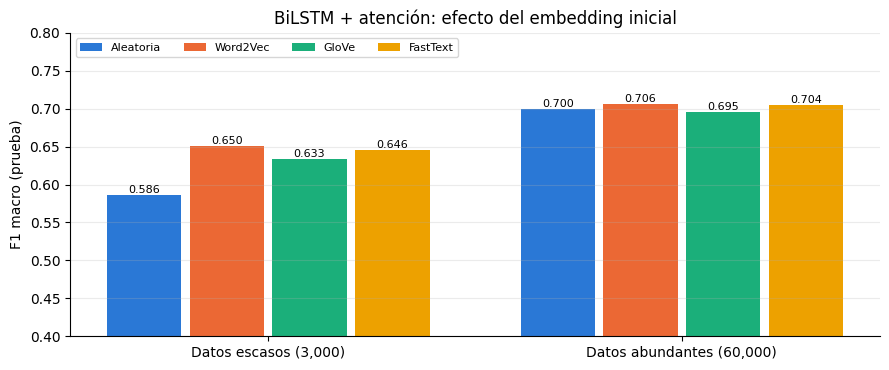

In [32]:
def matriz_embeddings(kv, cubre_todo=False):
    # Matriz inicial: vector preentrenado si existe; si no, aleatorio pequeño. <pad> queda en ceros
    rng = np.random.default_rng(SEMILLA)
    matriz = rng.normal(0, 0.1, (len(vocab), DIM_EMB)).astype(np.float32)
    matriz[0] = 0
    cubiertas = 0
    for i, palabra in enumerate(vocab[2:], start=2):
        if cubre_todo or palabra in kv.key_to_index:
            matriz[i] = kv[palabra]
            cubiertas += 1
    return matriz, cubiertas / (len(vocab) - 2)

INICIALIZACIONES = {"Aleatoria": None}
for nombre, kv, todo in [("Word2Vec", w2v, False), ("GloVe", glove, False), ("FastText", fasttext, True)]:
    INICIALIZACIONES[nombre], cobertura = matriz_embeddings(kv, todo)
    print(f"{nombre}: cubre el {cobertura:.1%} del vocabulario de clasificación")

# Escenario de datos escasos: 1,000 reseñas por clase
idx_pocos = df_ent.groupby("sentimiento").sample(1000, random_state=SEMILLA).index
cargador_pocos = crear_cargador([ids_ent[i] for i in idx_pocos], y_ent[idx_pocos], mezclar=True, tam_lote=64)

resultados_emb = []
for escenario, cargador, epocas, paciencia in [("60,000 reseñas", cargador_ent, 8, 2), ("3,000 reseñas", cargador_pocos, 25, 4)]:
    for nombre_ini, pesos in INICIALIZACIONES.items():
        if escenario == "60,000 reseñas" and nombre_ini == "Aleatoria":
            modelo = MODELOS_SENT["BiLSTM + atención"]          # Ya se entrenó en la sección 6.4
        else:
            fijar_semilla()
            modelo = ClasificadorTexto(tam_vocab=len(vocab), tipo="lstm", bidireccional=True, atencion=True, pesos_emb=pesos)
            archivo = f"emb_{nombre_ini.lower()}_{'completo' if escenario.startswith('60') else 'escaso'}"
            modelo, _, _ = entrenar_modelo(archivo, modelo, cargador, cargador_val, epocas=epocas, paciencia=paciencia, verbose=False)
        _, pred, _, _ = predecir(modelo, cargador_pru)
        resultados_emb.append({"Escenario": escenario, "Embedding inicial": nombre_ini,
                               "Exactitud": accuracy_score(y_pru, pred), "F1 macro": f1_score(y_pru, pred, average="macro")})

tabla_emb = pd.DataFrame(resultados_emb)
print(tabla_emb.pivot(index="Embedding inicial", columns="Escenario", values="F1 macro")
      .reindex(INICIALIZACIONES)[["3,000 reseñas", "60,000 reseñas"]].round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 3.8))
ancho = 0.2
for k, nombre_ini in enumerate(INICIALIZACIONES):
    valores = tabla_emb[tabla_emb["Embedding inicial"] == nombre_ini].set_index("Escenario").loc[["3,000 reseñas", "60,000 reseñas"], "F1 macro"]
    barras = ax.bar(np.arange(2) + (k - 1.5) * ancho, valores, width=ancho - 0.02, color=PALETA[k], label=nombre_ini)
    ax.bar_label(barras, fmt="%.3f", fontsize=8)
ax.set_xticks(np.arange(2), ["Datos escasos (3,000)", "Datos abundantes (60,000)"])
ax.set_ylabel("F1 macro (prueba)")
ax.set_ylim(0.4, 0.8)
ax.set_title("BiLSTM + atención: efecto del embedding inicial")
ax.legend(ncol=4, fontsize=8, loc="upper left")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**El valor de los embeddings preentrenados depende de cuántos datos etiquetados haya:**

| Embedding inicial | Datos escasos (3,000) | Mejora | Datos abundantes (60,000) |
|---|---|---|---|
| Aleatorio | 0.586 | | 0.700 |
| Word2Vec | 0.651 | +6.5 puntos | 0.706 |
| FastText | 0.646 | +6.0 puntos | 0.704 |
| GloVe | 0.633 | +4.7 puntos | 0.695 |

- **Con datos escasos, los embeddings preentrenados son decisivos.** Aportan el conocimiento de 200,000 reseñas *sin etiquetar*: la red ya sabe que "nefasto" se parece a "pésimo" aunque nunca haya visto "nefasto" en una reseña etiquetada. Es una forma de **aprendizaje por transferencia**.
- **Con datos abundantes, la ventaja desaparece:** todas las variantes quedan entre 0.695 y 0.706. Con 60,000 ejemplos, la red aprende embeddings igual de útiles por su cuenta.
- **GloVe queda ligeramente por debajo** en ambos escenarios. Es coherente con lo visto en la sección 4.3: sus vectores reflejan más qué palabras acompañan a otra que cuáles la pueden sustituir.
- **FastText cubre el 100 % del vocabulario** (Word2Vec y GloVe, el 86.2 %), pero aquí no supera a Word2Vec. El vocabulario de clasificación solo incluye palabras que aparecen al menos 2 veces, así que su ventaja con errores raros casi no se ejercita. Su beneficio se verá en el chatbot.
- La diferencia entre Word2Vec y FastText (0.005) es menor que la variación esperada entre ejecuciones con distinta semilla, así que no debe considerarse significativa.

### 6.6 La alternativa superior: Transformer preentrenado (BETO) con fine-tuning

Se ajusta **BETO**, con 110 millones de parámetros, a la clasificación de sentimientos. Se agrega una capa lineal sobre la representación del token `[CLS]` y se entrenan **todos** los pesos durante 2 épocas. Esto es **aprendizaje por transferencia**: BETO ya "sabe español" por su preentrenamiento con unos 3,000 millones de palabras y solo necesita adaptarse a la tarea.

| Aspecto | Configuración |
|---|---|
| Optimizador | AdamW, tasa de aprendizaje de $3 \times 10^{-5}$ |
| Calendario | Calentamiento lineal (6 %) y decaimiento lineal |
| Lote | 32 reseñas |
| Longitud máxima | 128 subpalabras |
| Precisión | Mixta `bfloat16`, para ahorrar memoria de la GPU |

In [33]:
RUTA_BETO = RUTA_MODELOS / "beto_sentimiento"
LONG_MAX_BETO, LOTE_BETO, EPOCAS_BETO, LR_BETO = 128, 32, 2, 3e-5

def agrupar_beto(lote):
    secuencias, etiquetas = zip(*lote)
    ids = pad_sequence([torch.tensor(s) for s in secuencias], batch_first=True, padding_value=tok_beto.pad_token_id)
    return {"input_ids": ids, "attention_mask": (ids != tok_beto.pad_token_id).long(), "labels": torch.tensor(etiquetas)}

def cargador_beto(textos, etiquetas, mezclar=False, tam_lote=LOTE_BETO):
    ids = tok_beto(list(textos), truncation=True, max_length=LONG_MAX_BETO)["input_ids"]
    return torch.utils.data.DataLoader(DatosSecuencia(ids, etiquetas), batch_size=tam_lote, shuffle=mezclar,
                                       collate_fn=agrupar_beto, generator=torch.Generator().manual_seed(SEMILLA))

@torch.no_grad()
def predecir_beto(modelo, cargador):
    modelo.eval()
    probs = []
    for lote in cargador:
        lote = {k: v.to(DISPOSITIVO) for k, v in lote.items() if k != "labels"}
        with torch.autocast("cuda", dtype=torch.bfloat16, enabled=DISPOSITIVO.type == "cuda"):
            logits = modelo(**lote).logits
        probs.append(torch.softmax(logits.float(), 1).cpu().numpy())
    probs = np.concatenate(probs)
    return probs.argmax(1), probs

cargador_val_beto = cargador_beto(df_val["text"], y_val, tam_lote=128)
cargador_pru_beto = cargador_beto(df_pru["text"], y_pru, tam_lote=128)

if (RUTA_BETO / "historial.json").exists():
    modelo_beto = AutoModelForSequenceClassification.from_pretrained(RUTA_BETO).to(DISPOSITIVO)
    info_beto = json.load(open(RUTA_BETO / "historial.json"))
    print("BETO ajustado cargado desde disco.")
else:
    fijar_semilla()
    modelo_beto = AutoModelForSequenceClassification.from_pretrained(NOMBRE_BETO, num_labels=3).to(DISPOSITIVO)
    cargador_ent_beto = cargador_beto(df_ent["text"], y_ent, mezclar=True)
    optimizador = torch.optim.AdamW(modelo_beto.parameters(), lr=LR_BETO, weight_decay=0.01)
    pasos_totales = EPOCAS_BETO * len(cargador_ent_beto)
    planificador = get_linear_schedule_with_warmup(optimizador, int(0.06 * pasos_totales), pasos_totales)
    historial_beto, mejor_f1, inicio = [], -1.0, time.time()
    for epoca in range(1, EPOCAS_BETO + 1):
        modelo_beto.train()
        suma = 0.0
        for paso, lote in enumerate(cargador_ent_beto):
            lote = {k: v.to(DISPOSITIVO) for k, v in lote.items()}
            with torch.autocast("cuda", dtype=torch.bfloat16):
                perdida = modelo_beto(**lote).loss
            optimizador.zero_grad()
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo_beto.parameters(), 1.0)
            optimizador.step()
            planificador.step()
            suma += perdida.item()
        pred_val, _ = predecir_beto(modelo_beto, cargador_val_beto)
        f1_val = f1_score(y_val, pred_val, average="macro")
        historial_beto.append({"epoca": epoca, "perdida_ent": suma / len(cargador_ent_beto), "f1_val": f1_val})
        print(f"  [BETO] época {epoca}: pérdida ent. {suma / len(cargador_ent_beto):.4f} | F1 val. {f1_val:.4f} | {time.time() - inicio:.0f} s")
        if f1_val > mejor_f1:
            mejor_f1 = f1_val
            modelo_beto.save_pretrained(RUTA_BETO)
    info_beto = {"historial": historial_beto, "tiempo_s": time.time() - inicio}
    tok_beto.save_pretrained(RUTA_BETO)
    json.dump(info_beto, open(RUTA_BETO / "historial.json", "w"))
    modelo_beto = AutoModelForSequenceClassification.from_pretrained(RUTA_BETO).to(DISPOSITIVO)   # Mejor época

print(pd.DataFrame(info_beto["historial"]).round(4).to_string(index=False))
pred_beto, probs_beto = predecir_beto(modelo_beto, cargador_pru_beto)
registrar("BETO (fine-tuning)", pred_beto, contar_parametros(modelo_beto), info_beto["tiempo_s"], probs_beto)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BETO ajustado cargado desde disco.
 epoca  perdida_ent  f1_val
     1       0.6692  0.7130
     2       0.5197  0.7195


BETO (fine-tuning): exactitud 0.7612 | F1 macro 0.7333 (prueba)


### 6.7 Resultados comparativos

                              Exactitud  F1 macro   Parámetros  Tiempo (s)
BETO (fine-tuning)               0.7612    0.7333  109,853,187         839
BiGRU + atención                 0.7362    0.7013    2,375,459         168
BiLSTM + atención                0.7374    0.7002    2,434,339         124
GRU                              0.7238    0.6971    2,220,707          67
TF-IDF + regresión logística     0.7252    0.6965      410,070          40
LSTM                             0.7282    0.6963    2,250,147          71
RNN simple                       0.6976    0.6590    2,161,827          67


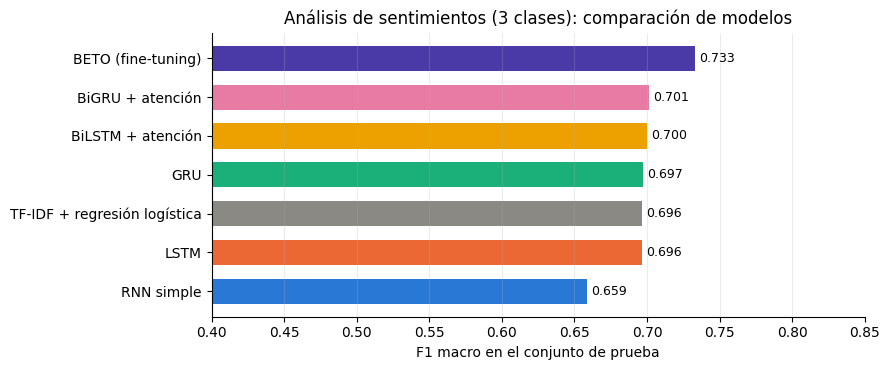

In [34]:
tabla_res = (pd.DataFrame(RESULTADOS).T.drop(columns=["pred", "probs"])
             .astype({"Exactitud": float, "F1 macro": float, "Parámetros": int, "Tiempo de entrenamiento (s)": float})
             .sort_values("F1 macro", ascending=False))
print(tabla_res.assign(**{"Parámetros": tabla_res["Parámetros"].map("{:,}".format),
                          "Tiempo de entrenamiento (s)": tabla_res["Tiempo de entrenamiento (s)"].round(0).astype(int)})
      .rename(columns={"Tiempo de entrenamiento (s)": "Tiempo (s)"}).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 3.8))
orden = tabla_res.index[::-1]
barras = ax.barh(orden, tabla_res.loc[orden, "F1 macro"], color=[COLOR_MODELO[m] for m in orden], height=0.65)
ax.bar_label(barras, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlim(0.4, 0.85)
ax.set_xlabel("F1 macro en el conjunto de prueba")
ax.set_title("Análisis de sentimientos (3 clases): comparación de modelos")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Reseñas de prueba por grupo de longitud: {'1-15': 1562, '16-30': 1885, '31-60': 1178, 'más de 60': 375}


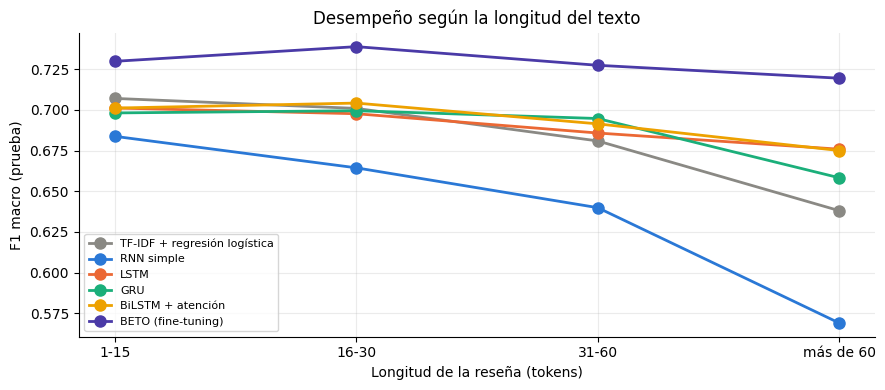

In [35]:
# Desempeño según la longitud de la reseña: ¿qué modelos sufren con textos largos?
cortes = [0, 15, 30, 60, 1000]
etiquetas_long = ["1-15", "16-30", "31-60", "más de 60"]
grupo_long = pd.cut(df_pru["tokens"].map(len), bins=cortes, labels=etiquetas_long)
print("Reseñas de prueba por grupo de longitud:", grupo_long.value_counts().reindex(etiquetas_long).to_dict())

fig, ax = plt.subplots(figsize=(9, 4))
for nombre in ["TF-IDF + regresión logística", "RNN simple", "LSTM", "GRU", "BiLSTM + atención", "BETO (fine-tuning)"]:
    pred = RESULTADOS[nombre]["pred"]
    f1_por_grupo = [f1_score(y_pru[grupo_long == g], pred[grupo_long == g], average="macro") for g in etiquetas_long]
    ax.plot(etiquetas_long, f1_por_grupo, marker="o", markersize=8, linewidth=2, color=COLOR_MODELO[nombre], label=nombre)
ax.set_xlabel("Longitud de la reseña (tokens)")
ax.set_ylabel("F1 macro (prueba)")
ax.set_title("Desempeño según la longitud del texto")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

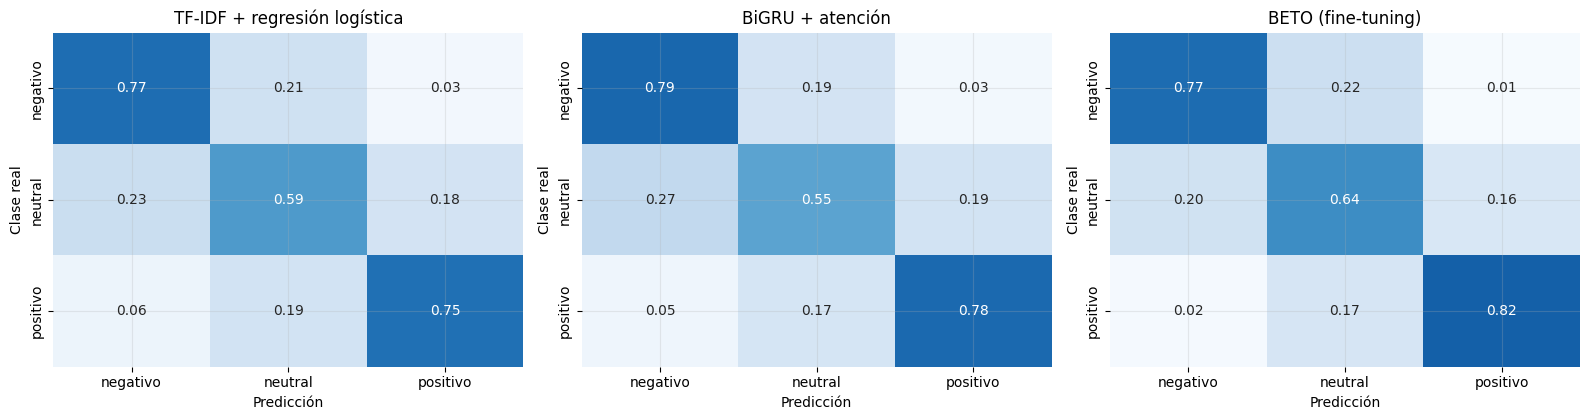

Reporte por clase de BETO:

              precision    recall  f1-score   support

    negativo     0.8690    0.7665    0.8146      2000
     neutral     0.4508    0.6420    0.5297      1000
    positivo     0.9001    0.8155    0.8557      2000

    accuracy                         0.7612      5000
   macro avg     0.7400    0.7413    0.7333      5000
weighted avg     0.7978    0.7612    0.7741      5000



In [36]:
# Matrices de confusión normalizadas por clase real
mejor_rnn = tabla_res.drop(["BETO (fine-tuning)", "TF-IDF + regresión logística"]).index[0]
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, nombre in zip(ejes, ["TF-IDF + regresión logística", mejor_rnn, "BETO (fine-tuning)"]):
    matriz = confusion_matrix(y_pru, RESULTADOS[nombre]["pred"], normalize="true")
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=CLASES, yticklabels=CLASES,
                ax=ax, cbar=False)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Clase real")
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

print(f"Reporte por clase de BETO:\n")
print(classification_report(y_pru, RESULTADOS["BETO (fine-tuning)"]["pred"], target_names=CLASES, digits=4))

**Análisis de los resultados comparativos.**

- **BETO es el mejor modelo:** F1 macro de 0.733 y exactitud del 76.1 %, **3.2 puntos por encima** de la mejor red recurrente (BiGRU con atención, 0.701). El costo es alto: 110 millones de parámetros (46 veces más) y 839 s de entrenamiento en GPU, 5 veces más que la BiGRU. Es la confirmación práctica de por qué los Transformers preentrenados reemplazaron a las RNN.
- **La longitud del texto confirma el experimento de la sección 5.3:**

  | Modelo | F1 en reseñas de 1 a 15 tokens | F1 en reseñas de más de 60 tokens |
  |---|---|---|
  | RNN simple | 0.68 | 0.57 |
  | TF-IDF | 0.71 | 0.64 |
  | LSTM / BiLSTM | 0.70 | 0.68 |
  | BETO | 0.73 | 0.72 |

  - **La RNN simple se desploma** con los textos largos: el gradiente desvaneciente, ahora con datos reales.
  - **TF-IDF también pierde mucho.** Las reseñas largas mezclan aspectos positivos y negativos, y una bolsa de palabras no sabe cuál pesa más.
  - **La LSTM y la BiLSTM son más estables**, y **BETO prácticamente no se degrada**.

  Las diferencias entre arquitecturas que el promedio global esconde aparecen en los textos largos.
- **La clase neutral es la más difícil para todos los modelos.** Su sensibilidad es de 0.55 en la BiGRU, 0.59 en TF-IDF y 0.64 en BETO, y BETO tiene una precisión de solo 0.45 en esa clase: muchas reseñas negativas (22 %) y positivas (17 %) se predicen como neutrales. En cambio, positivo y negativo casi nunca se confunden entre sí (1 % a 6 %). Los errores ocurren entre **clases adyacentes**, por dos razones:
  - una reseña de 3 estrellas suele mezclar elogios y quejas;
  - la frontera entre 2 y 3 estrellas, o entre 3 y 4, es subjetiva y varía según el autor.

### 6.8 Análisis de errores: negaciones, contrastes e ironía

Las métricas globales no dicen *en qué* falla cada modelo. Se evalúan frases diseñadas para poner a prueba la comprensión del lenguaje: negaciones, contrastes con "pero", ironía y dependencias largas.

In [37]:
FRASES_DIFICILES = [
    ("No está nada mal, la verdad me sorprendió", "positivo"),
    ("No me gustó, no lo recomiendo", "negativo"),
    ("No es malo, es excelente", "positivo"),
    ("Pensé que sería de mala calidad, pero me encantó", "positivo"),
    ("Tenía buenas reseñas pero resultó ser un desastre", "negativo"),
    ("Genial, se rompió al segundo día", "negativo"),
    ("Cumple su función, ni más ni menos", "neutral"),
    ("El diseño es bonito, aunque la batería dura poco", "neutral"),
    ("La batería, que al principio parecía durar bastante y funcionaba de maravilla, terminó fallando a las dos semanas", "negativo"),
    ("Excelente producto, llegó antes de lo esperado", "positivo"),
]
textos_dif = [f for f, _ in FRASES_DIFICILES]
cargador_dif = crear_cargador([codificar(tokenizar(t)) for t in textos_dif], [0] * len(textos_dif))

predicciones = {
    "TF-IDF": modelo_tfidf.predict(vectorizador.transform(textos_dif)),
    "LSTM": predecir(MODELOS_SENT["LSTM"], cargador_dif)[1],
    "BiLSTM+atención": predecir(MODELOS_SENT["BiLSTM + atención"], cargador_dif)[1],
    "BETO": predecir_beto(modelo_beto, cargador_beto(textos_dif, [0] * len(textos_dif)))[0],
}
CORTO = {"negativo": "neg", "neutral": "neu", "positivo": "pos"}
print("(x) = predicción incorrecta | neg = negativo, neu = neutral, pos = positivo\n")
for k, (frase, esperado) in enumerate(FRASES_DIFICILES):
    print(textwrap.fill(frase, width=84))
    resultados = " | ".join(f"{nombre} {CORTO[CLASES[pred[k]]]}" + ("" if CLASES[pred[k]] == esperado else " (x)")
                            for nombre, pred in predicciones.items())
    print(f"    esperado {CORTO[esperado]} | {resultados}\n")
print("\nAciertos:", {n: sum(CLASES[p] == e for p, (_, e) in zip(pred, FRASES_DIFICILES)) for n, pred in predicciones.items()}, f"de {len(FRASES_DIFICILES)}")

(x) = predicción incorrecta | neg = negativo, neu = neutral, pos = positivo

No está nada mal, la verdad me sorprendió
    esperado pos | TF-IDF neg (x) | LSTM neu (x) | BiLSTM+atención neu (x) | BETO pos

No me gustó, no lo recomiendo
    esperado neg | TF-IDF neg | LSTM neg | BiLSTM+atención neg | BETO neg

No es malo, es excelente
    esperado pos | TF-IDF neg (x) | LSTM neu (x) | BiLSTM+atención neu (x) | BETO pos

Pensé que sería de mala calidad, pero me encantó
    esperado pos | TF-IDF neg (x) | LSTM neu (x) | BiLSTM+atención pos | BETO pos

Tenía buenas reseñas pero resultó ser un desastre
    esperado neg | TF-IDF neg | LSTM neg | BiLSTM+atención neg | BETO neg

Genial, se rompió al segundo día
    esperado neg | TF-IDF neg | LSTM pos (x) | BiLSTM+atención pos (x) | BETO neg

Cumple su función, ni más ni menos
    esperado neu | TF-IDF neu | LSTM neu | BiLSTM+atención neu | BETO pos (x)

El diseño es bonito, aunque la batería dura poco
    esperado neu | TF-IDF neu | LSTM neu 

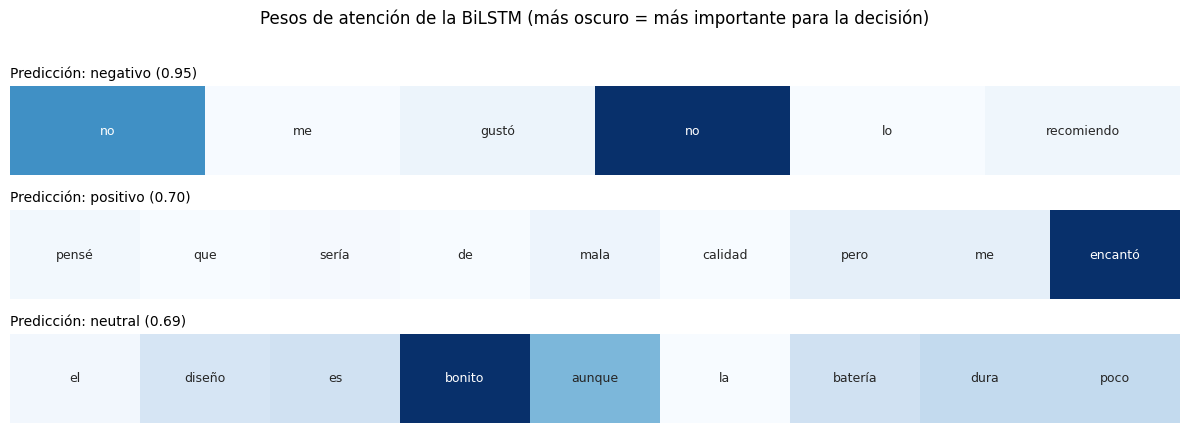

In [38]:
# ¿En qué palabras se fija la BiLSTM con atención?
modelo_att = MODELOS_SENT["BiLSTM + atención"]
frases_att = ["No me gustó, no lo recomiendo",
              "Pensé que sería de mala calidad, pero me encantó",
              "El diseño es bonito, aunque la batería dura poco"]
fig, ejes = plt.subplots(len(frases_att), 1, figsize=(12, 1.4 * len(frases_att)))
for ax, frase in zip(ejes, frases_att):
    tokens = tokenizar(frase)
    x = torch.tensor([codificar(tokens)], device=DISPOSITIVO)
    modelo_att.eval()
    with torch.no_grad():
        prob = torch.softmax(modelo_att(x, torch.tensor([len(tokens)])), 1)[0].cpu().numpy()
    pesos = modelo_att.pesos_atencion[0, :len(tokens)].cpu().numpy()
    sns.heatmap(pesos[None, :], annot=np.array([tokens]), fmt="", cmap="Blues", cbar=False, xticklabels=False,
                yticklabels=False, ax=ax, annot_kws={"fontsize": 9})
    ax.set_title(f"Predicción: {CLASES[prob.argmax()]} ({prob.max():.2f})", fontsize=10, loc="left")
plt.suptitle("Pesos de atención de la BiLSTM (más oscuro = más importante para la decisión)", y=1.02)
plt.tight_layout()
plt.show()

**Análisis de errores.** BETO acierta **9 de 10** frases difíciles, frente a 7 de TF-IDF y de la BiLSTM con atención, y 6 de la LSTM.

- **Negaciones de algo negativo.** En "No está nada mal" y "No es malo, es excelente" **solo BETO acierta**:
  - TF-IDF responde negativo, porque ve "mal", "malo" y "no";
  - las redes recurrentes responden neutral, porque detectan la tensión pero no la resuelven.

  Entender que negar algo negativo es positivo requiere composición, la fortaleza del Transformer.
- **Contraste con "pero".** En "Pensé que sería de mala calidad, pero me encantó" aciertan la BiLSTM con atención y BETO. El mapa de atención muestra que la BiLSTM concentra casi todo el peso en "**encantó**", la palabra después del "pero", e ignora "mala calidad".
- **Ironía.** "Genial, se rompió al segundo día" engaña a la LSTM y a la BiLSTM, que responden positivo por "genial". Aciertan TF-IDF, probablemente porque "rompió" es una pista negativa muy fuerte, y BETO.
- **Neutralidad.** "Cumple su función, ni más ni menos" es el único error de BETO, que responde positivo. La neutralidad sigue siendo difícil incluso para el mejor modelo.
- **La atención es interpretable:**
  - en "No me gustó, no lo recomiendo", los pesos más altos van a **las dos negaciones**;
  - en "El diseño es bonito, aunque la batería dura poco", van a "**bonito**" y al conector "**aunque**", y el modelo predice neutral. Detecta el contraste entre un elogio y una queja.

## 7. Diseño del chatbot

### 7.1 Requisitos

El chatbot debe:

1. **Responder preguntas sobre aprendizaje profundo y PLN** con información correcta.
2. **Entender paráfrasis**, lenguaje informal y errores de ortografía: cada usuario formula la misma duda de forma distinta.
3. **Reconocer lo que no sabe:** preguntas fuera del dominio o ambiguas no deben recibir una respuesta inventada.
4. **Adaptar el tono** al estado emocional del usuario, porque quien estudia un tema difícil a menudo escribe frustrado.
5. **Ser explicable y ligero**, para ejecutarse en una computadora personal.

### 7.2 Enfoque elegido: chatbot de recuperación con comprensión neuronal

Existen dos grandes familias de chatbots:

- **Generativos:** un modelo seq2seq o un modelo de lenguaje grande redacta la respuesta palabra por palabra. Son flexibles, pero con pocos datos generan texto incoherente y, aun con modelos grandes, pueden **inventar información** (alucinaciones), algo inaceptable en un tutor.
- **De recuperación:** el modelo **entiende** la pregunta y **elige** una respuesta de una base de conocimiento redactada y verificada. Toda la inteligencia está en la comprensión del lenguaje, que es donde se aplica el aprendizaje profundo.

Se elige un **chatbot de recuperación híbrido**. La base de conocimiento (`datos/base_conocimiento.json`) contiene **44 intenciones**, cada una con:

- 7 a 12 **patrones** (formas de preguntar lo mismo);
- una **respuesta** explicativa;
- una lista de **temas relacionados**.

Abarcan 39 temas técnicos, 4 intenciones sociales (saludo, despedida, agradecimiento y capacidades) y una intención de **fuera de dominio**.

### 7.3 Arquitectura

```
                         mensaje del usuario
                                 |
                   normalización y tokenización
                                 |
        +------------------------+------------------------+
        |                        |                        |
 (A) Clasificador de      (B) Buscador semántico     (C) Analizador de
     intención                Sentence-BERT               sentimiento
     BiGRU + atención         similitud coseno con        BETO ajustado
     sobre vectores           los 375 patrones           (sección 6)
     FastText                 de la base
        |                        |                        |
  P_gru(intención)         P_sem(intención)         negativo / neutral /
        |                        |                  positivo
        +-----------+------------+                        |
                    |                                     |
     P = a * P_gru + (1 - a) * P_sem                      |
                    |                                     |
              Gestor de respuesta  <----------------------+
     - si el mensaje es casi igual a un patrón (similitud >= 0.95) -> P = P_sem
     - si la intención es "fuera de dominio" -> aviso de alcance
     - si max P < umbral -> pedir aclaración y sugerir los 2 temas más probables
     - si no -> respuesta de la base + temas relacionados
     - si el sentimiento es negativo -> prefijo empático
                    |
               respuesta
```

### 7.4 Justificación de cada módulo

| Módulo | Técnica | Por qué |
|---|---|---|
| (A) Intención | BiGRU + atención sobre **FastText** | La **GRU** tiene menos parámetros que la LSTM, lo que conviene con solo 300 frases de entrenamiento. Las frases son cortas, así que la ventaja de memoria de la LSTM no se aprovecha. La **bidireccionalidad y la atención** permiten fijarse en la palabra clave ("GRU", "sobreajuste") esté donde esté. Los vectores **FastText** congelados dan representación a palabras no vistas y mal escritas (sección 4.4) y transfieren conocimiento de 5.6 millones de tokens. |
| (B) Semántica | **Sentence-BERT** multilingüe | Reconoce paráfrasis sin palabras en común (sección 4.5). No necesita entrenamiento: agregar un patrón a la base mejora el chatbot de inmediato. |
| Combinación | Promedio ponderado de probabilidades | Los dos módulos cometen errores distintos: (A) aprende la tarea específica y (B) aporta comprensión general. El peso $a$ se elige con el conjunto de validación. |
| (C) Sentimiento | **BETO** con fine-tuning | Es el mejor modelo de la sección 6, sobre todo con negaciones ("no entiendo nada"). |
| Umbral de confianza | Probabilidad máxima menor que el umbral | Evita responder con seguridad algo que no se entendió: el chatbot pide una aclaración. |

## 8. Implementación del chatbot

### 8.1 Base de conocimiento y división de los datos

Los patrones de la base se dividen en 80 % para entrenamiento y 20 % para validación, estratificando por intención. La validación sirve para la parada temprana y para elegir el peso de la combinación.

Por separado, `datos/prueba_chatbot.json` contiene **134 frases de prueba** escritas aparte de los patrones: paráfrasis, lenguaje informal y errores de ortografía. Solo se usan en la evaluación final (sección 9).

In [39]:
INTENCIONES = BASE["intenciones"]
TAGS = [it["tag"] for it in INTENCIONES]
INDICE_TAG = {t: i for i, t in enumerate(TAGS)}
POR_TAG = {it["tag"]: it for it in INTENCIONES}
K = len(TAGS)

patrones = [p for it in INTENCIONES for p in it["patrones"]]
y_patrones = np.array([INDICE_TAG[it["tag"]] for it in INTENCIONES for _ in it["patrones"]])
pat_ent, pat_val, yi_ent, yi_val = train_test_split(patrones, y_patrones, test_size=0.2, stratify=y_patrones, random_state=SEMILLA)

with open(RUTA_DATOS / "prueba_chatbot.json", encoding="utf-8") as f:
    PRUEBA = json.load(f)["ejemplos"]
textos_prueba = [e["texto"] for e in PRUEBA]
y_prueba_chat = np.array([INDICE_TAG[e["tag"]] for e in PRUEBA])

print(f"Intenciones: {K} | patrones: {len(patrones)} (entrenamiento {len(pat_ent)}, validación {len(pat_val)}) | "
      f"frases de prueba: {len(PRUEBA)}")
print(pd.DataFrame([(it["tag"], len(it["patrones"]), it["patrones"][0]) for it in INTENCIONES[:8]],
                   columns=["Intención", "Patrones", "Ejemplo"]).to_string(index=False))
print("...")

Intenciones: 44 | patrones: 375 (entrenamiento 300, validación 75) | frases de prueba: 134
           Intención  Patrones                             Ejemplo
              saludo        10                                hola
           despedida        10                               adiós
      agradecimiento        10                             gracias
         capacidades        10                  ¿qué puedes hacer?
           que_es_ia         9 ¿qué es la inteligencia artificial?
que_es_deep_learning         9    ¿qué es el aprendizaje profundo?
  neurona_artificial        10     ¿qué es una neurona artificial?
funciones_activacion         9  ¿qué es una función de activación?
...


### 8.2 Módulo A: clasificador de intención (BiGRU + atención)

Se entrenan dos variantes de **la misma arquitectura** (BiGRU de 64 unidades por dirección, con atención) que difieren solo en cómo representan las palabras:

1. **Embedding aleatorio por índices.** Se aprende desde cero con el vocabulario de los patrones. Cualquier palabra que no aparezca en ellos se convierte en `<unk>`.
2. **Vectores FastText congelados.** Cada palabra, incluso una nunca vista o mal escrita, se representa con su vector FastText de la sección 4.4.

In [40]:
# Variante 1: vocabulario propio de los patrones de entrenamiento
vocab_chat = ["<pad>", "<unk>"] + sorted({t for p in pat_ent for t in tokenizar(p)})
indice_chat = {w: i for i, w in enumerate(vocab_chat)}

def a_indices(texto):
    return [indice_chat.get(t, 1) for t in tokenizar(texto)] or [1]

# Variante 2: vectores FastText (100 dimensiones) de cada token
def a_vectores(texto):
    tokens = tokenizar(texto) or ["?"]
    return np.stack([fasttext[t] for t in tokens]).astype(np.float32)

CONFIG_INTENCION = dict(tipo="gru", dim_oculta=64, bidireccional=True, atencion=True, num_clases=K, dropout=0.3)
ENTRENAMIENTO_INT = dict(epocas=150, lr=3e-3, paciencia=20, decaimiento=1e-4, verbose=False)

variantes = {
    "BiGRU + embedding aleatorio": (a_indices, dict(tam_vocab=len(vocab_chat))),
    "BiGRU + FastText": (a_vectores, dict(tam_vocab=None)),
}
CLASIFICADORES = {}
for nombre, (convertir, extra) in variantes.items():
    fijar_semilla()
    modelo = ClasificadorTexto(**CONFIG_INTENCION, **extra)
    c_ent = crear_cargador([convertir(p) for p in pat_ent], yi_ent, mezclar=True, tam_lote=16)
    c_val = crear_cargador([convertir(p) for p in pat_val], yi_val, tam_lote=64)
    modelo, historial, tiempo = entrenar_modelo(nombre_archivo("intencion " + nombre), modelo, c_ent, c_val, **ENTRENAMIENTO_INT)
    CLASIFICADORES[nombre] = (modelo, convertir)
    mejor = historial.loc[historial["f1_val"].idxmax()]
    print(f"{nombre}: {contar_parametros(modelo):,} parámetros entrenables\n"
          f"    mejor época {int(mejor['epoca'])} | exactitud de validación {mejor['exactitud_val']:.3f}")

@torch.no_grad()
def probabilidades_intencion(nombre, textos):
    modelo, convertir = CLASIFICADORES[nombre]
    _, _, probs, _ = predecir(modelo, crear_cargador([convertir(t) for t in textos], [0] * len(textos), tam_lote=256))
    return probs

BiGRU + embedding aleatorio: 132,760 parámetros entrenables
    mejor época 21 | exactitud de validación 0.387
BiGRU + FastText: 86,060 parámetros entrenables
    mejor época 50 | exactitud de validación 0.507


La variante con **FastText** logra una exactitud de validación del **50.7 %**, frente al **38.7 %** con embedding aleatorio, y lo hace con menos parámetros entrenables (86,060 frente a 132,760), porque los vectores FastText están congelados. Es la ventaja de la transferencia: la red no tiene que aprender qué significa cada palabra a partir de solo 300 frases.

Aun así, la exactitud es baja. **300 frases para 44 intenciones** (unas 7 por intención) son muy pocas para entrenar una red recurrente; por eso el clasificador no se usa solo, sino combinado con la búsqueda semántica.

### 8.3 Módulo B: buscador semántico (Sentence-BERT)

Todos los patrones se codifican **una sola vez** como vectores normalizados de 384 dimensiones. Para una pregunta nueva, se calcula su similitud coseno con cada patrón y se toma la **máxima similitud por intención**. Esas similitudes $s_k$ se convierten en probabilidades con un softmax con temperatura $\tau = 0.05$:

$$P_{sem}(k) = \frac{\exp(s_k / \tau)}{\sum_j \exp(s_j / \tau)}$$

Una temperatura baja amplifica las diferencias. Las similitudes coseno varían poco (entre 0.3 y 0.9), así que sin temperatura la distribución sería casi uniforme.

In [41]:
TAU = 0.05

def similitudes_por_intencion(textos, emb_indice, y_indice):
    consultas = sbert.encode(list(textos), normalize_embeddings=True, batch_size=64)
    sims = consultas @ emb_indice.T                     # Similitud coseno (los vectores ya están normalizados)
    return np.stack([sims[:, y_indice == k].max(axis=1) for k in range(K)], axis=1)

def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

emb_pat_ent = sbert.encode(pat_ent, normalize_embeddings=True)        # Índice solo con patrones de entrenamiento (para validar)
emb_patrones = sbert.encode(patrones, normalize_embeddings=True)      # Índice final con todos los patrones
print(f"Índice semántico: {emb_patrones.shape[0]} patrones x {emb_patrones.shape[1]} dimensiones")

ejemplo = "no entiendo cómo hace la lstm para recordar cosas"
sims = similitudes_por_intencion([ejemplo], emb_patrones, y_patrones)[0]
top = np.argsort(sims)[::-1][:3]
print(f"\nConsulta: '{ejemplo}'")
for k in top:
    print(f"  {TAGS[k]:<22} similitud máxima = {sims[k]:.3f}")

Índice semántico: 375 patrones x 384 dimensiones

Consulta: 'no entiendo cómo hace la lstm para recordar cosas'
  lstm                   similitud máxima = 0.625
  atencion               similitud máxima = 0.470
  gradiente_desvaneciente similitud máxima = 0.455


### 8.4 Combinación híbrida y elección del peso $a$

El peso $a$ de la combinación $P = a \cdot P_{gru} + (1 - a) \cdot P_{sem}$ se elige con los **patrones de validación**. Para no hacer trampa, en este paso el índice semántico contiene solo los patrones de entrenamiento: si incluyera los de validación, la búsqueda los encontraría con similitud 1.

In [42]:
CLASIFICADOR_FINAL = "BiGRU + FastText"
p_gru_val = probabilidades_intencion(CLASIFICADOR_FINAL, pat_val)
p_sem_val = softmax_np(similitudes_por_intencion(pat_val, emb_pat_ent, yi_ent) / TAU)

alfas = np.round(np.linspace(0, 1, 11), 1)
exactitud_alfa = [accuracy_score(yi_val, (a * p_gru_val + (1 - a) * p_sem_val).argmax(1)) for a in alfas]
mejor_exactitud = max(exactitud_alfa)
ALFA = min((a for a, e in zip(alfas, exactitud_alfa) if e == mejor_exactitud), key=lambda a: abs(a - 0.5))  # Empate: el más equilibrado
print(pd.DataFrame({"a": alfas, "Exactitud de validación": np.round(exactitud_alfa, 3)}).to_string(index=False))
print(f"\nPeso elegido: a = {ALFA}")

  a  Exactitud de validación
0.0                    0.587
0.1                    0.600
0.2                    0.613
0.3                    0.613
0.4                    0.627
0.5                    0.640
0.6                    0.613
0.7                    0.573
0.8                    0.533
0.9                    0.520
1.0                    0.507

Peso elegido: a = 0.5


**La combinación supera a cada módulo por separado:**

- solo búsqueda semántica ($a = 0$): **58.7 %**;
- solo BiGRU ($a = 1$): **50.7 %**;
- combinación con $a = 0.5$: **64.0 %**.

Los dos módulos cometen errores distintos y se complementan:

- el BiGRU aprendió las palabras clave de cada intención con las frases de entrenamiento;
- Sentence-BERT aporta la comprensión general de paráfrasis.

Estos valores son menores que los de la evaluación final, porque aquí el índice semántico no contiene los patrones de validación.

### 8.5 Módulo C y gestor de respuesta: la clase `Chatbot`

El gestor integra los tres módulos con estas reglas:

- **Coincidencia casi exacta:** si el mensaje tiene una similitud coseno de al menos **0.95** con algún patrón de la base, es prácticamente la misma pregunta, así que se usa solo la búsqueda semántica. Esta regla se agregó después de observar, en la primera versión, que el clasificador BiGRU contradecía con mucha seguridad coincidencias literales: "¿Qué es una red neuronal recurrente?" se respondía con la explicación de las redes bidireccionales.
- **Fuera de dominio:** si la intención ganadora es "fuera de dominio", el chatbot explica su alcance.
- **Baja confianza:** si la probabilidad máxima es menor que el umbral de **0.30**, en lugar de arriesgar una respuesta pide aclaración y ofrece los dos temas más probables. Con 44 intenciones, la probabilidad uniforme es 0.02; exigir 0.30 significa que debe haber un ganador claro.
- **Respuesta normal:** la respuesta de la base, más los temas relacionados para guiar el aprendizaje.
- **Ajuste de tono:** si BETO detecta un mensaje **negativo** con probabilidad de al menos **0.75**, antepone una frase empática. En la primera versión el umbral era 0.60 y producía falsos positivos con frases técnicas que contienen palabras negativas: "¿fasttext sirve con palabras **mal** escritas?" recibía la frase empática. Si detecta entusiasmo (positivo con al menos 0.8) en una pregunta técnica, lo reconoce. No se aplica a despedidas ni agradecimientos.

In [43]:
import textwrap

NOMBRE_TEMA = {
    "que_es_ia": "inteligencia artificial", "que_es_deep_learning": "aprendizaje profundo", "neurona_artificial": "neuronas y perceptrón",
    "funciones_activacion": "funciones de activación", "retropropagacion": "retropropagación", "descenso_gradiente": "descenso de gradiente",
    "funcion_perdida": "funciones de pérdida", "optimizadores": "optimizadores", "tasa_aprendizaje": "tasa de aprendizaje",
    "epocas_lotes": "épocas y lotes", "division_datos": "división de datos", "sobreajuste": "sobreajuste", "dropout": "dropout y normalización",
    "gradiente_desvaneciente": "gradiente desvaneciente", "cnn": "redes convolucionales", "transfer_learning": "aprendizaje por transferencia",
    "rnn": "redes recurrentes", "lstm": "LSTM", "gru": "GRU", "lstm_vs_gru": "LSTM vs GRU", "bidireccional": "redes bidireccionales",
    "seq2seq": "seq2seq", "atencion": "mecanismo de atención", "transformer": "Transformers", "bert": "BERT", "llm": "modelos de lenguaje grandes",
    "que_es_pln": "PLN", "tokenizacion": "tokenización", "preprocesamiento_texto": "preprocesamiento de texto", "bolsa_palabras": "bolsa de palabras y TF-IDF",
    "embeddings": "embeddings", "word2vec": "Word2Vec", "glove": "GloVe", "fasttext": "FastText", "embeddings_contextuales": "embeddings contextuales",
    "analisis_sentimientos": "análisis de sentimientos", "metricas": "métricas", "autoencoder_gan": "autoencoders y GAN", "chatbot": "cómo funciono",
    "saludo": "saludo", "despedida": "despedida", "agradecimiento": "agradecimiento", "capacidades": "mis capacidades", "fuera_de_dominio": "fuera de dominio",
}
SOCIALES = {"saludo", "despedida", "agradecimiento", "capacidades", "fuera_de_dominio"}
UMBRAL_EXACTO = 0.95   # Similitud coseno a partir de la cual el mensaje es prácticamente igual a un patrón de la base

def combinar(p_gru, sims, alfa=ALFA, tau=TAU, umbral_exacto=UMBRAL_EXACTO):
    # Promedio ponderado de ambos módulos; si el mensaje coincide casi literalmente con un patrón,
    # se usa solo la búsqueda semántica (no tiene sentido que el clasificador la contradiga)
    p_sem = softmax_np(sims / tau)
    p = alfa * p_gru + (1 - alfa) * p_sem
    exactos = sims.max(axis=1) >= umbral_exacto
    p[exactos] = p_sem[exactos]
    return p


class Chatbot:
    def __init__(self, alfa=ALFA, tau=TAU, umbral=0.30, umbral_exacto=UMBRAL_EXACTO, umbral_negativo=0.75, umbral_positivo=0.80):
        self.alfa, self.tau, self.umbral, self.umbral_exacto = alfa, tau, umbral, umbral_exacto
        self.umbral_negativo, self.umbral_positivo = umbral_negativo, umbral_positivo

    def entender(self, textos):
        # Módulos A, B y C sobre una lista de mensajes
        p_gru = probabilidades_intencion(CLASIFICADOR_FINAL, textos)
        sims = similitudes_por_intencion(textos, emb_patrones, y_patrones)
        p = combinar(p_gru, sims, self.alfa, self.tau, self.umbral_exacto)
        _, p_sent = predecir_beto(modelo_beto, cargador_beto(textos, [0] * len(textos)))
        return p, p_sent

    def componer(self, texto, p, p_sent):
        # Gestor de respuesta: decide qué contestar y con qué tono
        orden = np.argsort(p)[::-1]
        tag, confianza = TAGS[orden[0]], float(p[orden[0]])
        sentimiento = CLASES[int(p_sent.argmax())]
        if tag == "fuera_de_dominio":
            respuesta = POR_TAG[tag]["respuesta"]
        elif confianza < self.umbral:
            opciones = [NOMBRE_TEMA[TAGS[k]] for k in orden[:3] if TAGS[k] not in SOCIALES][:2]
            respuesta = ("No estoy seguro de haber entendido tu pregunta. ¿Te refieres a "
                         + " o a ".join(opciones) + "? Intenta reformularla con más detalle.")
            tag = "(aclaración)"
        else:
            respuesta = POR_TAG[tag]["respuesta"]
            relacionados = [NOMBRE_TEMA[r] for r in POR_TAG[tag]["relacionados"] if r in NOMBRE_TEMA]
            if relacionados and tag not in SOCIALES:
                respuesta += "\n\nTemas relacionados que te pueden interesar: " + ", ".join(relacionados) + "."
        if tag not in {"despedida", "agradecimiento", "fuera_de_dominio"}:
            if sentimiento == "negativo" and p_sent[0] >= self.umbral_negativo:
                respuesta = "Entiendo que puede resultar frustrante; es un tema que cuesta al principio. Vamos por partes.\n\n" + respuesta
            elif sentimiento == "positivo" and p_sent[2] >= self.umbral_positivo and tag not in SOCIALES:
                respuesta = "¡Qué bien que te entusiasme el tema! " + respuesta
        return {"respuesta": respuesta, "intencion": tag, "confianza": confianza,
                "sentimiento": sentimiento, "prob_sentimiento": float(p_sent.max())}

    def responder(self, texto):
        p, p_sent = self.entender([texto])
        return self.componer(texto, p[0], p_sent[0])

    def conversar(self, mensajes, ancho=86):
        p, p_sent = self.entender(mensajes)
        for texto, pi, si in zip(mensajes, p, p_sent):
            r = self.componer(texto, pi, si)
            print(f"Usuario : {texto}")
            for k, parrafo in enumerate(r["respuesta"].split("\n\n")):
                print(textwrap.fill(parrafo, width=ancho, initial_indent="Chatbot : " if k == 0 else "          ",
                                    subsequent_indent="          "))
            print(f"          [intención: {r['intencion']} | confianza: {r['confianza']:.2f} | "
                  f"sentimiento: {r['sentimiento']} ({r['prob_sentimiento']:.2f})]\n")


chatbot = Chatbot()
chatbot.conversar(["¿qué es una GRU?"])

Usuario : ¿qué es una GRU?
Chatbot : La GRU (Cho et al., 2014) simplifica la LSTM: fusiona el estado de celda con
          el estado oculto y usa solo dos compuertas. La compuerta de actualización
          decide cuánto del estado anterior conservar y cuánto reemplazar con la
          información nueva, y la de reinicio decide cuánto del pasado usar al
          calcular el candidato. Tiene menos parámetros que la LSTM y suele rendir de
          forma similar.
          Temas relacionados que te pueden interesar: LSTM, LSTM vs GRU.
          [intención: gru | confianza: 1.00 | sentimiento: negativo (0.45)]



## 9. Evaluación del chatbot

### 9.1 Exactitud de comprensión en las frases de prueba

Se comparan cuatro formas de identificar la intención sobre las 134 frases de prueba, que no se usaron en ningún momento del desarrollo:

1. BiGRU con embedding aleatorio.
2. BiGRU sobre FastText.
3. Búsqueda semántica sola.
4. Combinación híbrida.

Para medir la robustez, se evalúa también una **versión con ruido** de las mismas frases, que simula a un usuario que escribe rápido: sin acentos y con una letra borrada en una palabra de más de 4 letras.

Ejemplos con ruido:
  ¿qué son las capas ocultas de una red neuronal?
    -> ¿que son las caas ocultas de una red neuronal?
  ¿para qué se usa relu?
    -> ¿paa que se usa relu?
  ¿por qué no puedo usar solo funciones lineales en la red?
    -> ¿por que no puedo usar solo funciones linales en la red?
  ¿cuándo uso softmax y cuándo sigmoide?
    -> ¿cuano uso softmax y cuando sigmoide?
  ¿cómo se propaga el error hacia atrás?
    -> ¿como se propaga el errr hacia atras?


                                        Exactitud  F1 macro  Con ruido  Caída
BiGRU + embedding aleatorio                 0.440     0.454      0.291 -0.149
BiGRU + FastText                            0.604     0.576      0.500 -0.104
Búsqueda semántica (SBERT)                  0.761     0.741      0.627 -0.134
Híbrido (a = 0.5)                           0.791     0.775      0.694 -0.097
Chatbot final (híbrido + coincidencia)      0.799     0.783      0.694 -0.104


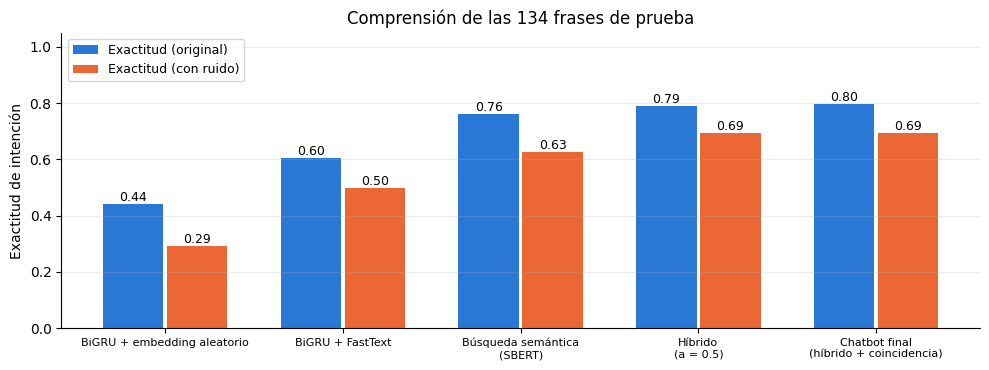

In [44]:
import unicodedata

def quitar_acentos(texto):
    return "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn" or c == "̃")

def con_ruido(texto, rng):
    texto = unicodedata.normalize("NFC", quitar_acentos(texto))
    palabras = texto.split()
    largas = [i for i, w in enumerate(palabras) if len(w) > 4]
    if largas:
        i = rng.choice(largas)
        j = rng.integers(1, len(palabras[i]) - 1)
        palabras[i] = palabras[i][:j] + palabras[i][j + 1:]
    return " ".join(palabras)

rng = np.random.default_rng(SEMILLA)
textos_ruido = [con_ruido(t, rng) for t in textos_prueba]
print("Ejemplos con ruido:")
for original, ruidoso in list(zip(textos_prueba, textos_ruido))[20:25]:
    print(f"  {original}\n    -> {ruidoso}")

def evaluar_metodos(textos):
    p_ale = probabilidades_intencion("BiGRU + embedding aleatorio", textos)
    p_ft = probabilidades_intencion("BiGRU + FastText", textos)
    sims = similitudes_por_intencion(textos, emb_patrones, y_patrones)
    p_sem = softmax_np(sims / TAU)
    return {"BiGRU + embedding aleatorio": p_ale, "BiGRU + FastText": p_ft, "Búsqueda semántica (SBERT)": p_sem,
            f"Híbrido (a = {ALFA})": ALFA * p_ft + (1 - ALFA) * p_sem, NOMBRE_FINAL: combinar(p_ft, sims)}

NOMBRE_FINAL = "Chatbot final (híbrido + coincidencia)"

probs_limpio, probs_ruido = evaluar_metodos(textos_prueba), evaluar_metodos(textos_ruido)
tabla_chat = pd.DataFrame({
    "Exactitud (original)": {m: accuracy_score(y_prueba_chat, p.argmax(1)) for m, p in probs_limpio.items()},
    "F1 macro (original)": {m: f1_score(y_prueba_chat, p.argmax(1), average="macro") for m, p in probs_limpio.items()},
    "Exactitud (con ruido)": {m: accuracy_score(y_prueba_chat, p.argmax(1)) for m, p in probs_ruido.items()},
})
tabla_chat["Caída por ruido"] = tabla_chat["Exactitud (con ruido)"] - tabla_chat["Exactitud (original)"]
print()
print(tabla_chat.rename(columns={"Exactitud (original)": "Exactitud", "F1 macro (original)": "F1 macro",
                                 "Exactitud (con ruido)": "Con ruido", "Caída por ruido": "Caída"}).round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(tabla_chat))
for k, (columna, desplazamiento) in enumerate([("Exactitud (original)", -0.18), ("Exactitud (con ruido)", 0.18)]):
    barras = ax.bar(x + desplazamiento, tabla_chat[columna], width=0.34, color=PALETA[k], label=columna)
    ax.bar_label(barras, fmt="%.2f", fontsize=9)
ax.set_xticks(x, [n.replace(" (", "\n(") for n in tabla_chat.index], fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Exactitud de intención")
ax.set_title("Comprensión de las 134 frases de prueba")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [45]:
# Errores del chatbot final
p_hib = probs_limpio[NOMBRE_FINAL]
pred_hib = p_hib.argmax(1)
errores = [(textos_prueba[i], TAGS[y_prueba_chat[i]], TAGS[pred_hib[i]], p_hib[i].max()) for i in np.where(pred_hib != y_prueba_chat)[0]]
print(f"Errores del chatbot final: {len(errores)} de {len(textos_prueba)}\n")
for frase, real, prediccion, conf in errores:
    print(f"{frase}\n    real: {real} | predicción: {prediccion} (confianza {conf:.2f})")

Errores del chatbot final: 27 de 134

qué onda, ¿me ayudas?
    real: saludo | predicción: capacidades (confianza 0.84)
¿para qué sirve el momento en la optimización?
    real: optimizadores | predicción: descenso_gradiente (confianza 0.43)
¿cuántas epocas son suficientes?
    real: epocas_lotes | predicción: capacidades (confianza 0.48)
¿qué es una iteración en el entrenamiento?
    real: epocas_lotes | predicción: division_datos (confianza 0.81)
mi red memoriza los datos y falla con datos nuevos
    real: sobreajuste | predicción: division_datos (confianza 0.45)
¿para qué apagar neuronas al azar?
    real: dropout | predicción: neurona_artificial (confianza 0.56)
¿por qué se hace chiquito el gradiente en redes profundas?
    real: gradiente_desvaneciente | predicción: descenso_gradiente (confianza 0.41)
comparación entre redes recurrentes
    real: lstm_vs_gru | predicción: rnn (confianza 0.84)
¿qué ventaja tiene leer la oración en ambos sentidos?
    real: bidireccional | predicción

**Análisis de la comprensión.**

| Método | Exactitud | Exactitud con ruido |
|---|---|---|
| BiGRU con embedding aleatorio | 44.0 % | 29.1 % |
| BiGRU sobre FastText | 60.4 % | 50.0 % |
| Búsqueda semántica (SBERT) | 76.1 % | 62.7 % |
| Híbrido ($a = 0.5$) | 79.1 % | 69.4 % |
| **Chatbot final (híbrido + coincidencia)** | **79.9 %** | **69.4 %** |

- **El chatbot final entiende correctamente el 79.9 % de las 134 frases** que nunca vio (F1 macro de 0.783).
- **FastText frente a embedding aleatorio:** con la misma arquitectura, FastText aporta **16.4 puntos** y es más robusto al ruido (pierde 10.4 puntos frente a 14.9). Su capacidad de representar palabras mal escritas se nota exactamente donde se esperaba.
- **Coincidencia casi exacta:** sobre las frases de prueba, que son paráfrasis, aporta poco (+0.8 puntos, es decir, una frase). Su valor está en evitar errores evidentes con preguntas literales, como el de la demostración (sección 9.4).
- **Con ruido** (sin acentos y con una letra borrada), todos los métodos pierden entre 10 y 15 puntos, y el chatbot final conserva un 69.4 % de exactitud.

**Los 27 errores siguen tres patrones:**

1. **Intenciones vecinas confundidas por una palabra clave.** "Comparación entre redes recurrentes" se clasifica como `rnn` en lugar de `lstm_vs_gru`, y "¿cómo funciona una LSTM en las dos direcciones?" como `lstm` en lugar de `bidireccional`. "¿Qué supera a word2vec y glove?" se clasifica como `glove`. La palabra más específica de la frase arrastra la decisión.
2. **Paráfrasis que requieren conocimiento del dominio:**
   - "¿Para qué apagar neuronas al azar?" (dropout);
   - "¿Por qué se hace chiquito el gradiente?" (gradiente desvaneciente);
   - "Mi red memoriza los datos y falla con datos nuevos" (sobreajuste).

   Es exactamente la limitación de Sentence-BERT observada en la sección 4.5: no sabe que memorizar los datos es sobreajustar.
3. **Frases sociales o fuera de dominio ambiguas.** "Qué onda, ¿me ayudas?" se clasifica como `capacidades`, una respuesta razonable. "Recomiéndame un restaurante de mariscos" se clasifica como `agradecimiento`.

### 9.2 Confianza, umbral y detección de lo que el chatbot no sabe

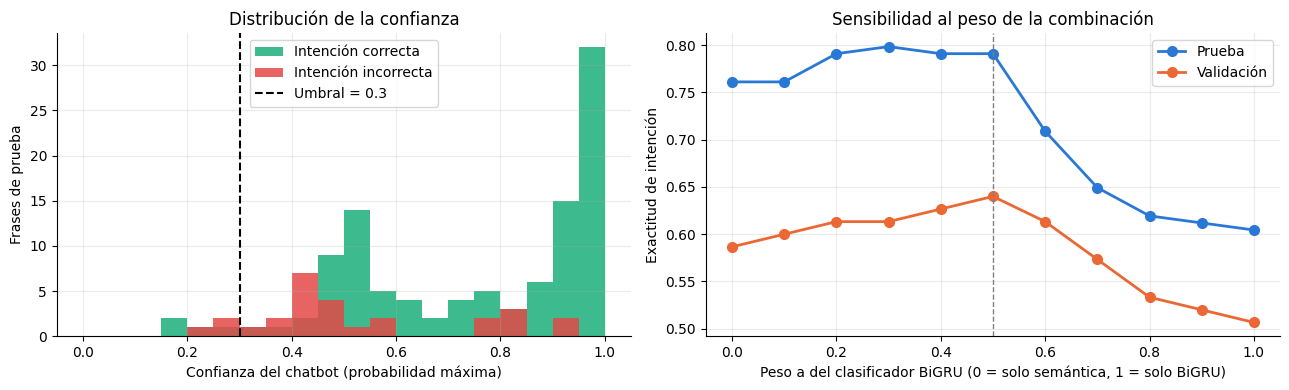

Con umbral 0.3:
  responde directamente el 95% de las frases, con exactitud de 81.1%
  pide aclaración en el 5%; de esos casos, el 43% habrían sido errores
Preguntas fuera de dominio detectadas correctamente: 4 de 5


In [46]:
confianza = p_hib.max(1)
correcto = pred_hib == y_prueba_chat
UMBRAL = chatbot.umbral

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, 1, 21)
ejes[0].hist(confianza[correcto], bins=bins, color=PALETA[2], alpha=0.85, label="Intención correcta")
ejes[0].hist(confianza[~correcto], bins=bins, color=PALETA[7], alpha=0.85, label="Intención incorrecta")
ejes[0].axvline(UMBRAL, color="black", linestyle="--", linewidth=1.5, label=f"Umbral = {UMBRAL}")
ejes[0].set_xlabel("Confianza del chatbot (probabilidad máxima)")
ejes[0].set_ylabel("Frases de prueba")
ejes[0].set_title("Distribución de la confianza")
ejes[0].legend()

# Sensibilidad al peso a (análisis, no selección: a se eligió con validación)
p_ft, p_sem = probs_limpio["BiGRU + FastText"], probs_limpio["Búsqueda semántica (SBERT)"]
ejes[1].plot(alfas, [accuracy_score(y_prueba_chat, (a * p_ft + (1 - a) * p_sem).argmax(1)) for a in alfas],
             marker="o", markersize=7, linewidth=2, color=PALETA[0], label="Prueba")
ejes[1].plot(alfas, exactitud_alfa, marker="o", markersize=7, linewidth=2, color=PALETA[1], label="Validación")
ejes[1].axvline(ALFA, color="gray", linestyle="--", linewidth=1)
ejes[1].set_xlabel("Peso a del clasificador BiGRU (0 = solo semántica, 1 = solo BiGRU)")
ejes[1].set_ylabel("Exactitud de intención")
ejes[1].set_title("Sensibilidad al peso de la combinación")
ejes[1].legend()
plt.tight_layout()
plt.show()

respondidas = confianza >= UMBRAL
print(f"Con umbral {UMBRAL}:")
print(f"  responde directamente el {respondidas.mean():.0%} de las frases, con exactitud de {correcto[respondidas].mean():.1%}")
print(f"  pide aclaración en el {(~respondidas).mean():.0%}; de esos casos, el {(~correcto[~respondidas]).mean():.0%} habrían sido errores")
fuera = y_prueba_chat == INDICE_TAG["fuera_de_dominio"]
print(f"Preguntas fuera de dominio detectadas correctamente: {(pred_hib[fuera] == INDICE_TAG['fuera_de_dominio']).sum()} de {fuera.sum()}")

**Análisis de la confianza.**

- **La confianza es informativa.** Las respuestas correctas se concentran cerca de 1.0, mientras que la mayoría de los errores tiene una confianza entre 0.3 y 0.6.
- **El umbral de 0.30 es permisivo.** El chatbot responde directamente el 95 % de las frases, con una exactitud del 81.1 % en esas respuestas. En el 5 % restante pide aclaración, y el 43 % de esos casos habrían sido errores. Subirlo a cerca de 0.5 interceptaría muchos más errores, a cambio de pedir aclaraciones con más frecuencia. Es un compromiso entre insistir y equivocarse. La sección 9.5 muestra dos preguntas vagas que pasaron el umbral con 0.39.
- **El peso $a$ generaliza bien.** En prueba, la exactitud forma una meseta entre $a = 0.2$ y $a = 0.5$ (79 % a 80 %), y el valor elegido con validación ($a = 0.5$) cae dentro de ella. Los extremos son claramente peores: con solo el BiGRU ($a = 1$), la exactitud baja al 60 %.
- **Fuera de dominio:** se detectaron 4 de 5 preguntas; falló la del restaurante de mariscos.

### 9.3 Sentimiento en mensajes de chat

El modelo de sentimiento se entrenó con reseñas de productos, no con mensajes de estudiantes. Se verifica si transfiere a este dominio con frases típicas de una conversación de estudio.

In [47]:
MENSAJES_EMOCION = [
    ("No entiendo nada de las LSTM, ya lo leí tres veces y sigo perdido", "negativo"),
    ("Estoy harto, mi modelo se sobreajusta todo el tiempo", "negativo"),
    ("Qué frustrante, el gradiente se me desvanece y no sé por qué", "negativo"),
    ("¿Qué es una red convolucional?", "neutral"),
    ("¿Cuál es la diferencia entre Word2Vec y GloVe?", "neutral"),
    ("¡Me encanta este tema! ¿Cómo funciona la atención?", "positivo"),
    ("Genial, por fin entendí la retropropagación, ¿qué sigue?", "positivo"),
]
_, p_emocion = predecir_beto(modelo_beto, cargador_beto([m for m, _ in MENSAJES_EMOCION], [0] * len(MENSAJES_EMOCION)))
for (mensaje, esperado), probs in zip(MENSAJES_EMOCION, p_emocion):
    print(mensaje)
    print(f"    esperado: {esperado:<9} BETO: {CLASES[probs.argmax()]:<9} "
          f"P(negativo) = {probs[0]:.2f}   P(positivo) = {probs[2]:.2f}")

No entiendo nada de las LSTM, ya lo leí tres veces y sigo perdido
    esperado: negativo  BETO: negativo  P(negativo) = 0.96   P(positivo) = 0.00
Estoy harto, mi modelo se sobreajusta todo el tiempo
    esperado: negativo  BETO: negativo  P(negativo) = 0.95   P(positivo) = 0.00
Qué frustrante, el gradiente se me desvanece y no sé por qué
    esperado: negativo  BETO: negativo  P(negativo) = 0.80   P(positivo) = 0.00
¿Qué es una red convolucional?
    esperado: neutral   BETO: negativo  P(negativo) = 0.44   P(positivo) = 0.15
¿Cuál es la diferencia entre Word2Vec y GloVe?
    esperado: neutral   BETO: neutral   P(negativo) = 0.40   P(positivo) = 0.15
¡Me encanta este tema! ¿Cómo funciona la atención?
    esperado: positivo  BETO: positivo  P(negativo) = 0.00   P(positivo) = 0.98
Genial, por fin entendí la retropropagación, ¿qué sigue?
    esperado: positivo  BETO: positivo  P(negativo) = 0.00   P(positivo) = 0.96


**El modelo de reseñas transfiere bien a mensajes con emoción clara:**

- los tres mensajes frustrados se detectan como negativos, con probabilidades de 0.80 a 0.96;
- los dos entusiastas, como positivos, con 0.96 y 0.98.

**Pero con preguntas neutrales aparece un sesgo.** "¿Qué es una red convolucional?" se clasifica como negativo (0.44), y en la demostración "¿qué es un embeding?" tiene 0.59 de probabilidad negativa. La razón es que en el corpus de entrenamiento la clase neutral corresponde a reseñas tibias ("está bien, pero..."), no a preguntas técnicas. Es un **cambio de dominio**: el modelo nunca vio preguntas.

Por eso el umbral para la frase empática es de **0.75**: deja pasar la frustración real (0.80 o más) y descarta la negatividad espuria de las preguntas neutrales (0.60 o menos).

### 9.4 Conversación de demostración

Una conversación completa que ejercita todas las capacidades del chatbot: saludo, preguntas técnicas, un error de ortografía, un mensaje frustrado, una pregunta fuera de dominio, una pregunta ambigua y la despedida.

In [48]:
chatbot.conversar([
    "Hola, buenas tardes",
    "¿Qué es una red neuronal recurrente?",
    "No entiendo nada de las LSTM, ya lo leí tres veces y sigo igual de perdido",
    "¿y en qué se diferencian la lstm y la gru?",
    "¡Me encantó la explicación! Ahora quiero saber qué es la atención",
    "¿Por qué los transformers reemplazaron a las RNN?",
    "¿qué es un embeding?",
    "¿fasttext sirve con palabras mal escritas?",
    "¿Cuál es la mejor receta de tacos al pastor?",
    "¿y lo de los vectores?",
    "Estoy harto, mi modelo se sobreajusta todo el tiempo y no sé qué hacer",
    "Muchas gracias, me ayudaste mucho",
    "Adiós",
])

Usuario : Hola, buenas tardes
Chatbot : ¡Hola! Soy un asistente especializado en aprendizaje profundo y
          procesamiento de lenguaje natural. Puedes preguntarme, por ejemplo, qué es
          una LSTM, cómo funciona Word2Vec o qué es un Transformer.
          [intención: saludo | confianza: 0.98 | sentimiento: neutral (0.50)]

Usuario : ¿Qué es una red neuronal recurrente?
Chatbot : Una red recurrente procesa una secuencia elemento por elemento y mantiene un
          estado oculto que resume lo visto hasta el momento: h_t = tanh(W·x_t +
          U·h_{t−1} + b). Los mismos pesos se reutilizan en cada paso, así que puede
          procesar secuencias de cualquier longitud, lo que la hace natural para
          texto, audio y series de tiempo. Su principal limitación es el gradiente
          desvaneciente, que le impide recordar dependencias lejanas.
          Temas relacionados que te pueden interesar: LSTM, GRU, gradiente
          desvaneciente.
          [intención: rnn | co

**En la conversación de demostración, las 13 intenciones se identificaron correctamente:**

- **"¿Qué es una red neuronal recurrente?"** se responde con la explicación correcta (confianza de 0.86) gracias a la regla de coincidencia casi exacta. En la primera versión se respondía con la de redes bidireccionales.
- **El error de ortografía** ("embeding") no afecta la comprensión: confianza de 0.97.
- **La pregunta de los tacos** se reconoce como fuera de dominio, con confianza de 0.96.
- **La frase empática aparece solo en los dos mensajes de frustración real** (probabilidad negativa de 0.97 y 0.95). No aparece en "¿fasttext sirve con palabras mal escritas?" (0.60), que en la primera versión sí la recibía, ni en "¿qué es un embeding?" (0.59).
- **El reconocimiento del entusiasmo no se activó** en "¡Me encantó la explicación! Ahora quiero saber...". BETO solo le dio 0.51 de probabilidad positiva: la segunda parte del mensaje es una petición neutral y diluye el entusiasmo.
- **El chatbot no tiene memoria de la conversación.** "¿Y en qué se diferencian la lstm y la gru?" funciona porque la pregunta nombra ambos temas. "¿Y lo de los vectores?" se resolvió como `embeddings` (0.74) solo por la palabra "vectores", no porque el chatbot recuerde el contexto.

### 9.5 Preguntas abiertas de un usuario real

Las siguientes preguntas son las que escribió un usuario al probar libremente el chatbot con la celda interactiva. A diferencia de la demostración anterior, no están pensadas para un tema concreto de la base de conocimiento, así que muestran cómo se comporta el sistema ante preguntas vagas.

In [49]:
chatbot.conversar([
    "hola",
    "Que sabes?",
    "Yo no se nada, por donde puedo empezar?",
    "Cual es el principio?",
    "Gracias",
])

Usuario : hola
Chatbot : ¡Hola! Soy un asistente especializado en aprendizaje profundo y
          procesamiento de lenguaje natural. Puedes preguntarme, por ejemplo, qué es
          una LSTM, cómo funciona Word2Vec o qué es un Transformer.
          [intención: saludo | confianza: 0.98 | sentimiento: neutral (0.40)]

Usuario : Que sabes?
Chatbot : Puedo explicarte conceptos de aprendizaje profundo y PLN: redes neuronales,
          retropropagación, optimizadores, sobreajuste, CNN, RNN, LSTM, GRU, atención,
          Transformers, BERT, embeddings (Word2Vec, GloVe, FastText), tokenización,
          análisis de sentimientos, métricas y más.
          [intención: capacidades | confianza: 0.82 | sentimiento: neutral (0.48)]

Usuario : Yo no se nada, por donde puedo empezar?
Chatbot : ¡Hasta luego! Mucho éxito con tus estudios de aprendizaje profundo. Vuelve
          cuando tengas otra duda.
          [intención: despedida | confianza: 0.39 | sentimiento: neutral (0.39)]

Usuario : Cua

Las preguntas abiertas exponen las **limitaciones de un chatbot de recuperación**:

- **"Yo no sé nada, ¿por dónde puedo empezar?"** recibe la **despedida** (confianza de 0.39). Ninguna intención cubre la necesidad de "por dónde empezar". Las más parecidas eran `capacidades` (similitud de 0.55) y `despedida` (0.49), y la confianza superó por poco el umbral de 0.30.
- **"¿Cuál es el principio?"** recibe la respuesta de **sobreajuste** (0.39). La pregunta es demasiado vaga para cualquier intención; lo correcto habría sido pedir aclaración.

Ambos casos tienen la misma confianza baja (0.39) y confirman lo observado en la sección 9.2: un umbral cercano a 0.45 los habría convertido en peticiones de aclaración. También muestran un **hueco de cobertura** de la base de conocimiento: falta una intención de **ruta de aprendizaje**, que es justamente lo que pide un principiante.

Para conversar libremente con el chatbot, descomenta y ejecuta la siguiente celda (escribe `salir` para terminar). Está comentada para que el notebook pueda ejecutarse y exportarse de forma automática.

In [50]:
# while True:
#     mensaje = input("Tú: ")
#     if mensaje.strip().lower() in {"salir", "exit", "adiós", "adios"}:
#         break
#     chatbot.conversar([mensaje])

## 10. Análisis de resultados

### 10.1 Resumen de los experimentos

| Experimento | Resultado principal |
|---|---|
| Análisis de texto (sección 3) | Las palabras sueltas se reparten entre las tres clases; "no" y "pero" son las más frecuentes en negativo y neutral. El 28.6 % de las reseñas de prueba tiene alguna palabra fuera de vocabulario; WordPiece casi lo elimina (104 `[UNK]`). |
| Embeddings estáticos (sección 4) | Word2Vec aprende sinónimos y analogías (malo → peor, llegó → llegaron) sin supervisión; GloVe, con poco corpus, captura más co-ocurrencia que sustitución; FastText da vectores correctos a palabras nunca vistas ("excelenteee" → "excelente", 0.96). En los tres, los antónimos (0.70 a 0.77) se parecen más que los sinónimos (0.64 a 0.68). |
| Embeddings contextuales (sección 4.5) | BETO separa los dos significados de "banco"; Sentence-BERT detecta lo que está fuera de dominio (similitud cercana a 0) y paráfrasis cotidianas, pero no conocimiento técnico ("LSTM" frente a "memoria de largo y corto plazo": 0.25). |
| RNN, LSTM y GRU (sección 5) | Las implementaciones a mano coinciden con PyTorch ($10^{-7}$). En la tarea de memoria, la RNN cae al azar desde $T = 30$ (gradiente $10^{16}$ veces menor en el paso 1), mientras que la LSTM y la GRU logran el 100 % hasta $T = 100$, con la inicialización adecuada de sus compuertas. |
| Sentimientos (sección 6) | BETO 0.733 > BiGRU con atención 0.701 $\approx$ BiLSTM con atención 0.700 > GRU 0.697 $\approx$ TF-IDF 0.6965 $\approx$ LSTM 0.696 > RNN 0.659 (F1 macro). Los embeddings preentrenados aportan hasta 6.5 puntos con 3,000 ejemplos y nada con 60,000. |
| Chatbot (secciones 8 y 9) | El sistema híbrido entiende el 79.9 % de 134 frases nuevas, frente al 76.1 % de solo semántica y el 60.4 % de solo BiGRU; con ruido conserva el 69.4 %. Detecta 4 de 5 preguntas fuera de dominio y la frustración real con probabilidades de 0.80 a 0.97. |

### 10.2 RNN, LSTM, GRU y la alternativa superior

Los resultados forman una progresión coherente con la teoría:

1. **La RNN simple es la arquitectura más débil.** En la tarea de memoria no supera $T = 10$, en sentimientos queda 4 puntos por debajo y en reseñas largas cae a 0.57 de F1. Las tres evidencias tienen la misma causa: el **gradiente desvaneciente**, medido directamente en la sección 5.3.
2. **LSTM y GRU resuelven el problema y rinden igual.** Empatan en la tarea de memoria (100 %) y en sentimientos (0.696 frente a 0.697). La GRU usa 25 % menos parámetros recurrentes y entrena un poco más rápido, por eso se eligió para el chatbot, donde hay pocos datos. El experimento también mostró que sus compuertas necesitan una **inicialización adecuada** para aprovechar su ventaja.
3. **La bidireccionalidad y la atención agregan poco en textos cortos** (+0.4 puntos), pero dan **interpretabilidad**: los pesos de atención señalan las negaciones, "encantó" después de "pero" y el conector "aunque".
4. **El Transformer preentrenado (BETO) es la alternativa superior:**
   - +3.2 puntos de F1;
   - es el único que resuelve las negaciones de lo negativo ("no está nada mal");
   - casi no se degrada con la longitud del texto.

   Su ventaja no viene solo de la arquitectura (autoatención en paralelo, sin gradiente desvaneciente), sino del **preentrenamiento** con unos 3,000 millones de palabras. A cambio, tiene 46 veces más parámetros y necesita GPU.

Un hallazgo menos obvio: **TF-IDF con regresión logística empata con la LSTM y la GRU**. En reseñas cortas, las pistas léxicas ("no funciona", "perfecto", "tres estrellas") bastan, y una red recurrente entrenada desde cero con 60,000 ejemplos no extrae mucho más. Las redes recurrentes justifican su costo con los textos largos y la composición; para textos cortos, una línea base simple es difícil de superar.

### 10.3 Word2Vec, GloVe y las alternativas superiores

- **Word2Vec y GloVe** dan resultados parecidos en la tarea (0.651 frente a 0.633 con pocos datos, 0.706 frente a 0.695 con muchos), aunque sus vecinos reflejan relaciones distintas: sustitución frente a co-ocurrencia.
- **FastText** es la mejor opción estática para un sistema que recibe texto de usuarios. En el chatbot aportó 16.4 puntos sobre embeddings aprendidos desde cero y fue más robusto al ruido.
- **Los embeddings contextuales son la alternativa superior de fondo.** Resuelven la polisemia (banco) y las paráfrasis (Sentence-BERT es el módulo más fuerte del chatbot: 76.1 % por sí solo), y en forma de BETO ajustado dan el mejor modelo de sentimientos.
- **Ningún embedding captura la polaridad por sí solo.** Los antónimos quedan cerca. El sentimiento siempre requirió supervisión.

### 10.4 Análisis de sentimientos

- La **clase neutral** es el cuello de botella para todos los modelos: sensibilidad de 0.55 a 0.64, y los errores ocurren entre clases adyacentes. Una calificación de 3 estrellas es, por naturaleza, una mezcla de elogios y quejas.
- **Los errores de BETO son razonables:** 76 % de exactitud en 3 clases. Positivo y negativo casi nunca se confunden entre sí (1 % a 2 %).
- **Transferencia a otro dominio:** el modelo de reseñas detecta correctamente la frustración y el entusiasmo de un estudiante. Sin embargo, asigna cierta negatividad a las preguntas técnicas neutrales (hasta 0.60), porque nunca vio preguntas. Un umbral de 0.75 lo compensa.

### 10.5 El chatbot

- **El diseño híbrido se justifica con datos.** La combinación (79.9 %) supera a la búsqueda semántica (76.1 %) y al clasificador (60.4 %), porque cometen errores distintos. El peso $a = 0.5$, elegido con validación, quedó dentro de la meseta óptima en prueba.
- **Las reglas del gestor corrigieron errores reales**, documentados en las secciones 8.5 y 9.4:
  - la coincidencia casi exacta (una pregunta literal respondida con otro tema);
  - el umbral de empatía de 0.75 (falsos positivos con "mal escritas").
- **Limitaciones observadas:**
  1. **Paráfrasis que requieren conocimiento del dominio** ("apagar neuronas al azar" por dropout).
  2. **Preguntas vagas** que pasan el umbral de 0.30 con confianza de 0.39.
  3. **Falta de memoria conversacional.**
  4. **Hueco de cobertura:** no hay una intención de "por dónde empezar".

## 11. Justificación de las decisiones

### 11.1 ¿Por qué aprendizaje profundo para este problema?

Un chatbot basado en reglas (palabras clave, expresiones regulares) necesitaría anticipar cada forma de preguntar. Los resultados muestran que eso no es viable:

- las 134 frases de prueba son paráfrasis distintas de los patrones;
- el 28.6 % de las reseñas reales contiene palabras fuera de vocabulario;
- los usuarios escriben sin acentos y con errores.

El aprendizaje profundo aporta tres capacidades que las reglas no tienen:

1. **Representaciones aprendidas:** FastText relaciona "excelenteee" con "excelente" y Sentence-BERT relaciona "memoria de largo y corto plazo" con "red recurrente con compuertas", sin reglas escritas a mano.
2. **Transferencia:** con solo 300 frases propias se aprovecha el conocimiento de 200,000 reseñas (FastText), de millones de pares de paráfrasis (Sentence-BERT) y de 3,000 millones de palabras (BETO).
3. **Composición y contexto:** BETO entiende que "no está nada mal" es positivo, algo que ninguna lista de palabras resuelve.

### 11.2 ¿Por qué cada componente?

| Decisión | Justificación con evidencia de esta práctica |
|---|---|
| Tokenización por palabras, conservando acentos, negaciones y "! ?" | "No" y "pero" son las palabras más informativas para negativo y neutral (sección 3.3); quitar stopwords convierte "no me gustó para nada" en "gustó" (sección 3.2). |
| Truncar a 150 tokens | El percentil 95 es de 73 tokens, así que se conservan prácticamente todas las reseñas completas (sección 3.3). |
| FastText para el chatbot | Da vectores útiles a palabras mal escritas; aportó 16.4 puntos y más robustez al ruido que los embeddings aprendidos desde cero (sección 9.1). |
| GRU (y no LSTM) en el clasificador de intención | Rinde igual que la LSTM en las secciones 5.3 y 6.4 con menos parámetros, lo que conviene con solo 300 frases de entrenamiento. |
| Bidireccionalidad y atención | La palabra clave puede estar en cualquier posición de la pregunta; además, la atención hace el modelo interpretable (sección 6.8). |
| Sentence-BERT para la búsqueda semántica | Es el mejor módulo individual (76.1 %), separa lo que está fuera de dominio y no necesita reentrenarse al agregar patrones. |
| Combinación híbrida con $a = 0.5$ | Supera a cada módulo por separado, en validación y en prueba (secciones 8.4 y 9.2). |
| BETO para el sentimiento | Es el mejor modelo de la comparación (F1 de 0.733) y el único que resuelve las negaciones de lo negativo (sección 6.8). |
| Chatbot de recuperación (no generativo) | Un tutor no debe inventar información: todas las respuestas están redactadas y verificadas. |
| Umbrales (0.30 de confianza, 0.95 de coincidencia, 0.75 de empatía) | Evitan responder con seguridad lo que no se entendió, contradecir coincidencias literales y mostrar empatía a una pregunta neutral (secciones 8.5 y 9). |
| Validación y prueba separadas | El peso $a$, los umbrales, la regularización de TF-IDF y la mejor época de cada red se eligieron con validación; la prueba solo se usó para medir. |

## 12. Conclusiones y posibles mejoras

### 12.1 Conclusiones

1. **El PLN con aprendizaje profundo es una cadena de representaciones.** La calidad del sistema depende de cada eslabón: la tokenización (subpalabras frente a palabras), el embedding (estático frente a contextual) y el modelo secuencial (RNN frente a Transformer). Los experimentos muestran el efecto de cada uno por separado.
2. **Las compuertas de la LSTM y la GRU resuelven el gradiente desvaneciente**, y la diferencia se midió directamente: una RNN simple pierde la información tras unos 30 pasos, mientras que la LSTM y la GRU la conservan hasta 100. En la práctica, LSTM y GRU rinden igual, y la GRU es más ligera.
3. **Los Transformers preentrenados son la alternativa superior** a las redes recurrentes. BETO fue el mejor en sentimientos, el único que resuelve las negaciones complejas y el más estable con textos largos, a un costo de cómputo mucho mayor.
4. **Los embeddings preentrenados valen más cuanto menos datos etiquetados hay.** Aportaron hasta 6.5 puntos con 3,000 ejemplos y nada con 60,000. FastText es la mejor opción estática para texto de usuarios, y los embeddings contextuales superan a todos los estáticos.
5. **Una línea base simple puede ser muy competitiva.** TF-IDF con regresión logística empató con la LSTM y la GRU en reseñas cortas. Medirla es indispensable para saber si una red profunda realmente aporta.
6. **Un chatbot útil combina varios modelos y reglas de decisión.** El sistema final entiende el 79.9 % de las preguntas nuevas, reconoce lo que está fuera de su dominio y ajusta su tono cuando detecta frustración real.

### 12.2 Posibles mejoras

- **Generación aumentada por recuperación (RAG).** Usar un modelo de lenguaje grande que redacte la respuesta a partir de los fragmentos recuperados. Así podría adaptar la explicación a la pregunta exacta y responder preguntas compuestas, sin perder el anclaje a información verificada.
- **Ajustar Sentence-BERT al dominio.** Entrenarlo con pares de paráfrasis técnicas (por ejemplo, "LSTM" con "memoria de largo y corto plazo", o "memoriza los datos" con "sobreajuste") atacaría la principal fuente de errores.
- **Ampliar la base de conocimiento.** Agregar más patrones por intención (aumento de datos con paráfrasis generadas y revisadas) e intenciones nuevas, como una **ruta de aprendizaje para principiantes**, que faltó en las preguntas abiertas.
- **Subir el umbral de confianza a cerca de 0.45**, para pedir aclaración ante preguntas vagas como "¿cuál es el principio?", y medir el efecto en validación.
- **Memoria conversacional:** guardar el último tema para resolver preguntas como "¿y eso para qué sirve?".
- **Sentimiento específico del dominio:** ajustar BETO con mensajes de estudiantes, o usar un modelo de emociones (frustración, confusión, entusiasmo), en lugar de transferirlo desde reseñas de productos.
- **Modelos más ligeros en producción:** destilar BETO (por ejemplo, a un modelo de 6 capas) para responder más rápido sin GPU.

## 13. Referencias

- Bahdanau, D., Cho, K., y Bengio, Y. (2015). *Neural machine translation by jointly learning to align and translate*. ICLR.
- Bojanowski, P., Grave, E., Joulin, A., y Mikolov, T. (2017). *Enriching word vectors with subword information*. Transactions of the ACL, 5, 135-146.
- Cañete, J., Chaperon, G., Fuentes, R., Ho, J.-H., Kang, H., y Pérez, J. (2020). *Spanish pre-trained BERT model and evaluation data*. PML4DC, ICLR.
- Clark, K., Khandelwal, U., Levy, O., y Manning, C. D. (2019). *What does BERT look at? An analysis of BERT's attention*. BlackboxNLP Workshop, ACL.
- Cho, K., van Merriënboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H., y Bengio, Y. (2014). *Learning phrase representations using RNN encoder-decoder for statistical machine translation*. EMNLP.
- Devlin, J., Chang, M.-W., Lee, K., y Toutanova, K. (2019). *BERT: Pre-training of deep bidirectional transformers for language understanding*. NAACL.
- Elman, J. L. (1990). *Finding structure in time*. Cognitive Science, 14(2), 179-211.
- Gers, F. A., Schmidhuber, J., y Cummins, F. (2000). *Learning to forget: Continual prediction with LSTM*. Neural Computation, 12(10), 2451-2471.
- Goodfellow, I., Bengio, Y., y Courville, A. (2016). *Deep Learning*. MIT Press.
- Hernández Parada, M. S. (2026). *Práctica 3.1: Diseño de un chatbot* [Repositorio de código: notebook, base de conocimiento y frases de prueba]. GitHub. <https://github.com/RKCbas/LENGUAJES-DE-CIENCIA-DE-DATOS-B-SICO---PRACTICAS/tree/main/Cuatrimestre%204/8%20-%20Aprendizaje%20profundo/Practica%203.1>
- Hochreiter, S., y Schmidhuber, J. (1997). *Long short-term memory*. Neural Computation, 9(8), 1735-1780.
- Jozefowicz, R., Zaremba, W., y Sutskever, I. (2015). *An empirical exploration of recurrent network architectures*. ICML.
- Jurafsky, D., y Martin, J. H. (2024). *Speech and Language Processing* (3.ª ed., borrador). Stanford University.
- Keung, P., Lu, Y., Szarvas, G., y Smith, N. A. (2020). *The Multilingual Amazon Reviews Corpus*. EMNLP.
- Levy, O., y Goldberg, Y. (2014). *Neural word embedding as implicit matrix factorization*. NeurIPS.
- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., y Dean, J. (2013). *Distributed representations of words and phrases and their compositionality*. NeurIPS.
- Pennington, J., Socher, R., y Manning, C. D. (2014). *GloVe: Global vectors for word representation*. EMNLP.
- Reimers, N., y Gurevych, I. (2019). *Sentence-BERT: Sentence embeddings using Siamese BERT-networks*. EMNLP.
- Tallec, C., y Ollivier, Y. (2018). *Can recurrent neural networks warp time?* ICLR.
- Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., y Polosukhin, I. (2017). *Attention is all you need*. NeurIPS.